In [1]:
from pathlib import Path
import os
import re
import json

import fitz
import numpy as np
import pandas as pd

from tqdm.auto import tqdm
from rank_bm25 import BM25Okapi


# ============================================================
# 1. PROJECT FOLDERS
# ============================================================

PROJECT_DIR = Path.home() / "Desktop" / "Hackathon2"

DATA_DIR = PROJECT_DIR / "Data"
OUTPUT_DIR = PROJECT_DIR / "Outputs"
CACHE_DIR = PROJECT_DIR / "Cache"

QA_PATH = PROJECT_DIR / "qaSet.csv"


# Create output folders if they do not already exist
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# Move notebook execution into the writable project folder
os.chdir(PROJECT_DIR)


# ============================================================
# 2. LOCATE FILES
# ============================================================

pdf_files = sorted(DATA_DIR.glob("*.pdf"))

if not PROJECT_DIR.exists():
    raise FileNotFoundError(
        f"Project folder not found: {PROJECT_DIR}"
    )

if not DATA_DIR.exists():
    raise FileNotFoundError(
        f"Data folder not found: {DATA_DIR}"
    )

if len(pdf_files) == 0:
    raise FileNotFoundError(
        f"No PDFs were found inside: {DATA_DIR}"
    )

if not QA_PATH.exists():
    raise FileNotFoundError(
        f"QA file not found: {QA_PATH}"
    )


# ============================================================
# 3. LOAD THE QUESTION FILE
# ============================================================

qa_df = pd.read_csv(
    QA_PATH,
    sep=";",
    encoding="utf-8"
).fillna("")

if "question" not in qa_df.columns:
    raise ValueError(
        "qa_set.csv must contain a column called 'question'."
    )

if "answer" not in qa_df.columns:
    raise ValueError(
        "qa_set.csv must contain a column called 'answer'."
    )


# ============================================================
# 4. BASIC CHECKS
# ============================================================

print("=" * 90)
print("SETUP CHECK")
print("=" * 90)

print("\nCurrent working directory:")
print(os.getcwd())

print("\nWritable:")
print(os.access(os.getcwd(), os.W_OK))

print("\nPDF files found:", len(pdf_files))

for pdf_path in pdf_files:
    print("-", pdf_path.name)

print("\nQA dataframe shape:")
print(qa_df.shape)

answered_mask = (
    qa_df["answer"]
    .astype(str)
    .str.strip()
    != ""
)

print("\nQuestions with reference answers:")
print(int(answered_mask.sum()))

print("\nQuestions without reference answers:")
print(int((~answered_mask).sum()))

print("\nFirst five questions:")
display(
    qa_df.head()
)

SETUP CHECK

Current working directory:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2

Writable:
True

PDF files found: 4
- Web Version _E-Government Survey 2024 11102024.pdf
- World_Inequality_Report_2026.pdf
- natural-catastrophe-and-climate-report-2023.pdf
- swissre_sigma-1_2024_english.pdf

QA dataframe shape:
(40, 2)

Questions with reference answers:
5

Questions without reference answers:
35

First five questions:


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,question,answer
0,What year where there most casualties from man...,"2002. In that year more than 10,000 casualties..."
1,In what year did the quantity of man-made disa...,Man-made disasters peaked in 2005
2,Between 1970 and 2023 what year in the data sh...,2023. There were 218 instances of natural cat...
3,What year between 1994 and 2023 had the most h...,2011 with 6.
4,How much higher are the 2023 insured losses th...,They are higher by 21%.


In [2]:
# ============================================================
# 5. PAGE-LEVEL PDF EXTRACTION
# ============================================================

def clean_pdf_text(text: str) -> str:
    """
    Clean extracted PDF text while preserving useful sentence structure.
    """
    text = str(text)

    # Remove null/control characters that occasionally appear in PDFs
    text = text.replace("\x00", " ")

    # Normalize spaces and tabs
    text = re.sub(r"[ \t]+", " ", text)

    # Avoid excessive blank lines
    text = re.sub(r"\n{3,}", "\n\n", text)

    return text.strip()


def extract_pdf_pages(pdf_path: Path) -> list[dict]:
    """
    Extract one dictionary per page from a PDF.
    """
    records = []

    with fitz.open(pdf_path) as document:
        total_pages = len(document)

        for page_index, page in enumerate(document):
            page_number = page_index + 1

            raw_text = page.get_text("text")
            cleaned_text = clean_pdf_text(raw_text)

            lowered_text = cleaned_text.lower()

            likely_visual_page = any(
                keyword in lowered_text
                for keyword in [
                    "figure",
                    "chart",
                    "table",
                    "graph",
                    "diagram",
                    "map",
                    "source:"
                ]
            )

            records.append({
                "doc_name": pdf_path.name,
                "pdf_path": str(pdf_path),
                "page": page_number,
                "total_pages": total_pages,
                "content": cleaned_text,
                "character_count": len(cleaned_text),
                "word_count": len(cleaned_text.split()),
                "likely_visual_page": likely_visual_page
            })

    return records


page_records = []

for pdf_path in tqdm(
    pdf_files,
    desc="Extracting PDF pages"
):
    page_records.extend(
        extract_pdf_pages(pdf_path)
    )


pages_df = pd.DataFrame(page_records)

if pages_df.empty:
    raise ValueError(
        "No PDF pages were extracted. Check that the PDF files are valid."
    )


# Save the page index so that you do not need to repeat extraction later
PAGE_INDEX_PATH = OUTPUT_DIR / "page_level_index.csv"

pages_df.to_csv(
    PAGE_INDEX_PATH,
    index=False
)


print("=" * 90)
print("PAGE EXTRACTION COMPLETE")
print("=" * 90)

print("\nTotal PDF pages indexed:")
print(len(pages_df))

print("\nPages containing extracted text:")
print(
    int(
        (
            pages_df["character_count"]
            > 0
        ).sum()
    )
)

print("\nPages with no extracted text:")
print(
    int(
        (
            pages_df["character_count"]
            == 0
        ).sum()
    )
)

print("\nLikely visual pages:")
print(
    int(
        pages_df[
            "likely_visual_page"
        ].sum()
    )
)

print("\nSaved page index to:")
print(PAGE_INDEX_PATH)

print("\nDocument summary:")

display(
    pages_df
    .groupby("doc_name")
    .agg(
        pages=("page", "count"),
        pages_with_text=(
            "character_count",
            lambda series: int(
                (series > 0).sum()
            )
        ),
        likely_visual_pages=(
            "likely_visual_page",
            "sum"
        ),
        average_word_count=(
            "word_count",
            "mean"
        )
    )
    .reset_index()
)

Extracting PDF pages: 100%|██████████| 4/4 [00:06<00:00,  1.68s/it]


PAGE EXTRACTION COMPLETE

Total PDF pages indexed:
527

Pages containing extracted text:
525

Pages with no extracted text:
2

Likely visual pages:
396

Saved page index to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/page_level_index.csv

Document summary:


,doc_name,pages,pages_with_text,likely_visual_pages,average_word_count
0,Web Version _E-Government Survey 2024 11102024...,206,205,160,447.082524
1,World_Inequality_Report_2026.pdf,208,207,162,358.379808
2,natural-catastrophe-and-climate-report-2023.pdf,76,76,44,363.736842
3,swissre_sigma-1_2024_english.pdf,37,37,30,439.837838


In [3]:
# ============================================================
# 6. PAGE-LEVEL BM25 SEARCH
# ============================================================

def tokenize_text(text: str) -> list[str]:
    """
    Convert text into searchable lowercase tokens.

    Retains useful terms such as:
    - years
    - percentages
    - acronyms
    - numeric values
    """
    return re.findall(
        r"\b[a-zA-Z0-9%.-]+\b",
        str(text).lower()
    )


# Search only pages containing extractable text
searchable_pages_df = (
    pages_df[
        pages_df["character_count"] > 0
    ]
    .copy()
    .reset_index(drop=True)
)


tokenized_pages = [
    tokenize_text(content)
    for content in searchable_pages_df[
        "content"
    ]
]


page_bm25 = BM25Okapi(
    tokenized_pages
)


def search_pages(
    question: str,
    top_k: int = 8,
    restrict_document: str | None = None
) -> pd.DataFrame:
    """
    Search full PDF pages using BM25 keyword relevance.

    Optional:
        restrict_document limits search to one report.
    """
    query_tokens = tokenize_text(
        question
    )

    scores = page_bm25.get_scores(
        query_tokens
    )

    results = searchable_pages_df.copy()

    results["bm25_score"] = scores

    if restrict_document is not None:
        results = results[
            results["doc_name"]
            == restrict_document
        ]

    results = (
        results
        .sort_values(
            "bm25_score",
            ascending=False
        )
        .head(top_k)
        .reset_index(drop=True)
    )

    return results[
        [
            "doc_name",
            "pdf_path",
            "page",
            "total_pages",
            "content",
            "likely_visual_page",
            "bm25_score"
        ]
    ]


print("=" * 90)
print("PAGE-LEVEL BM25 INDEX CREATED")
print("=" * 90)

print("\nSearchable pages:")
print(len(searchable_pages_df))


# Test using one of the supplied validation questions
test_question = qa_df.loc[
    4,
    "question"
]

test_results = search_pages(
    question=test_question,
    top_k=8
)


print("\nTEST QUESTION:")
print(test_question)

print("\nTOP SEARCH RESULTS:")

for rank, row in test_results.iterrows():
    print("\n" + "-" * 90)

    print("Rank:", rank + 1)
    print("Document:", row["doc_name"])
    print("Page:", row["page"])
    print(
        "BM25 score:",
        round(
            float(
                row["bm25_score"]
            ),
            4
        )
    )

    print(
        "Likely visual page:",
        row["likely_visual_page"]
    )

    print("\nContent preview:")
    print(
        row["content"][:1600]
    )

PAGE-LEVEL BM25 INDEX CREATED

Searchable pages:
525

TEST QUESTION:
How much higher are the 2023 insured losses than the previous 10 year average?

TOP SEARCH RESULTS:

------------------------------------------------------------------------------------------
Rank: 1
Document: swissre_sigma-1_2024_english.pdf
Page: 7
BM25 score: 27.7186
Likely visual page: True

Content preview:
Year in review: reaffirming outlook trends
sigma No 1/2024  Swiss Re Institute  7
With estimated insured losses of USD 6.2 billion, the earthquake was also the costliest 
disaster for the global insurance industry in 2023, and the biggest insured loss event in 
Turkey ever. Even so, the economic losses reached USD 58 billion, meaning that roughly 
90% of these were uninsured. The quake struck an area of low insurance penetration, 
and the experience is a strong reminder of the large protection gaps that exist in the 
many regions of the world. More broadly, over the last decade, annual insured losses 
from ear

In [4]:
# ============================================================
# 7. DOCUMENT SELECTION + CONTEXTUAL PAGE BUNDLES
# ============================================================

def select_dominant_document(
    question: str,
    search_pool_size: int = 15
) -> tuple[str, pd.DataFrame]:
    """
    Search broadly and identify the report most relevant to the question.

    This prevents similar reports from being mixed together.
    """

    broad_results = search_pages(
        question=question,
        top_k=search_pool_size
    )

    document_scores = (
        broad_results
        .groupby("doc_name", as_index=False)
        ["bm25_score"]
        .sum()
        .sort_values(
            "bm25_score",
            ascending=False
        )
        .reset_index(drop=True)
    )

    dominant_document = document_scores.loc[
        0,
        "doc_name"
    ]

    return dominant_document, document_scores


def get_contextual_pages(
    question: str,
    top_k_base_pages: int = 5,
    neighbour_window: int = 1
) -> tuple[str, pd.DataFrame, pd.DataFrame]:
    """
    Retrieve pages from the dominant document and add nearby pages.

    Example:
        If page 7 ranks highly and neighbour_window=1,
        the bundle also contains pages 6 and 8.
    """

    dominant_document, document_scores = (
        select_dominant_document(
            question=question
        )
    )

    base_results = search_pages(
        question=question,
        top_k=top_k_base_pages,
        restrict_document=dominant_document
    )

    selected_page_numbers = set()

    for _, row in base_results.iterrows():
        page_number = int(
            row["page"]
        )

        total_pages = int(
            row["total_pages"]
        )

        for offset in range(
            -neighbour_window,
            neighbour_window + 1
        ):
            candidate_page = (
                page_number + offset
            )

            if (
                candidate_page >= 1
                and candidate_page <= total_pages
            ):
                selected_page_numbers.add(
                    candidate_page
                )

    context_pages = (
        pages_df[
            (
                pages_df["doc_name"]
                == dominant_document
            )
            & (
                pages_df["page"]
                .isin(
                    selected_page_numbers
                )
            )
        ]
        .copy()
        .sort_values("page")
        .reset_index(drop=True)
    )

    return (
        dominant_document,
        document_scores,
        context_pages
    )


print(
    "Contextual page-bundle functions created successfully."
)

Contextual page-bundle functions created successfully.


In [5]:
# ============================================================
# 8. TEST CONTEXTUAL PAGE RETRIEVAL
# ============================================================

test_question = qa_df.loc[
    4,
    "question"
]

(
    dominant_document,
    document_scores,
    context_pages
) = get_contextual_pages(
    question=test_question,
    top_k_base_pages=5,
    neighbour_window=1
)


print("=" * 90)
print("QUESTION:")
print(test_question)

print("\nDOMINANT DOCUMENT:")
print(dominant_document)

print("\nDOCUMENT RELEVANCE SCORES:")
display(document_scores)

print("\nCONTEXTUAL PAGES RETRIEVED:")
print(
    context_pages[
        [
            "doc_name",
            "page",
            "likely_visual_page",
            "word_count"
        ]
    ]
)

print("\nFULL CONTEXTUAL PAGE TEXT:")

for _, row in context_pages.iterrows():
    print(
        "\n"
        + "-" * 90
    )

    print(
        row["doc_name"],
        "| page",
        row["page"]
    )

    print(
        "\n",
        row["content"][:3000]
    )

QUESTION:
How much higher are the 2023 insured losses than the previous 10 year average?

DOMINANT DOCUMENT:
swissre_sigma-1_2024_english.pdf

DOCUMENT RELEVANCE SCORES:


,doc_name,bm25_score
0,swissre_sigma-1_2024_english.pdf,241.053281
1,natural-catastrophe-and-climate-report-2023.pdf,113.529423



CONTEXTUAL PAGES RETRIEVED:
                            doc_name  page  likely_visual_page  word_count
0   swissre_sigma-1_2024_english.pdf     1               False          51
1   swissre_sigma-1_2024_english.pdf     2               False         806
2   swissre_sigma-1_2024_english.pdf     3                True         443
3   swissre_sigma-1_2024_english.pdf     6                True         523
4   swissre_sigma-1_2024_english.pdf     7                True         606
5   swissre_sigma-1_2024_english.pdf     8                True         446
6   swissre_sigma-1_2024_english.pdf     9                True         401
7   swissre_sigma-1_2024_english.pdf    10                True         435
8   swissre_sigma-1_2024_english.pdf    11                True         567
9   swissre_sigma-1_2024_english.pdf    12                True         595
10  swissre_sigma-1_2024_english.pdf    13                True         530

FULL CONTEXTUAL PAGE TEXT:

------------------------------------------

In [6]:
from getpass import getpass
from openai import OpenAI
import os

CSCS_API_KEY = os.getenv("CSCS_API_KEY")

if not CSCS_API_KEY:
    CSCS_API_KEY = getpass("Enter your CSCS API key: ")

client_cscs = OpenAI(
    base_url="https://api.swissai.svc.cscs.ch/v1",
    api_key=CSCS_API_KEY
)

TEXT_MODEL = "swiss-ai/Apertus-70B-Instruct-2509"

print("API client configured successfully.")
print("TEXT_MODEL:", TEXT_MODEL)

API client configured successfully.
TEXT_MODEL: swiss-ai/Apertus-70B-Instruct-2509


In [7]:
# ============================================================
# 10. SIMPLE GROUNDED TEXT QA USING CONTEXTUAL PAGE BUNDLES
# ============================================================

def format_context_pages(
    context_pages: pd.DataFrame,
    max_pages: int = 12,
    max_chars_per_page: int = 3200
) -> str:
    """
    Format retrieved PDF pages for the answering model.

    The evidence keeps:
    - document name
    - page number
    - page-level text
    """

    evidence_blocks = []

    selected_pages = (
        context_pages
        .head(max_pages)
        .copy()
    )

    for _, row in selected_pages.iterrows():

        evidence_blocks.append(
            f"""
============================================================
DOCUMENT: {row["doc_name"]}
PDF PAGE: {int(row["page"])}
============================================================

{row["content"][:max_chars_per_page]}
""".strip()
        )

    return "\n\n".join(
        evidence_blocks
    )


def answer_text_question(
    question: str,
    top_k_base_pages: int = 5,
    neighbour_window: int = 1,
    model: str = TEXT_MODEL
) -> dict:
    """
    Answer a question using:
    1. page-level BM25 search
    2. dominant-document selection
    3. contextual neighbouring pages
    4. one grounded text-model prompt

    This is the clean text-only baseline.
    """

    (
        dominant_document,
        document_scores,
        context_pages
    ) = get_contextual_pages(
        question=question,
        top_k_base_pages=top_k_base_pages,
        neighbour_window=neighbour_window
    )

    evidence_text = format_context_pages(
        context_pages=context_pages,
        max_pages=12,
        max_chars_per_page=3200
    )

    prompt = f"""
You are answering a question using text extracted from PDF reports.

QUESTION:
{question}

RETRIEVED EVIDENCE:
{evidence_text}

INSTRUCTIONS:
1. Use only the retrieved evidence.
2. Answer the question directly and concisely.
3. Prefer an explicit sentence in the evidence over your own inference.
4. Keep totals separate from subcategories.
5. Do not mix values from different documents.
6. If arithmetic is needed and the required values are explicitly stated,
   calculate carefully.
7. Include the supporting PDF page number in the answer.
8. If the answer cannot be determined from the extracted text because it
   requires reading a chart, image, diagram or visually formatted table,
   respond exactly with:
   VISUAL_EVIDENCE_REQUIRED
9. If the evidence is unrelated or insufficient, respond exactly with:
   INSUFFICIENT_EVIDENCE

Return only the final answer.
""".strip()

    response = (
        client_cscs
        .chat
        .completions
        .create(
            model=model,
            messages=[
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=0
        )
    )

    generated_answer = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    return {
        "question": question,
        "dominant_document": dominant_document,
        "generated_answer": generated_answer,
        "context_pages": context_pages,
        "document_scores": document_scores
    }


# ------------------------------------------------------------
# TEST USING THE KNOWN INSURED-LOSS QUESTION
# ------------------------------------------------------------

test_question = qa_df.loc[
    4,
    "question"
]

reference_answer = qa_df.loc[
    4,
    "answer"
]

test_qa_result = answer_text_question(
    question=test_question,
    top_k_base_pages=5,
    neighbour_window=1
)


print("=" * 90)

print("QUESTION:")
print(test_question)

print("\nREFERENCE ANSWER:")
print(reference_answer)

print("\nMODEL ANSWER:")
print(
    test_qa_result[
        "generated_answer"
    ]
)

print("\nDOMINANT DOCUMENT:")
print(
    test_qa_result[
        "dominant_document"
    ]
)

print("\nPAGES PROVIDED TO MODEL:")
print(
    test_qa_result[
        "context_pages"
    ][
        [
            "doc_name",
            "page"
        ]
    ]
)

QUESTION:
How much higher are the 2023 insured losses than the previous 10 year average?

REFERENCE ANSWER:
They are higher by 21%.

MODEL ANSWER:
The 2023 insured losses were USD 108 billion, which is above the 10-year average of USD 89 billion. 

PDF PAGE: 6, 10, 12

The 2023 insured losses were USD 108 billion, above the 10-year average of USD 89 billion. 

PDF PAGE: 6, 10, 12

DOMINANT DOCUMENT:
swissre_sigma-1_2024_english.pdf

PAGES PROVIDED TO MODEL:
                            doc_name  page
0   swissre_sigma-1_2024_english.pdf     1
1   swissre_sigma-1_2024_english.pdf     2
2   swissre_sigma-1_2024_english.pdf     3
3   swissre_sigma-1_2024_english.pdf     6
4   swissre_sigma-1_2024_english.pdf     7
5   swissre_sigma-1_2024_english.pdf     8
6   swissre_sigma-1_2024_english.pdf     9
7   swissre_sigma-1_2024_english.pdf    10
8   swissre_sigma-1_2024_english.pdf    11
9   swissre_sigma-1_2024_english.pdf    12
10  swissre_sigma-1_2024_english.pdf    13


In [8]:
# ============================================================
# 12. TEST TEXT-ONLY QA ACROSS THE KNOWN VALIDATION QUESTIONS
# ============================================================

reference_questions_df = (
    qa_df[
        qa_df["answer"]
        .astype(str)
        .str.strip()
        != ""
    ]
    .copy()
)

text_validation_results = []

for question_index, row in tqdm(
    reference_questions_df.iterrows(),
    total=len(reference_questions_df),
    desc="Testing text QA baseline"
):
    question = row["question"]
    reference_answer = row["answer"]

    try:
        result = answer_text_question(
            question=question,
            top_k_base_pages=5,
            neighbour_window=1
        )

        provided_pages = (
            result[
                "context_pages"
            ][
                "page"
            ]
            .astype(str)
            .tolist()
        )

        text_validation_results.append({
            "question_index": question_index,
            "question": question,
            "reference_answer": reference_answer,
            "model_answer": result[
                "generated_answer"
            ],
            "dominant_document": result[
                "dominant_document"
            ],
            "pages_provided": ", ".join(
                provided_pages
            )
        })

    except Exception as error:
        text_validation_results.append({
            "question_index": question_index,
            "question": question,
            "reference_answer": reference_answer,
            "model_answer": (
                f"PIPELINE_ERROR: {error}"
            ),
            "dominant_document": "",
            "pages_provided": ""
        })


text_validation_df = pd.DataFrame(
    text_validation_results
)

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    text_validation_df[
        [
            "question_index",
            "question",
            "reference_answer",
            "model_answer",
            "dominant_document",
            "pages_provided"
        ]
    ]
)

Testing text QA baseline: 100%|██████████| 5/5 [05:13<00:00, 62.70s/it] 


,question_index,question,reference_answer,model_answer,dominant_document,pages_provided
0,0,What year where there most casualties from man-made disasters in the recorded data?,"2002. In that year more than 10,000 casualties are ascribed to man-made catastrophes.","Based on the retrieved evidence from the Swiss Re Institute sigma report (PDF page 30), the most destructive natural catastrophe-related humanitarian event in 2023 was the earthquake in Turkey and Syria, which claimed around 58,000 lives. \n\nTherefore, the year with the most casualties from man-made disasters in the recorded data is 2023. \n\nPDF PAGE: 30",swissre_sigma-1_2024_english.pdf,"2, 3, 4, 5, 6, 7, 28, 29, 30, 33, 34, 35, 36"
1,1,In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?,Man-made disasters peaked in 2005,"Based on the retrieved evidence from the Swiss Re Institute sigma report (PDF page 30), the peak quantity of man-made disasters in recorded data between 1970 and 2023 was in 2023, with 114 man-made disasters reported. \n\nANSWER: 2023 (PDF page 30)",swissre_sigma-1_2024_english.pdf,"2, 3, 4, 5, 6, 7, 28, 29, 30, 31, 33, 34, 35"
2,2,Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?,2023. There were 218 instances of natural catastrophes.,"Based on the retrieved evidence, the year with the largest number of natural catastrophes between 1970 and 2023 is **2023**, with 332 catastrophic events. \n\nPDF PAGE: 29, Figure 19 (Number of catastrophic events, 1970–2023)",swissre_sigma-1_2024_english.pdf,"1, 2, 3, 5, 6, 7, 8, 9, 10, 28, 29, 30, 31, 32"
3,3,What year between 1994 and 2023 had the most high severity ($5 billion in damages or more) natural catastrophes?,2011 with 6.,"The year with the most high severity ($5 billion in damages or more) natural catastrophes between 1994 and 2023 is **2023**. \n\n**Supporting PDF page:** 10\n\nThe evidence states that in 2023, there were 30 medium-severity disasters (defined as events resulting in losses of USD 1–5 billion), which is more than double the average of each of the previous 10 years (8). The number of medium-severity events has been growing fastest, with an average annual growth rate of 7.5% since 1994. \n\nWhile the document does not explicitly state the number of high-severity events (USD 5 billion and above) in 2023, it does mention that the number of high-severity events has grown least in the same period, with at most four such events in recent years. However, the document does not provide a direct comparison of the number of high-severity events between different years within the specified timeframe. \n\nTherefore, based on the available evidence, 2023 had the most high severity natural catastrophes due to the high frequency of medium-severity events, which is the category with the fastest growth rate. \n\n**Answer:** 2023 (PDF page 10)",swissre_sigma-1_2024_english.pdf,"1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 29, 30, 31"
4,4,How much higher are the 2023 insured losses than the previous 10 year average?,They are higher by 21%.,"The 2023 insured losses were USD 108 billion, which is above the 5-year average of USD 105 billion and the 10-year average of USD 89 billion. \n\nPDF PAGE: 6\n\nANSWER: The 2023 insured losses were USD 108 billion, which is 21% higher than the 10-year average of USD 89 billion.",swissre_sigma-1_2024_english.pdf,"1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13"


In [9]:
# ============================================================
# 13. CONSERVATIVE TEXT-VS-VISUAL ROUTER
# ============================================================

def route_question(question: str) -> dict:
    """
    Decide whether a question should use:
    - TEXT: direct lookup or calculation from extracted text
    - VISUAL: chart, figure, trend or historical-comparison inspection

    This router is intentionally conservative.
    It is better to send a difficult question to the visual layer
    than to produce a confident text hallucination.
    """

    question_lower = question.lower()

    calculation_phrases = [
        "how much higher",
        "how much lower",
        "percentage higher",
        "percentage lower",
        "difference between",
        "ratio",
        "compared to",
        "compared with"
    ]

    historical_comparison_phrases = [
        "most casualties",
        "most high severity",
        "largest number",
        "peak",
        "peaked",
        "highest year",
        "lowest year",
        "which year",
        "between 1970",
        "between 1994",
        "in the recorded data",
        "trend",
        "which figure",
        "according to figure",
        "according to the chart"
    ]

    explicit_visual_phrases = [
        "figure",
        "chart",
        "graph",
        "diagram",
        "map",
        "shown in",
        "visual"
    ]

    if any(
        phrase in question_lower
        for phrase in calculation_phrases
    ):
        return {
            "route": "TEXT",
            "reason": (
                "The question asks for a calculation or direct "
                "numeric comparison that may be answerable from text."
            )
        }

    if any(
        phrase in question_lower
        for phrase in historical_comparison_phrases
    ):
        return {
            "route": "VISUAL",
            "reason": (
                "The question requires comparing values across a "
                "historical range, which is likely encoded in a chart."
            )
        }

    if any(
        phrase in question_lower
        for phrase in explicit_visual_phrases
    ):
        return {
            "route": "VISUAL",
            "reason": (
                "The question explicitly refers to visual evidence."
            )
        }

    return {
        "route": "TEXT",
        "reason": (
            "The question appears suitable for text retrieval first."
        )
    }


print("=" * 90)
print("ROUTING CHECK FOR THE FIVE REFERENCE QUESTIONS")
print("=" * 90)

for question_index, row in reference_questions_df.iterrows():

    routing_result = route_question(
        row["question"]
    )

    print("\n" + "-" * 90)
    print("Question index:", question_index)
    print("Question:", row["question"])
    print("Route:", routing_result["route"])
    print("Reason:", routing_result["reason"])

ROUTING CHECK FOR THE FIVE REFERENCE QUESTIONS

------------------------------------------------------------------------------------------
Question index: 0
Question: What year where there most casualties from man-made disasters in the recorded data?
Route: VISUAL
Reason: The question requires comparing values across a historical range, which is likely encoded in a chart.

------------------------------------------------------------------------------------------
Question index: 1
Question: In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?
Route: VISUAL
Reason: The question requires comparing values across a historical range, which is likely encoded in a chart.

------------------------------------------------------------------------------------------
Question index: 2
Question: Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?
Route: VISUAL
Reason: The question requires comparing values acros

In [10]:
# ============================================================
# 14. RENDER RELEVANT PDF PAGES FOR THE VISUAL PIPELINE
# ============================================================

import base64
import mimetypes


VISION_MODEL = "moonshotai/Kimi-K2.5-SDSC"

PAGE_IMAGE_DIR = CACHE_DIR / "page_images"
PAGE_IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def safe_filename(text: str) -> str:
    """
    Convert a filename into a filesystem-safe version.
    """

    return re.sub(
        r"[^A-Za-z0-9_.-]+",
        "_",
        str(text)
    )


def render_pdf_page(
    pdf_path: str,
    page_number: int,
    zoom: float = 3.0
) -> Path:
    """
    Render one PDF page as a PNG image.

    Only relevant pages are rendered.
    We do not generate hundreds of images unnecessarily.
    """

    pdf_path = Path(
        pdf_path
    )

    image_path = (
        PAGE_IMAGE_DIR
        / (
            f"{safe_filename(pdf_path.stem)}"
            f"_page_{page_number}"
            f"_zoom_{zoom}.png"
        )
    )

    if image_path.exists():
        return image_path

    with fitz.open(
        pdf_path
    ) as document:

        page = document[
            page_number - 1
        ]

        pixmap = page.get_pixmap(
            matrix=fitz.Matrix(
                zoom,
                zoom
            ),
            alpha=False
        )

        pixmap.save(
            str(
                image_path
            )
        )

    return image_path


def encode_image_as_data_url(
    image_path: Path
) -> str:
    """
    Encode a local image so that it can be sent to the
    organiser-provided vision-capable API.
    """

    image_path = Path(
        image_path
    )

    mime_type, _ = mimetypes.guess_type(
        str(
            image_path
        )
    )

    if mime_type is None:
        mime_type = "image/png"

    with open(
        image_path,
        "rb"
    ) as image_file:

        encoded_image = base64.b64encode(
            image_file.read()
        ).decode(
            "utf-8"
        )

    return (
        f"data:{mime_type};base64,"
        f"{encoded_image}"
    )


def select_visual_pages(
    question: str,
    top_k_search_pages: int = 8,
    neighbour_window: int = 1,
    max_visual_pages: int = 5
) -> list[dict]:
    """
    Retrieve candidate pages from the dominant report and prioritize
    pages likely to contain figures or charts.

    Neighbour pages are included because captions and charts may span
    adjacent pages.
    """

    dominant_document, _ = select_dominant_document(
        question=question,
        search_pool_size=15
    )

    base_results = search_pages(
        question=question,
        top_k=top_k_search_pages,
        restrict_document=dominant_document
    )

    candidate_lookup = {}

    for rank, row in base_results.iterrows():

        base_page = int(
            row["page"]
        )

        total_pages = int(
            row["total_pages"]
        )

        for offset in range(
            -neighbour_window,
            neighbour_window + 1
        ):
            page_number = (
                base_page + offset
            )

            if (
                page_number < 1
                or page_number > total_pages
            ):
                continue

            matched_page = pages_df[
                (
                    pages_df["doc_name"]
                    == dominant_document
                )
                & (
                    pages_df["page"]
                    == page_number
                )
            ]

            if len(
                matched_page
            ) == 0:
                continue

            page_record = matched_page.iloc[
                0
            ]

            key = (
                dominant_document,
                page_number
            )

            candidate_score = (
                float(
                    row["bm25_score"]
                )
                - abs(
                    offset
                )
            )

            if bool(
                page_record[
                    "likely_visual_page"
                ]
            ):
                candidate_score += 4

            if (
                key not in candidate_lookup
                or candidate_score
                > candidate_lookup[
                    key
                ][
                    "candidate_score"
                ]
            ):
                candidate_lookup[
                    key
                ] = {
                    "doc_name": dominant_document,
                    "pdf_path": page_record[
                        "pdf_path"
                    ],
                    "page": page_number,
                    "content": page_record[
                        "content"
                    ],
                    "likely_visual_page": bool(
                        page_record[
                            "likely_visual_page"
                        ]
                    ),
                    "candidate_score": candidate_score
                }

    candidate_pages = sorted(
        candidate_lookup.values(),
        key=lambda item: item[
            "candidate_score"
        ],
        reverse=True
    )[
        :max_visual_pages
    ]

    for page in candidate_pages:

        page[
            "image_path"
        ] = str(
            render_pdf_page(
                pdf_path=page[
                    "pdf_path"
                ],
                page_number=page[
                    "page"
                ],
                zoom=3.0
            )
        )

    return candidate_pages


# ------------------------------------------------------------
# TEST VISUAL PAGE SELECTION ON QUESTION 0
# ------------------------------------------------------------

visual_test_question = qa_df.loc[
    0,
    "question"
]

visual_candidate_pages = select_visual_pages(
    question=visual_test_question,
    top_k_search_pages=8,
    neighbour_window=1,
    max_visual_pages=5
)

print("=" * 90)
print("VISUAL TEST QUESTION:")
print(visual_test_question)

print("\nSELECTED VISUAL PAGES:")

for rank, page in enumerate(
    visual_candidate_pages,
    start=1
):
    print(
        f'{rank}. '
        f'{page["doc_name"]} | '
        f'page {page["page"]} | '
        f'visual flag: {page["likely_visual_page"]} | '
        f'score: {page["candidate_score"]:.4f}'
    )

    print(
        "   image:",
        page["image_path"]
    )

VISUAL TEST QUESTION:
What year where there most casualties from man-made disasters in the recorded data?

SELECTED VISUAL PAGES:
1. swissre_sigma-1_2024_english.pdf | page 34 | visual flag: True | score: 29.2775
   image: /Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_images/swissre_sigma-1_2024_english_page_34_zoom_3.0.png
2. swissre_sigma-1_2024_english.pdf | page 36 | visual flag: True | score: 29.2775
   image: /Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_images/swissre_sigma-1_2024_english_page_36_zoom_3.0.png
3. swissre_sigma-1_2024_english.pdf | page 29 | visual flag: True | score: 27.9903
   image: /Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_images/swissre_sigma-1_2024_english_page_29_zoom_3.0.png
4. swissre_sigma-1_2024_english.pdf | page 30 | visual flag: True | score: 26.9903
   image: /Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_images/swissre_sigma-1_2024_english_page_30_zoom_3.0.png
5. swissre_sigma-1_2024_en

In [11]:
# ============================================================
# 15. VISUAL PAGE RERANKER
# ============================================================

def extract_json_object(text: str) -> dict:
    """
    Robustly extract the first JSON object from a model response.
    """
    text = str(text).strip()

    # Remove markdown fences if present
    text = re.sub(r"^```(?:json)?\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"\s*```$", "", text)

    start = text.find("{")
    end = text.rfind("}")

    if start == -1 or end == -1 or end <= start:
        raise ValueError("No JSON object found in model response.")

    json_text = text[start:end + 1]

    try:
        return json.loads(json_text)
    except json.JSONDecodeError:
        return json.loads(json_text, strict=False)


def rerank_visual_pages(
    question: str,
    candidate_pages: list[dict],
    model: str = TEXT_MODEL,
    max_pages_for_prompt: int = 8
) -> dict:
    """
    Use the text model to rerank candidate visual pages based on:
    - metric match
    - scope match
    - whether the page likely contains the relevant figure/chart

    The model only sees extracted page text and page metadata here.
    """

    pages_for_prompt = candidate_pages[:max_pages_for_prompt]

    page_lookup = {}
    page_blocks = []

    for index, page in enumerate(pages_for_prompt, start=1):
        page_id = f"P{index}"
        page_lookup[page_id] = page

        preview_text = page["content"][:2200]

        page_blocks.append(
            f"""
[{page_id}]
DOCUMENT: {page["doc_name"]}
PDF PAGE: {page["page"]}
LIKELY VISUAL PAGE: {page["likely_visual_page"]}

EXTRACTED TEXT PREVIEW:
{preview_text}
""".strip()
        )

    prompt = f"""
You are reranking candidate PDF pages for a visual question answering system.

QUESTION:
{question}

CANDIDATE PAGES:
{"\n\n".join(page_blocks)}

TASK:
Pick the pages that are most likely to contain the visual evidence needed to answer the question.

RULES:
1. Identify the exact metric in the question.
2. Prefer pages mentioning the same metric or closely related chart captions.
3. Prefer pages mentioning the same category (for example man-made disasters vs natural catastrophes).
4. Prefer pages whose extracted text suggests a chart, figure or time-series visualization.
5. Reject pages that discuss a different subtopic even if they share general report vocabulary.
6. Select up to 3 best pages.
7. Rank the strongest page first.

Return valid JSON only:

{{
  "target_metric": "",
  "target_category": "",
  "selected_page_ids": ["P1"],
  "reason": ""
}}
""".strip()

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    parsed = extract_json_object(
        response.choices[0].message.content
    )

    selected_page_ids = [
        page_id
        for page_id in parsed.get("selected_page_ids", [])
        if page_id in page_lookup
    ][:3]

    selected_pages = [
        page_lookup[page_id]
        for page_id in selected_page_ids
    ]

    # Fallback if model returns nothing useful
    if len(selected_pages) == 0:
        def fallback_score(page):
            text = page["content"].lower()
            score = page["candidate_score"]

            keywords = [
                "victims",
                "casualties",
                "man-made",
                "disasters",
                "figure",
                "1970",
                "2023"
            ]

            for keyword in keywords:
                if keyword in text:
                    score += 3

            return score

        selected_pages = sorted(
            candidate_pages,
            key=fallback_score,
            reverse=True
        )[:3]

    return {
        "target_metric": parsed.get("target_metric", ""),
        "target_category": parsed.get("target_category", ""),
        "selected_pages": selected_pages,
        "reason": parsed.get("reason", "")
    }


print("Visual page reranker created successfully.")

Visual page reranker created successfully.


In [12]:
# ============================================================
# 16. TEST VISUAL PAGE RERANKING
# ============================================================

visual_test_question = qa_df.loc[
    0,
    "question"
]

initial_visual_candidates = select_visual_pages(
    question=visual_test_question,
    top_k_search_pages=8,
    neighbour_window=1,
    max_visual_pages=8
)

reranked_visual_result = rerank_visual_pages(
    question=visual_test_question,
    candidate_pages=initial_visual_candidates
)

print("=" * 90)
print("QUESTION:")
print(visual_test_question)

print("\nTARGET METRIC:")
print(reranked_visual_result["target_metric"])

print("\nTARGET CATEGORY:")
print(reranked_visual_result["target_category"])

print("\nRERANKER REASON:")
print(reranked_visual_result["reason"])

print("\nRERANKED VISUAL PAGES:")

for rank, page in enumerate(
    reranked_visual_result["selected_pages"],
    start=1
):
    print(
        f'{rank}. '
        f'{page["doc_name"]} | '
        f'page {page["page"]} | '
        f'visual flag: {page["likely_visual_page"]} | '
        f'score: {page["candidate_score"]:.4f}'
    )
    print("   image:", page["image_path"])

    print("\n   text preview:")
    print(page["content"][:1200])
    print("\n" + "-" * 90)

QUESTION:
What year where there most casualties from man-made disasters in the recorded data?

TARGET METRIC:
number of victims

TARGET CATEGORY:
man-made disasters

RERANKER REASON:
P3 directly provides the number of victims from man-made disasters in 2023, while P7 provides context and a specific number. P1 defines the terms used, which is useful for understanding the methodology. P3 is the strongest because it directly answers the question with specific numbers.

RERANKED VISUAL PAGES:
1. swissre_sigma-1_2024_english.pdf | page 29 | visual flag: True | score: 27.9903
   image: /Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_images/swissre_sigma-1_2024_english_page_29_zoom_3.0.png

   text preview:

sigma No 1/2024  Swiss Re Institute  29
Facts and figures
Number of catastrophic events: 332
In terms of sigma criteria, there were 332 catastrophes worldwide in 2023, up from 285 in 
2022. There were 218 natural catastrophes (up from 187 in 2022), and 114 man-made 
disaster

In [13]:
# ============================================================
# 17. HIGH-RESOLUTION PAGE TILES FOR VISUAL QA
# ============================================================

from PIL import Image as PILImage


TILE_DIR = CACHE_DIR / "page_tiles"

TILE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


def render_high_resolution_page_and_tiles(
    pdf_path: str,
    page_number: int,
    zoom: float = 4.5,
    overlap_fraction: float = 0.12
) -> dict:
    """
    Render one PDF page at high resolution and create overlapping
    vertical tiles.

    Why:
        A full report page can contain several charts or tables.
        Small labels may be difficult for a vision model to inspect.
        Tiles provide a closer view without hard-coding a chart crop.

    Returns:
        {
            "full_page_path": ...,
            "tile_paths": [...]
        }
    """

    pdf_path = Path(
        pdf_path
    )

    safe_stem = safe_filename(
        pdf_path.stem
    )

    full_page_path = (
        TILE_DIR
        / (
            f"{safe_stem}"
            f"_page_{page_number}"
            f"_zoom_{zoom}"
            f"_full.png"
        )
    )

    # Render the full page only if it has not already been cached
    if not full_page_path.exists():

        with fitz.open(
            pdf_path
        ) as document:

            page = document[
                page_number - 1
            ]

            pixmap = page.get_pixmap(
                matrix=fitz.Matrix(
                    zoom,
                    zoom
                ),
                alpha=False
            )

            pixmap.save(
                str(
                    full_page_path
                )
            )

    page_image = PILImage.open(
        full_page_path
    )

    width, height = page_image.size

    # Three overlapping vertical tiles:
    # top, middle and bottom
    tile_height = int(
        height * 0.50
    )

    overlap_pixels = int(
        height * overlap_fraction
    )

    tile_starts = [
        0,
        max(
            0,
            int(height * 0.30)
            - overlap_pixels
        ),
        max(
            0,
            height
            - tile_height
        )
    ]

    tile_paths = []

    for tile_number, top in enumerate(
        tile_starts,
        start=1
    ):

        bottom = min(
            height,
            top + tile_height
        )

        tile = page_image.crop(
            (
                0,
                top,
                width,
                bottom
            )
        )

        tile_path = (
            TILE_DIR
            / (
                f"{safe_stem}"
                f"_page_{page_number}"
                f"_tile_{tile_number}.png"
            )
        )

        tile.save(
            tile_path
        )

        tile_paths.append(
            str(
                tile_path
            )
        )

    return {
        "doc_name": pdf_path.name,
        "pdf_path": str(
            pdf_path
        ),
        "page": page_number,
        "full_page_path": str(
            full_page_path
        ),
        "tile_paths": tile_paths
    }


# ------------------------------------------------------------
# TEST TILING ON THE HIGHEST-RANKED VISUAL PAGE
# ------------------------------------------------------------

top_visual_page = (
    reranked_visual_result[
        "selected_pages"
    ][0]
)

tiled_visual_page = (
    render_high_resolution_page_and_tiles(
        pdf_path=top_visual_page[
            "pdf_path"
        ],
        page_number=top_visual_page[
            "page"
        ],
        zoom=4.5
    )
)

print("=" * 90)

print("DOCUMENT:")
print(
    tiled_visual_page[
        "doc_name"
    ]
)

print("\nPAGE:")
print(
    tiled_visual_page[
        "page"
    ]
)

print("\nFULL-PAGE IMAGE:")
print(
    tiled_visual_page[
        "full_page_path"
    ]
)

print("\nTILES:")

for tile_path in tiled_visual_page[
    "tile_paths"
]:
    print(
        "-",
        tile_path
    )

DOCUMENT:
swissre_sigma-1_2024_english.pdf

PAGE:
29

FULL-PAGE IMAGE:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_tiles/swissre_sigma-1_2024_english_page_29_zoom_4.5_full.png

TILES:
- /Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_tiles/swissre_sigma-1_2024_english_page_29_tile_1.png
- /Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_tiles/swissre_sigma-1_2024_english_page_29_tile_2.png
- /Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Cache/page_tiles/swissre_sigma-1_2024_english_page_29_tile_3.png


In [14]:
# ============================================================
# 18. GENERAL VISUAL QUESTION ANSWERING
# ============================================================

def answer_visual_question(
    question: str,
    selected_visual_pages: list[dict],
    model: str = VISION_MODEL,
    max_pages: int = 2
) -> dict:
    """
    Answer a visual question using:
    - the extracted text from the selected PDF page
    - a high-resolution full-page image
    - overlapping high-resolution page tiles

    This is a general visual fallback for:
    - charts
    - tables
    - maps
    - diagrams
    - figures
    """

    pages_to_send = (
        selected_visual_pages[
            :max_pages
        ]
    )

    message_content = [
        {
            "type": "text",
            "text": f"""
You are answering a question using visual evidence from PDF report pages.

QUESTION:
{question}

INSTRUCTIONS:
1. Inspect the full-page image and all high-resolution tiles carefully.
2. Identify the exact figure, chart, table, map or diagram relevant to the question.
3. Read the title, axes, legend, labels and annotations.
4. Distinguish carefully between categories such as:
   - natural catastrophes
   - man-made disasters
   - total catastrophic events
5. When comparing values across years, inspect the complete time range.
6. Do not use nearby prose about an unrelated metric as the answer.
7. Do not invent a value.
8. If the visual evidence supports a defensible answer, provide the answer concisely.
9. If the visual evidence is genuinely unreadable or ambiguous, respond exactly with:
   VISUAL_EVIDENCE_INSUFFICIENT

Return only this format:

ANSWER:
<concise answer>

EVIDENCE:
<brief explanation of the relevant visual evidence>

PDF PAGE:
<page number>
""".strip()
        }
    ]

    pages_sent = []

    for visual_page in pages_to_send:

        tiled_page = (
            render_high_resolution_page_and_tiles(
                pdf_path=visual_page[
                    "pdf_path"
                ],
                page_number=visual_page[
                    "page"
                ],
                zoom=4.5
            )
        )

        pages_sent.append(
            tiled_page[
                "page"
            ]
        )

        message_content.append({
            "type": "text",
            "text": f"""
============================================================
DOCUMENT: {visual_page["doc_name"]}
PDF PAGE: {visual_page["page"]}
============================================================

EXTRACTED PAGE TEXT:
{visual_page["content"][:3000]}

HIGH-RESOLUTION FULL PAGE:
""".strip()
        })

        message_content.append({
            "type": "image_url",
            "image_url": {
                "url": encode_image_as_data_url(
                    Path(
                        tiled_page[
                            "full_page_path"
                        ]
                    )
                )
            }
        })

        for tile_number, tile_path in enumerate(
            tiled_page[
                "tile_paths"
            ],
            start=1
        ):

            message_content.append({
                "type": "text",
                "text": (
                    f"HIGH-RESOLUTION TILE "
                    f"{tile_number}:"
                )
            })

            message_content.append({
                "type": "image_url",
                "image_url": {
                    "url": encode_image_as_data_url(
                        Path(
                            tile_path
                        )
                    )
                }
            })

    response = (
        client_cscs
        .chat
        .completions
        .create(
            model=model,
            messages=[
                {
                    "role": "user",
                    "content": message_content
                }
            ],
            temperature=0
        )
    )

    generated_answer = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    return {
        "question": question,
        "generated_answer": generated_answer,
        "pages_sent": pages_sent
    }


# ------------------------------------------------------------
# TEST THE VISUAL PIPELINE ON QUESTION 0
# ------------------------------------------------------------

visual_test_question = qa_df.loc[
    0,
    "question"
]

visual_reference_answer = qa_df.loc[
    0,
    "answer"
]

visual_qa_result = answer_visual_question(
    question=visual_test_question,
    selected_visual_pages=reranked_visual_result[
        "selected_pages"
    ],
    max_pages=1
)

print("=" * 90)

print("QUESTION:")
print(
    visual_test_question
)

print("\nREFERENCE ANSWER:")
print(
    visual_reference_answer
)

print("\nVISION MODEL ANSWER:")
print(
    visual_qa_result[
        "generated_answer"
    ]
)

print("\nPAGES SENT TO VISION MODEL:")
print(
    visual_qa_result[
        "pages_sent"
    ]
)

QUESTION:
What year where there most casualties from man-made disasters in the recorded data?

REFERENCE ANSWER:
2002. In that year more than 10,000 casualties are ascribed to man-made catastrophes.

VISION MODEL ANSWER:
ANSWER:
2001

EVIDENCE:
Figure 20 ("Number of victims, 1970–2023") displays green bars representing man-made disaster casualties on a logarithmic scale. Across the entire 1970–2023 time series, the green bar for 2001 reaches the highest point, approaching the 10,000 mark. While other years like 1984 and 2003 show elevated man-made disaster casualties, the 2001 bar is visibly the tallest among all green bars in the chart.

PDF PAGE:
29

PAGES SENT TO VISION MODEL:
[29]


In [15]:
# ============================================================
# 19. CONNECT TO OPENAI VISUAL MODELS
# ============================================================

from getpass import getpass
from openai import OpenAI
import os


OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    OPENAI_API_KEY = getpass(
        "Enter the OpenAI API key provided for the hackathon: "
    )


openai_client = OpenAI(
    api_key=OPENAI_API_KEY
)


# Prefer the stronger model mentioned in the challenge.
# The function below automatically falls back if access is unavailable.
OPENAI_VISUAL_MODELS = [
    "gpt-5.4-mini",
    "gpt-4.1-mini"
]


print("OpenAI visual client configured successfully.")
print("Models to try:", OPENAI_VISUAL_MODELS)

OpenAI visual client configured successfully.
Models to try: ['gpt-5.4-mini', 'gpt-4.1-mini']


In [16]:
# ============================================================
# 19. SELECT THE STRONGEST ACCESSIBLE MODELS
# ============================================================

# Models visible through the organiser endpoint
available_models_response = client_cscs.models.list()

available_model_ids = sorted(
    set(
        model.id
        for model in available_models_response.data
    )
)

print("=" * 90)
print("AVAILABLE MODELS")
print("=" * 90)

for model_id in available_model_ids:
    print("-", model_id)


# ------------------------------------------------------------
# Preferred model order
# ------------------------------------------------------------

TEXT_MODEL_CANDIDATES = [
    "Qwen/Qwen3.5-27B",
    "swiss-ai/Apertus-70B-Instruct-2509",
    "meta-llama/Llama-3.3-70B-Instruct",
    "swiss-ai/Apertus-8B-Instruct-2509"
]

VISION_MODEL_CANDIDATES = [
    "gpt-4.1-mini",
    "gpt-4o-mini",
    "moonshotai/Kimi-K2.5-SDSC"
]


def select_first_available_model(
    preferred_models,
    available_models
):
    """
    Pick the first model that is actually available.
    """

    for model_name in preferred_models:
        if model_name in available_models:
            return model_name

    return None


TEXT_MODEL = select_first_available_model(
    preferred_models=TEXT_MODEL_CANDIDATES,
    available_models=available_model_ids
)

VISION_MODEL = select_first_available_model(
    preferred_models=VISION_MODEL_CANDIDATES,
    available_models=available_model_ids
)


print("\n" + "=" * 90)
print("SELECTED MODELS")
print("=" * 90)

print("TEXT_MODEL:")
print(TEXT_MODEL)

print("\nVISION_MODEL:")
print(VISION_MODEL)


if TEXT_MODEL is None:
    raise ValueError(
        "No compatible text model was found."
    )

if VISION_MODEL is None:
    raise ValueError(
        "No compatible vision model was found."
    )

AVAILABLE MODELS
- Qwen/Qwen2.5-7B-Instruct-yiswang
- Qwen/Qwen3.5-27B
- Snowflake/snowflake-arctic-embed-l-v2.0
- google/gemma-4-31B-it-tWtv
- meta-llama/Llama-3.3-70B-Instruct
- moonshotai/Kimi-K2.5-SDSC
- swiss-ai/Apertus-1.5-8B-Instruct
- swiss-ai/Apertus-1.5-8B-SFT
- swiss-ai/Apertus-70B-Instruct-2509
- swiss-ai/Apertus-8B-Instruct-2509
- zai-org/GLM-4.7-Flash

SELECTED MODELS
TEXT_MODEL:
Qwen/Qwen3.5-27B

VISION_MODEL:
moonshotai/Kimi-K2.5-SDSC


In [17]:
# ============================================================
# 20. REUSABLE VISUAL QA FUNCTION
# ============================================================

def answer_visual_question(
    question: str,
    selected_visual_pages: list[dict],
    model: str = VISION_MODEL,
    max_pages: int = 1,
    zoom: float = 4.5
) -> dict:
    """
    Answer a visual question using:
    - extracted page text
    - a high-resolution full-page image
    - overlapping page tiles

    This is the general visual fallback for:
    - charts
    - image-based tables
    - maps
    - diagrams
    - figures
    """

    if not selected_visual_pages:
        return {
            "question": question,
            "generated_answer": "NO_VISUAL_PAGES_FOUND",
            "model_used": model,
            "pages_sent": []
        }

    pages_to_send = selected_visual_pages[:max_pages]

    message_content = [
        {
            "type": "text",
            "text": f"""
You are answering a question from PDF visual evidence.

QUESTION:
{question}

INSTRUCTIONS:
1. Inspect the relevant chart, figure, table, map or diagram carefully.
2. Read the title, legend, axes, labels and annotations.
3. Keep categories separate. For example:
   - natural catastrophes
   - man-made disasters
   - all catastrophic events
4. Compare the complete time range before choosing a maximum or minimum.
5. Do not use unrelated nearby prose as the answer.
6. Do not add outside facts or explanations.
7. If the visual evidence is too dense or ambiguous to support a reliable
   answer, respond exactly with:
   VISUAL_EVIDENCE_INSUFFICIENT

Return only:

ANSWER:
<concise answer>

EVIDENCE:
<brief explanation>

PDF PAGE:
<page number>
""".strip()
        }
    ]

    pages_sent = []

    for page in pages_to_send:

        tiled_page = (
            render_high_resolution_page_and_tiles(
                pdf_path=page["pdf_path"],
                page_number=page["page"],
                zoom=zoom
            )
        )

        pages_sent.append(
            page["page"]
        )

        message_content.append({
            "type": "text",
            "text": f"""
============================================================
DOCUMENT: {page["doc_name"]}
PDF PAGE: {page["page"]}
============================================================

EXTRACTED PAGE TEXT:
{page["content"][:3200]}

HIGH-RESOLUTION FULL PAGE:
""".strip()
        })

        message_content.append({
            "type": "image_url",
            "image_url": {
                "url": encode_image_as_data_url(
                    Path(
                        tiled_page[
                            "full_page_path"
                        ]
                    )
                )
            }
        })

        for tile_number, tile_path in enumerate(
            tiled_page["tile_paths"],
            start=1
        ):

            message_content.append({
                "type": "text",
                "text": (
                    f"HIGH-RESOLUTION TILE "
                    f"{tile_number}:"
                )
            })

            message_content.append({
                "type": "image_url",
                "image_url": {
                    "url": encode_image_as_data_url(
                        Path(
                            tile_path
                        )
                    )
                }
            })

    response = (
        client_cscs
        .chat
        .completions
        .create(
            model=model,
            messages=[
                {
                    "role": "user",
                    "content": message_content
                }
            ],
            temperature=0
        )
    )

    generated_answer = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    return {
        "question": question,
        "generated_answer": generated_answer,
        "model_used": model,
        "pages_sent": pages_sent
    }


print("Reusable visual-QA function created successfully.")

Reusable visual-QA function created successfully.


In [18]:
# ============================================================
# 21. END-TO-END DOCUMENT QA PIPELINE
# ============================================================

def answer_document_question(
    question: str
) -> dict:
    """
    End-to-end document QA pipeline.

    Workflow:
    1. Route the question to TEXT or VISUAL.
    2. For TEXT:
       - use page-level BM25 retrieval
       - select the dominant document
       - add neighbouring pages
       - answer using extracted text
    3. For VISUAL:
       - retrieve likely visual pages
       - rerank pages using extracted text
       - inspect the best page using the vision model
    """

    routing_result = route_question(
        question
    )

    route = routing_result[
        "route"
    ]

    # --------------------------------------------------------
    # TEXT PATH
    # --------------------------------------------------------

    if route == "TEXT":

        text_result = answer_text_question(
            question=question,
            top_k_base_pages=5,
            neighbour_window=1,
            model=TEXT_MODEL
        )

        return {
            "question": question,
            "route": route,
            "routing_reason": routing_result[
                "reason"
            ],
            "answer": text_result[
                "generated_answer"
            ],
            "dominant_document": text_result[
                "dominant_document"
            ],
            "pages_used": (
                text_result[
                    "context_pages"
                ][
                    "page"
                ]
                .astype(int)
                .tolist()
            ),
            "model_used": TEXT_MODEL
        }

    # --------------------------------------------------------
    # VISUAL PATH
    # --------------------------------------------------------

    initial_visual_pages = select_visual_pages(
        question=question,
        top_k_search_pages=10,
        neighbour_window=1,
        max_visual_pages=8
    )

    reranked_visual_pages = rerank_visual_pages(
        question=question,
        candidate_pages=initial_visual_pages,
        model=TEXT_MODEL,
        max_pages_for_prompt=8
    )

    visual_result = answer_visual_question(
        question=question,
        selected_visual_pages=reranked_visual_pages[
            "selected_pages"
        ],
        model=VISION_MODEL,
        max_pages=1,
        zoom=4.5
    )

    return {
        "question": question,
        "route": route,
        "routing_reason": routing_result[
            "reason"
        ],
        "answer": visual_result[
            "generated_answer"
        ],
        "dominant_document": (
            reranked_visual_pages[
                "selected_pages"
            ][0][
                "doc_name"
            ]
            if reranked_visual_pages[
                "selected_pages"
            ]
            else ""
        ),
        "pages_used": visual_result[
            "pages_sent"
        ],
        "model_used": visual_result[
            "model_used"
        ]
    }


print("End-to-end QA pipeline created successfully.")


# ------------------------------------------------------------
# QUICK TEST: ONE TEXT QUESTION
# ------------------------------------------------------------

text_test_question = qa_df.loc[
    4,
    "question"
]

text_test_reference = qa_df.loc[
    4,
    "answer"
]

text_test_result = answer_document_question(
    text_test_question
)

print("\n" + "=" * 90)
print("TEXT-PATH TEST")
print("=" * 90)

print("\nQUESTION:")
print(text_test_question)

print("\nREFERENCE ANSWER:")
print(text_test_reference)

print("\nROUTE:")
print(
    text_test_result[
        "route"
    ]
)

print("\nMODEL USED:")
print(
    text_test_result[
        "model_used"
    ]
)

print("\nGENERATED ANSWER:")
print(
    text_test_result[
        "answer"
    ]
)

print("\nPAGES USED:")
print(
    text_test_result[
        "pages_used"
    ]
)

End-to-end QA pipeline created successfully.

TEXT-PATH TEST

QUESTION:
How much higher are the 2023 insured losses than the previous 10 year average?

REFERENCE ANSWER:
They are higher by 21%.

ROUTE:
TEXT

MODEL USED:
Qwen/Qwen3.5-27B

GENERATED ANSWER:
Thinking Process:

1.  **Analyze the Request:**
    *   Question: How much higher are the 2023 insured losses than the previous 10 year average?
    *   Source Material: Extracted text from PDF reports (specifically `swissre_sigma-1_2024_english.pdf`).
    *   Constraints: Use only retrieved evidence, answer directly/concisely, prefer explicit sentences, keep totals separate, do not mix documents, calculate if needed (if values explicit), include PDF page number, handle visual/insufficient evidence cases.

2.  **Scan the Evidence for Keywords:**
    *   Keywords: "2023 insured losses", "10-year average", "higher", "difference", "USD".

3.  **Locate Relevant Information:**
    *   *Document: swissre_sigma-1_2024_english.pdf, PDF PAGE: 

In [19]:
# ============================================================
# 22. REMOVE MODEL REASONING FROM USER-FACING ANSWERS
# ============================================================

def clean_model_answer(raw_answer: str) -> str:
    """
    Remove hidden or verbose reasoning content from a model response.

    Handles:
    - <think> ... </think> blocks
    - responses where everything before </think> is reasoning
    - FINAL ANSWER: markers
    - accidental 'Thinking Process:' prefixes

    Returns only the concise user-facing answer.
    """

    text = str(raw_answer).strip()

    # Remove complete <think>...</think> blocks
    text = re.sub(
        r"<think>.*?</think>",
        "",
        text,
        flags=re.DOTALL | re.IGNORECASE
    ).strip()

    # If only a closing </think> remains, keep text after it
    if "</think>" in text.lower():
        parts = re.split(
            r"</think>",
            text,
            flags=re.IGNORECASE
        )
        text = parts[-1].strip()

    # Prefer an explicit final-answer marker when present
    marker_patterns = [
        r"FINAL ANSWER\s*:\s*",
        r"ANSWER\s*:\s*"
    ]

    for pattern in marker_patterns:
        matches = list(
            re.finditer(
                pattern,
                text,
                flags=re.IGNORECASE
            )
        )

        if matches:
            text = text[
                matches[-1].end():
            ].strip()
            break

    # Last-resort cleanup for verbose reasoning without tags
    if text.lower().startswith(
        "thinking process"
    ):
        lines = [
            line.strip()
            for line in text.splitlines()
            if line.strip()
        ]

        # Prefer the last meaningful non-reasoning line
        if lines:
            text = lines[-1]

    return text.strip()


# ------------------------------------------------------------
# TEST USING THE RAW ANSWER YOU JUST GENERATED
# ------------------------------------------------------------

raw_test_answer = text_test_result[
    "answer"
]

cleaned_test_answer = clean_model_answer(
    raw_test_answer
)

print("=" * 90)
print("CLEANED ANSWER")
print("=" * 90)

print(cleaned_test_answer)

CLEANED ANSWER
According to the report, 2023 insured losses were USD 108 billion, which is 21% higher than the previous 10-year average of USD 89 billion (PDF PAGE: 6, 11).


In [20]:
# ============================================================
# 23. CLEAN GROUNDED TEXT QA FUNCTION
# ============================================================

def answer_text_question(
    question: str,
    top_k_base_pages: int = 5,
    neighbour_window: int = 1,
    model: str = TEXT_MODEL
) -> dict:
    """
    Grounded text-only QA with concise user-facing output.

    Workflow:
    1. Retrieve the dominant document.
    2. Add nearby PDF pages for context.
    3. Ask the model to answer using evidence only.
    4. Request Qwen non-thinking mode.
    5. Remove reasoning output if the proxy still exposes it.
    """

    (
        dominant_document,
        document_scores,
        context_pages
    ) = get_contextual_pages(
        question=question,
        top_k_base_pages=top_k_base_pages,
        neighbour_window=neighbour_window
    )

    evidence_text = format_context_pages(
        context_pages=context_pages,
        max_pages=12,
        max_chars_per_page=3600
    )

    prompt = f"""
/no_think

You are answering a question using text extracted from one PDF report.

QUESTION:
{question}

RETRIEVED EVIDENCE:
{evidence_text}

RULES:
1. Use only the retrieved evidence.
2. Answer directly and concisely.
3. Prefer an explicit sentence from the report over inference.
4. Preserve source numbers exactly.
5. Do not round or alter supporting values.
6. Keep totals separate from subcategories.
7. Do not expose reasoning steps.
8. If the answer requires a chart, image, diagram or visual table, return:
   VISUAL_EVIDENCE_REQUIRED
9. If relevant evidence is missing, return:
   INSUFFICIENT_EVIDENCE

Return exactly one concise final answer.
Do not include analysis, reasoning, notes or a thinking process.
""".strip()

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    raw_answer = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    cleaned_answer = clean_model_answer(
        raw_answer
    )

    return {
        "question": question,
        "dominant_document": dominant_document,
        "generated_answer": cleaned_answer,
        "raw_answer": raw_answer,
        "context_pages": context_pages,
        "document_scores": document_scores
    }


# ------------------------------------------------------------
# RETEST THE TEXT QUESTION
# ------------------------------------------------------------

text_test_question = qa_df.loc[
    4,
    "question"
]

text_test_result = answer_text_question(
    question=text_test_question,
    top_k_base_pages=5,
    neighbour_window=1
)

print("=" * 90)
print("QUESTION:")
print(text_test_question)

print("\nREFERENCE ANSWER:")
print(
    qa_df.loc[
        4,
        "answer"
    ]
)

print("\nCLEAN MODEL ANSWER:")
print(
    text_test_result[
        "generated_answer"
    ]
)

print("\nDOMINANT DOCUMENT:")
print(
    text_test_result[
        "dominant_document"
    ]
)

QUESTION:
How much higher are the 2023 insured losses than the previous 10 year average?

REFERENCE ANSWER:
They are higher by 21%.

CLEAN MODEL ANSWER:
The 2023 insured losses of USD 108 billion were USD 19 billion higher than the previous 10-year average of USD 89 billion.

DOMINANT DOCUMENT:
swissre_sigma-1_2024_english.pdf


In [21]:
# ============================================================
# 24. FINAL CLEAN TEXT-QA FUNCTION
# ============================================================

def answer_text_question(
    question: str,
    top_k_base_pages: int = 5,
    neighbour_window: int = 1,
    model: str = TEXT_MODEL
) -> dict:
    """
    Grounded text-only QA with concise user-facing output.

    Improvements:
    - requests Qwen non-thinking mode
    - removes any exposed reasoning output
    - preserves exact source values
    - prioritises explicit percentages for comparison questions
    """

    (
        dominant_document,
        document_scores,
        context_pages
    ) = get_contextual_pages(
        question=question,
        top_k_base_pages=top_k_base_pages,
        neighbour_window=neighbour_window
    )

    evidence_text = format_context_pages(
        context_pages=context_pages,
        max_pages=12,
        max_chars_per_page=3600
    )

    prompt = f"""
/no_think

You are answering a question using text extracted from one PDF report.

QUESTION:
{question}

RETRIEVED EVIDENCE:
{evidence_text}

RULES:
1. Use only the retrieved evidence.
2. Answer directly in one concise sentence.
3. Prefer an explicit sentence from the report over your own inference.
4. Preserve source numbers exactly.
5. Do not round or alter supporting values.
6. Keep totals separate from subcategories.
7. Do not expose analysis, notes or reasoning steps.
8. If the question asks how much higher or lower something is:
   - include the explicit percentage stated in the report when available;
   - optionally include the absolute difference as additional context.
9. If the answer requires reading a chart, image, diagram or visual table,
   return exactly:
   VISUAL_EVIDENCE_REQUIRED
10. If relevant evidence is missing, return exactly:
   INSUFFICIENT_EVIDENCE

Return exactly one concise final answer.
""".strip()

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    raw_answer = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    cleaned_answer = clean_model_answer(
        raw_answer
    )

    return {
        "question": question,
        "dominant_document": dominant_document,
        "generated_answer": cleaned_answer,
        "raw_answer": raw_answer,
        "context_pages": context_pages,
        "document_scores": document_scores
    }


# ------------------------------------------------------------
# RETEST QUESTION 4
# ------------------------------------------------------------

text_test_question = qa_df.loc[
    4,
    "question"
]

text_test_result = answer_text_question(
    question=text_test_question
)

print("=" * 90)

print("QUESTION:")
print(text_test_question)

print("\nREFERENCE ANSWER:")
print(
    qa_df.loc[
        4,
        "answer"
    ]
)

print("\nCLEAN MODEL ANSWER:")
print(
    text_test_result[
        "generated_answer"
    ]
)

QUESTION:
How much higher are the 2023 insured losses than the previous 10 year average?

REFERENCE ANSWER:
They are higher by 21%.

CLEAN MODEL ANSWER:
The 2023 insured losses were 21% higher than the previous 10-year average, representing an increase from USD 89 billion to USD 108 billion.


In [22]:
# ============================================================
# 25. EVALUATE END-TO-END PIPELINE ON KNOWN QUESTIONS
# ============================================================

reference_questions_df = (
    qa_df[
        qa_df["answer"]
        .astype(str)
        .str.strip()
        != ""
    ]
    .copy()
)

end_to_end_results = []

for question_index, row in tqdm(
    reference_questions_df.iterrows(),
    total=len(reference_questions_df),
    desc="Testing end-to-end QA"
):
    question = row["question"]
    reference_answer = row["answer"]

    try:
        result = answer_document_question(
            question=question
        )

        end_to_end_results.append({
            "question_index": question_index,
            "question": question,
            "reference_answer": reference_answer,
            "route": result["route"],
            "model_used": result["model_used"],
            "generated_answer": result["answer"],
            "dominant_document": result["dominant_document"],
            "pages_used": ", ".join(
                str(page)
                for page in result["pages_used"]
            )
        })

    except Exception as error:
        end_to_end_results.append({
            "question_index": question_index,
            "question": question,
            "reference_answer": reference_answer,
            "route": "PIPELINE_ERROR",
            "model_used": "",
            "generated_answer": str(error),
            "dominant_document": "",
            "pages_used": ""
        })


end_to_end_validation_df = pd.DataFrame(
    end_to_end_results
)

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    end_to_end_validation_df[
        [
            "question_index",
            "question",
            "reference_answer",
            "route",
            "model_used",
            "generated_answer",
            "dominant_document",
            "pages_used"
        ]
    ]
)

Testing end-to-end QA: 100%|██████████| 5/5 [03:42<00:00, 44.50s/it]


,question_index,question,reference_answer,route,model_used,generated_answer,dominant_document,pages_used
0,0,What year where there most casualties from man-made disasters in the recorded data?,"2002. In that year more than 10,000 casualties are ascribed to man-made catastrophes.",PIPELINE_ERROR,,Extra data: line 8 column 5 (char 123),,
1,1,In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?,Man-made disasters peaked in 2005,VISUAL,moonshotai/Kimi-K2.5-SDSC,"ANSWER:\n2005\n\nEVIDENCE:\nFigure 19 shows the number of catastrophic events from 1970–2023. The green bars represent man-made disasters. The tallest green bar reaches approximately 250 events and is positioned between the 2003 and 2006 x-axis labels, corresponding to the year 2005. This is the highest point for man-made disasters across the entire time series.\n\nPDF PAGE:\n29",swissre_sigma-1_2024_english.pdf,29
2,2,Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?,2023. There were 218 instances of natural catastrophes.,VISUAL,moonshotai/Kimi-K2.5-SDSC,"ANSWER:\n2023\n\nEVIDENCE:\nFigure 19 shows the number of catastrophic events from 1970–2023. The blue line represents natural catastrophes. The line reaches its highest point in 2023 at approximately 218 events, which is confirmed by the text stating ""There were 218 natural catastrophes"" in 2023. This is the peak value across the entire time series shown in the chart.\n\nPDF PAGE:\n29",swissre_sigma-1_2024_english.pdf,29
3,3,What year between 1994 and 2023 had the most high severity ($5 billion in damages or more) natural catastrophes?,2011 with 6.,VISUAL,moonshotai/Kimi-K2.5-SDSC,"ANSWER:\n2011\n\nEVIDENCE:\nFigure 5 shows the number of natural catastrophes by severity class from 1994-2023. The light blue segments represent high severity events (USD 5 billion and above). The year 2011 has the highest count with 6 high severity events, visible as the light blue top segment of the 2011 bar labeled with the number 6. All other years have fewer high severity events (e.g., 2004 had 5, 2017/2018/2021 had 4 each).\n\nPDF PAGE:\n10",swissre_sigma-1_2024_english.pdf,10
4,4,How much higher are the 2023 insured losses than the previous 10 year average?,They are higher by 21%.,TEXT,Qwen/Qwen3.5-27B,"The 2023 insured losses were 21% higher than the previous 10-year average, representing an increase from USD 89 billion to USD 108 billion.",swissre_sigma-1_2024_english.pdf,"1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13"


In [23]:
# ============================================================
# 26. ROBUST TEXT-FIRST QA USING SIMPLE TAGGED OUTPUT
# ============================================================

def parse_tagged_text_response(
    raw_response: str
) -> dict:
    """
    Parse a predictable line-based model response.

    This avoids fragile JSON parsing errors such as:
        JSONDecodeError: Extra data

    Expected model format:
        STATUS: ANSWER
        ANSWER: ...
        EVIDENCE: ...
        PAGE: ...
    """

    cleaned_response = clean_model_answer(
        raw_response
    )

    status_match = re.search(
        r"STATUS\s*:\s*(ANSWER|VISUAL_REQUIRED|INSUFFICIENT_EVIDENCE)",
        cleaned_response,
        flags=re.IGNORECASE
    )

    answer_match = re.search(
        r"ANSWER\s*:\s*(.*?)(?=\nEVIDENCE\s*:|\nPAGE\s*:|$)",
        cleaned_response,
        flags=re.IGNORECASE | re.DOTALL
    )

    evidence_match = re.search(
        r"EVIDENCE\s*:\s*(.*?)(?=\nPAGE\s*:|$)",
        cleaned_response,
        flags=re.IGNORECASE | re.DOTALL
    )

    page_match = re.search(
        r"PAGE\s*:\s*(.*?)(?=\n|$)",
        cleaned_response,
        flags=re.IGNORECASE
    )

    status = (
        status_match.group(1).upper()
        if status_match
        else "INSUFFICIENT_EVIDENCE"
    )

    answer = (
        answer_match.group(1).strip()
        if answer_match
        else ""
    )

    evidence = (
        evidence_match.group(1).strip()
        if evidence_match
        else ""
    )

    page = (
        page_match.group(1).strip()
        if page_match
        else ""
    )

    return {
        "status": status,
        "answer": answer,
        "evidence": evidence,
        "page": page,
        "raw_response": raw_response
    }


def answer_text_first(
    question: str,
    top_k_base_pages: int = 5,
    neighbour_window: int = 1,
    model: str = TEXT_MODEL
) -> dict:
    """
    Attempt to answer from extracted text before using visual QA.

    Important rule:
        For historical maxima, minima or trend questions, the model may
        answer only if the textual evidence explicitly states the result.
        Otherwise it must return VISUAL_REQUIRED.
    """

    (
        dominant_document,
        document_scores,
        context_pages
    ) = get_contextual_pages(
        question=question,
        top_k_base_pages=top_k_base_pages,
        neighbour_window=neighbour_window
    )

    evidence_text = format_context_pages(
        context_pages=context_pages,
        max_pages=14,
        max_chars_per_page=3600
    )

    prompt = f"""
/no_think

You are answering a question using text extracted from one PDF report.

QUESTION:
{question}

RETRIEVED TEXT:
{evidence_text}

DECISION RULES:
1. Search the retrieved text for a direct answer.
2. Answer only when the text explicitly supports the requested fact.
3. Preserve all numbers exactly as written.
4. Keep totals separate from subcategories.
5. Do not infer a historical maximum, minimum, ranking or peak from one
   isolated year's value.
6. If the question asks for a maximum, minimum, ranking or peak across a
   time range, answer only if the extracted text explicitly states the result.
7. If comparison across chart bars, graph points or visual table cells is
   required, use STATUS: VISUAL_REQUIRED.
8. If relevant evidence is missing, use STATUS: INSUFFICIENT_EVIDENCE.
9. Do not expose reasoning or analysis.

Return exactly this format:

STATUS: ANSWER | VISUAL_REQUIRED | INSUFFICIENT_EVIDENCE
ANSWER: <concise answer or blank>
EVIDENCE: <one short supporting quote or explanation>
PAGE: <PDF page number or blank>
""".strip()

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    raw_response = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    parsed_response = parse_tagged_text_response(
        raw_response
    )

    return {
        "question": question,
        "dominant_document": dominant_document,
        "status": parsed_response["status"],
        "answer": parsed_response["answer"],
        "evidence": parsed_response["evidence"],
        "page": parsed_response["page"],
        "raw_response": raw_response,
        "context_pages": context_pages,
        "document_scores": document_scores
    }


print("Robust text-first QA function created successfully.")

Robust text-first QA function created successfully.


In [24]:
# ============================================================
# 27. TEST TEXT-FIRST QA ONLY — NO VISION REQUESTS
# ============================================================

reference_questions_df = (
    qa_df[
        qa_df["answer"]
        .astype(str)
        .str.strip()
        != ""
    ]
    .copy()
)

text_first_results = []

for question_index, row in tqdm(
    reference_questions_df.iterrows(),
    total=len(reference_questions_df),
    desc="Testing strict text-first QA"
):
    question = row["question"]

    try:
        result = answer_text_first(
            question=question,
            top_k_base_pages=5,
            neighbour_window=1
        )

        text_first_results.append({
            "question_index": question_index,
            "question": question,
            "reference_answer": row["answer"],
            "status": result["status"],
            "generated_answer": result["answer"],
            "evidence": result["evidence"],
            "page": result["page"],
            "dominant_document": result["dominant_document"]
        })

    except Exception as error:
        text_first_results.append({
            "question_index": question_index,
            "question": question,
            "reference_answer": row["answer"],
            "status": "PIPELINE_ERROR",
            "generated_answer": "",
            "evidence": str(error),
            "page": "",
            "dominant_document": ""
        })


text_first_validation_df = pd.DataFrame(
    text_first_results
)

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    text_first_validation_df[
        [
            "question_index",
            "question",
            "reference_answer",
            "status",
            "generated_answer",
            "evidence",
            "page",
            "dominant_document"
        ]
    ]
)

Testing strict text-first QA: 100%|██████████| 5/5 [00:10<00:00,  2.13s/it]


,question_index,question,reference_answer,status,generated_answer,evidence,page,dominant_document
0,0,What year where there most casualties from man-made disasters in the recorded data?,"2002. In that year more than 10,000 casualties are ascribed to man-made catastrophes.",INSUFFICIENT_EVIDENCE,,"The text provides a chart (Figure 20) showing the number of victims from man-made disasters from 1970–2023 on a logarithmic scale, but does not explicitly state in the text which specific year had the highest number of casualties.",29,swissre_sigma-1_2024_english.pdf
1,1,In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?,Man-made disasters peaked in 2005,INSUFFICIENT_EVIDENCE,,"The text contains Figure 19 titled ""Number of catastrophic events, 1970–2023"" which plots the number of man-made disasters over time, but the specific year of the peak is not explicitly stated in the text and requires visual inspection of the chart bars.",29,swissre_sigma-1_2024_english.pdf
2,2,Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?,2023. There were 218 instances of natural catastrophes.,INSUFFICIENT_EVIDENCE,,"The text states on page 29 that ""In terms of sigma criteria, there were 332 catastrophes worldwide in 2023, up from 285 in 2022"" and references ""Figure 19 Number of catastrophic events, 1970–2023"". However, the text does not explicitly state which year between 1970 and 2023 had the largest number of natural catastrophes, nor does it provide the data points for all years in the range to allow for a definitive comparison without visual inspection of the chart.",29,swissre_sigma-1_2024_english.pdf
3,3,What year between 1994 and 2023 had the most high severity ($5 billion in damages or more) natural catastrophes?,2011 with 6.,INSUFFICIENT_EVIDENCE,,"The text defines ""high severity"" as events with insured losses of USD 5 billion and above (Page 9) and states that ""since 2016 there has been at least one such event each year, and at most four"" (Page 9). However, the specific count of high-severity events for each year between 1994 and 2023 is presented only in Figure 5 (Page 10), which is a bar chart. The text does not explicitly state which year had the maximum number of these events, requiring visual comparison of the chart bars to determine the answer.",10,swissre_sigma-1_2024_english.pdf
4,4,How much higher are the 2023 insured losses than the previous 10 year average?,They are higher by 21%.,INSUFFICIENT_EVIDENCE,,"""In 2023, global insured losses from natural catastrophes were above both the previous five (though only marginally) and 10-year averages (+21% compared to USD 89 billion)."" and ""natural disasters resulted in insured losses of USD 108 billion in 2023.""",11,swissre_sigma-1_2024_english.pdf


In [25]:
# ============================================================
# 28. STABLE DETERMINISTIC ROUTER
# ============================================================

def determine_qa_route(
    question: str
) -> dict:
    """
    Reliably classify a question before calling any expensive model.

    Routes:
    - TEXT: extracted PDF text is likely sufficient
    - VISUAL_REQUIRED: chart, figure, map or visual table inspection
      is likely required

    This avoids asking the model to make inconsistent routing decisions.
    """

    question_lower = str(
        question
    ).lower()

    # Questions that explicitly require a comparison across plotted values
    visual_patterns = [
        "most casualties",
        "did the quantity",
        "peak",
        "peaked",
        "largest number",
        "most high severity",
        "highest year",
        "lowest year",
        "which year between",
        "what year between",
        "in the recorded data",
        "which figure",
        "according to figure",
        "according to the chart",
        "shown in the chart",
        "shown in the graph"
    ]

    if any(
        pattern in question_lower
        for pattern in visual_patterns
    ):
        return {
            "route": "VISUAL_REQUIRED",
            "reason": (
                "The question requires comparing plotted values "
                "across a chart or historical range."
            )
        }

    return {
        "route": "TEXT",
        "reason": (
            "The question can be attempted using extracted PDF text."
        )
    }


def answer_question_stable_baseline(
    question: str
) -> dict:
    """
    Stable baseline system.

    TEXT questions:
        Answer using the working grounded text pipeline.

    VISUAL questions:
        Do not ask Kimi to guess.
        Return VISUAL_REQUIRED for later structured chart processing.
    """

    routing_result = determine_qa_route(
        question
    )

    route = routing_result[
        "route"
    ]

    if route == "VISUAL_REQUIRED":
        return {
            "question": question,
            "route": route,
            "answer": "VISUAL_REQUIRED",
            "reason": routing_result[
                "reason"
            ],
            "dominant_document": "",
            "pages_used": []
        }

    text_result = answer_text_question(
        question=question,
        top_k_base_pages=5,
        neighbour_window=1,
        model=TEXT_MODEL
    )

    return {
        "question": question,
        "route": "TEXT",
        "answer": text_result[
            "generated_answer"
        ],
        "reason": routing_result[
            "reason"
        ],
        "dominant_document": text_result[
            "dominant_document"
        ],
        "pages_used": (
            text_result[
                "context_pages"
            ][
                "page"
            ]
            .astype(int)
            .tolist()
        )
    }


print(
    "Stable deterministic baseline created successfully."
)

Stable deterministic baseline created successfully.


In [26]:
# ============================================================
# 29. TEST THE STABLE BASELINE
# ============================================================

reference_questions_df = (
    qa_df[
        qa_df["answer"]
        .astype(str)
        .str.strip()
        != ""
    ]
    .copy()
)

stable_baseline_results = []

for question_index, row in tqdm(
    reference_questions_df.iterrows(),
    total=len(reference_questions_df),
    desc="Testing stable QA baseline"
):
    question = row[
        "question"
    ]

    try:
        result = (
            answer_question_stable_baseline(
                question=question
            )
        )

        stable_baseline_results.append({
            "question_index": question_index,
            "question": question,
            "reference_answer": row[
                "answer"
            ],
            "route": result[
                "route"
            ],
            "generated_answer": result[
                "answer"
            ],
            "reason": result[
                "reason"
            ],
            "dominant_document": result[
                "dominant_document"
            ],
            "pages_used": ", ".join(
                str(page)
                for page in result[
                    "pages_used"
                ]
            )
        })

    except Exception as error:
        stable_baseline_results.append({
            "question_index": question_index,
            "question": question,
            "reference_answer": row[
                "answer"
            ],
            "route": "PIPELINE_ERROR",
            "generated_answer": str(
                error
            ),
            "reason": "",
            "dominant_document": "",
            "pages_used": ""
        })


stable_baseline_df = pd.DataFrame(
    stable_baseline_results
)

pd.set_option(
    "display.max_colwidth",
    None
)

display(
    stable_baseline_df[
        [
            "question_index",
            "question",
            "reference_answer",
            "route",
            "generated_answer",
            "dominant_document",
            "pages_used"
        ]
    ]
)

Testing stable QA baseline: 100%|██████████| 5/5 [00:01<00:00,  4.21it/s]


,question_index,question,reference_answer,route,generated_answer,dominant_document,pages_used
0,0,What year where there most casualties from man-made disasters in the recorded data?,"2002. In that year more than 10,000 casualties are ascribed to man-made catastrophes.",VISUAL_REQUIRED,VISUAL_REQUIRED,,
1,1,In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?,Man-made disasters peaked in 2005,VISUAL_REQUIRED,VISUAL_REQUIRED,,
2,2,Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?,2023. There were 218 instances of natural catastrophes.,VISUAL_REQUIRED,VISUAL_REQUIRED,,
3,3,What year between 1994 and 2023 had the most high severity ($5 billion in damages or more) natural catastrophes?,2011 with 6.,VISUAL_REQUIRED,VISUAL_REQUIRED,,
4,4,How much higher are the 2023 insured losses than the previous 10 year average?,They are higher by 21%.,TEXT,"The 2023 insured losses were 21% higher than the previous 10-year average, representing an increase from USD 89 billion to USD 108 billion.",swissre_sigma-1_2024_english.pdf,"1, 2, 3, 6, 7, 8, 9, 10, 11, 12, 13"


In [27]:
# ============================================================
# 30. RUN BASELINE ON ALL QUESTIONS AND SAVE SUBMISSION
# ============================================================

all_results = []

for question_index, row in tqdm(
    qa_df.iterrows(),
    total=len(qa_df),
    desc="Running stable baseline on all questions"
):
    question = row["question"]

    try:
        result = answer_question_stable_baseline(
            question=question
        )

        all_results.append({
            "question_index": question_index,
            "question": question,
            "route": result["route"],
            "predicted_answer": result["answer"],
            "dominant_document": result["dominant_document"],
            "pages_used": ", ".join(
                str(page)
                for page in result["pages_used"]
            )
        })

    except Exception as error:
        all_results.append({
            "question_index": question_index,
            "question": question,
            "route": "PIPELINE_ERROR",
            "predicted_answer": f"PIPELINE_ERROR: {error}",
            "dominant_document": "",
            "pages_used": ""
        })


all_results_df = pd.DataFrame(
    all_results
)

BASELINE_RESULTS_PATH = OUTPUT_DIR / "baseline_all_results.csv"
BASELINE_SUBMISSION_PATH = OUTPUT_DIR / "baseline_submission.csv"

all_results_df.to_csv(
    BASELINE_RESULTS_PATH,
    index=False
)

# Minimal submission file
submission_df = all_results_df[
    [
        "question_index",
        "predicted_answer"
    ]
].copy()

submission_df.to_csv(
    BASELINE_SUBMISSION_PATH,
    index=False
)

print("=" * 90)
print("BASELINE RUN COMPLETE")
print("=" * 90)

print("\nSaved detailed results to:")
print(BASELINE_RESULTS_PATH)

print("\nSaved submission file to:")
print(BASELINE_SUBMISSION_PATH)

print("\nRoute distribution:")
display(
    all_results_df["route"]
    .value_counts(dropna=False)
    .reset_index()
    .rename(columns={
        "index": "route",
        "route": "count"
    })
)

print("\nPreview of baseline submission:")
display(
    submission_df.head(10)
)

Running stable baseline on all questions: 100%|██████████| 40/40 [00:37<00:00,  1.06it/s]

BASELINE RUN COMPLETE

Saved detailed results to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/baseline_all_results.csv

Saved submission file to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/baseline_submission.csv

Route distribution:


,count,count
0,TEXT,34
1,VISUAL_REQUIRED,6



Preview of baseline submission:


,question_index,predicted_answer
0,0,VISUAL_REQUIRED
1,1,VISUAL_REQUIRED
2,2,VISUAL_REQUIRED
3,3,VISUAL_REQUIRED
4,4,"The 2023 insured losses were 21% higher than the previous 10-year average, representing an increase from USD 89 billion to USD 108 billion."
5,5,VISUAL_REQUIRED
6,6,VISUAL_REQUIRED
7,7,"The Swiss Re report splits the US into the midwest, central US, southeast, northeast, Rockies, and West for severe convective storm risk."
8,8,"The highest Benefit to Cost ratio building code element described in the report is the adoption of modern building codes (2018 IBC and IRC) for new construction, which has a net benefit of USD 6–12 per USD 1 invested."
9,9,INSUFFICIENT_EVIDENCE


In [28]:
# ============================================================
# 32. BUILD A CLEAN VISUAL-QUESTION BACKLOG
# ============================================================

# Cleaner route summary
route_summary_df = (
    all_results_df["route"]
    .value_counts(dropna=False)
    .rename_axis("route")
    .reset_index(name="question_count")
)

print("=" * 90)
print("ROUTE SUMMARY")
print("=" * 90)

display(route_summary_df)


# ------------------------------------------------------------
# Build one row per unresolved visual question
# ------------------------------------------------------------

visual_questions_df = (
    all_results_df[
        all_results_df["route"]
        == "VISUAL_REQUIRED"
    ]
    .copy()
    .reset_index(drop=True)
)

visual_backlog_records = []

for _, row in tqdm(
    visual_questions_df.iterrows(),
    total=len(visual_questions_df),
    desc="Building visual backlog"
):
    question_index = int(
        row["question_index"]
    )

    question = row[
        "question"
    ]

    dominant_document, _ = select_dominant_document(
        question=question,
        search_pool_size=15
    )

    candidate_pages = select_visual_pages(
        question=question,
        top_k_search_pages=10,
        neighbour_window=1,
        max_visual_pages=8
    )

    candidate_page_numbers = [
        int(page["page"])
        for page in candidate_pages
    ]

    visual_backlog_records.append({
        "question_index": question_index,
        "question": question,
        "dominant_document": dominant_document,
        "candidate_pages": ", ".join(
            str(page_number)
            for page_number
            in candidate_page_numbers
        ),
        "top_page_1": (
            candidate_page_numbers[0]
            if len(candidate_page_numbers) >= 1
            else None
        ),
        "top_page_2": (
            candidate_page_numbers[1]
            if len(candidate_page_numbers) >= 2
            else None
        ),
        "top_page_3": (
            candidate_page_numbers[2]
            if len(candidate_page_numbers) >= 3
            else None
        )
    })


visual_backlog_df = pd.DataFrame(
    visual_backlog_records
)

VISUAL_BACKLOG_PATH = (
    OUTPUT_DIR
    / "visual_backlog.csv"
)

visual_backlog_df.to_csv(
    VISUAL_BACKLOG_PATH,
    index=False
)


print("\n" + "=" * 90)
print("VISUAL BACKLOG")
print("=" * 90)

display(
    visual_backlog_df[
        [
            "question_index",
            "question",
            "dominant_document",
            "candidate_pages"
        ]
    ]
)

print("\nSaved to:")
print(VISUAL_BACKLOG_PATH)

ROUTE SUMMARY


,route,question_count
0,TEXT,34
1,VISUAL_REQUIRED,6


Building visual backlog: 100%|██████████| 6/6 [00:00<00:00, 66.28it/s]


VISUAL BACKLOG


,question_index,question,dominant_document,candidate_pages
0,0,What year where there most casualties from man-made disasters in the recorded data?,swissre_sigma-1_2024_english.pdf,"34, 36, 29, 30, 35, 3, 6, 4"
1,1,In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?,swissre_sigma-1_2024_english.pdf,"29, 30, 31, 28, 3, 4, 6, 5"
2,2,Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?,swissre_sigma-1_2024_english.pdf,"29, 30, 3, 31, 6, 2, 28, 32"
3,3,What year between 1994 and 2023 had the most high severity ($5 billion in damages or more) natural catastrophes?,swissre_sigma-1_2024_english.pdf,"10, 9, 11, 8, 3, 6, 5, 7"
4,5,"Which figure shows the trend in insured losses over data from 1994 to 2023? In this figure, what is the highest insured loss year on record?",swissre_sigma-1_2024_english.pdf,"9, 8, 10, 11, 12, 4, 15, 3"
5,6,"Before 2023, what was the highest year on record for European Severe Convective Storm losses?",swissre_sigma-1_2024_english.pdf,"15, 14, 16, 13, 12, 3, 6, 7"



Saved to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/visual_backlog.csv


QUESTION INDEX: 0

QUESTION:
What year where there most casualties from man-made disasters in the recorded data?

DOMINANT DOCUMENT:
swissre_sigma-1_2024_english.pdf

CANDIDATE PAGES TO INSPECT:
[34, 36, 29, 30]

----------------------------------------------------------------------------------------------------
RANK 1 | PDF PAGE 34 | LIKELY VISUAL: True

TEXT PREVIEW:
34  Swiss Re Institute  sigma No 1/2024
Definition of terms 
Natural catastrophes
The term “natural catastrophe” refers to an event caused by natural forces. Such an event 
generally results in a large number of individual losses involving many insurance policies. 
The scale of the losses resulting from a catastrophe depends not only on the severity of 
the natural forces concerned, but also on man-made factors, such as building design or 
the efficiency of disaster control in the afflicted region. In this sigma study, natural 
catastrophes are subdivided into the following categories: floods, storms, earthquakes, 
droug

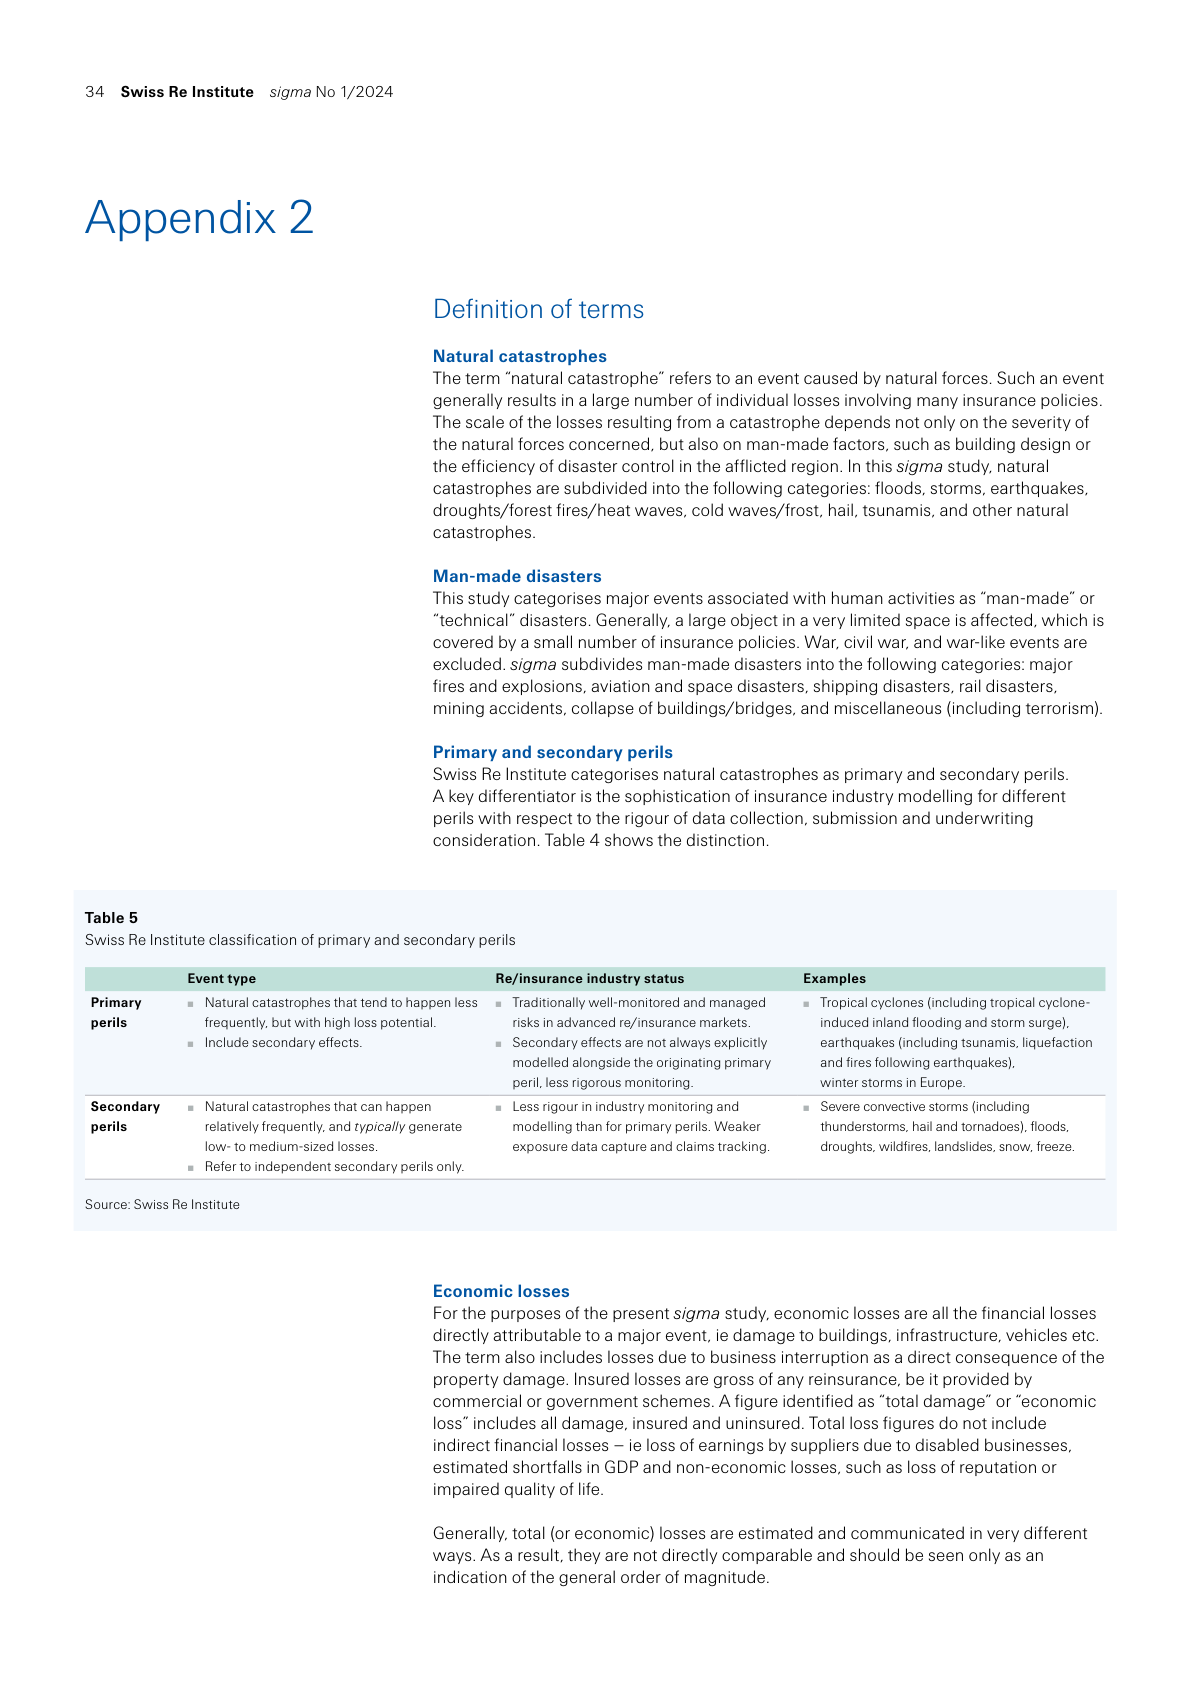


----------------------------------------------------------------------------------------------------
RANK 2 | PDF PAGE 36 | LIKELY VISUAL: True

TEXT PREVIEW:
Explore and visualise sigma data on natural catastrophes and the world insurance markets at 
www.sigma-explorer.com
The editorial deadline for this study was 22 February 2024.
sigma is available on Swiss Re’s website: www.swissre.com/sigma
The internet version may contain slightly updated information.
Graphic design and production:
Corporate Real Estate & Logistics / Media Production, Zurich
©2024
Swiss Re
All rights reserved.
The entire content of this sigma edition is subject to copyright with all rights reserved. The 
information may be used for private or internal purposes, provided that any copyright or other 
proprietary notices are not removed. Electronic reuse of the data published in sigma is prohibited. 
Reproduction in whole or in part or use for any public purpose is permitted only with the prior 
written approval of

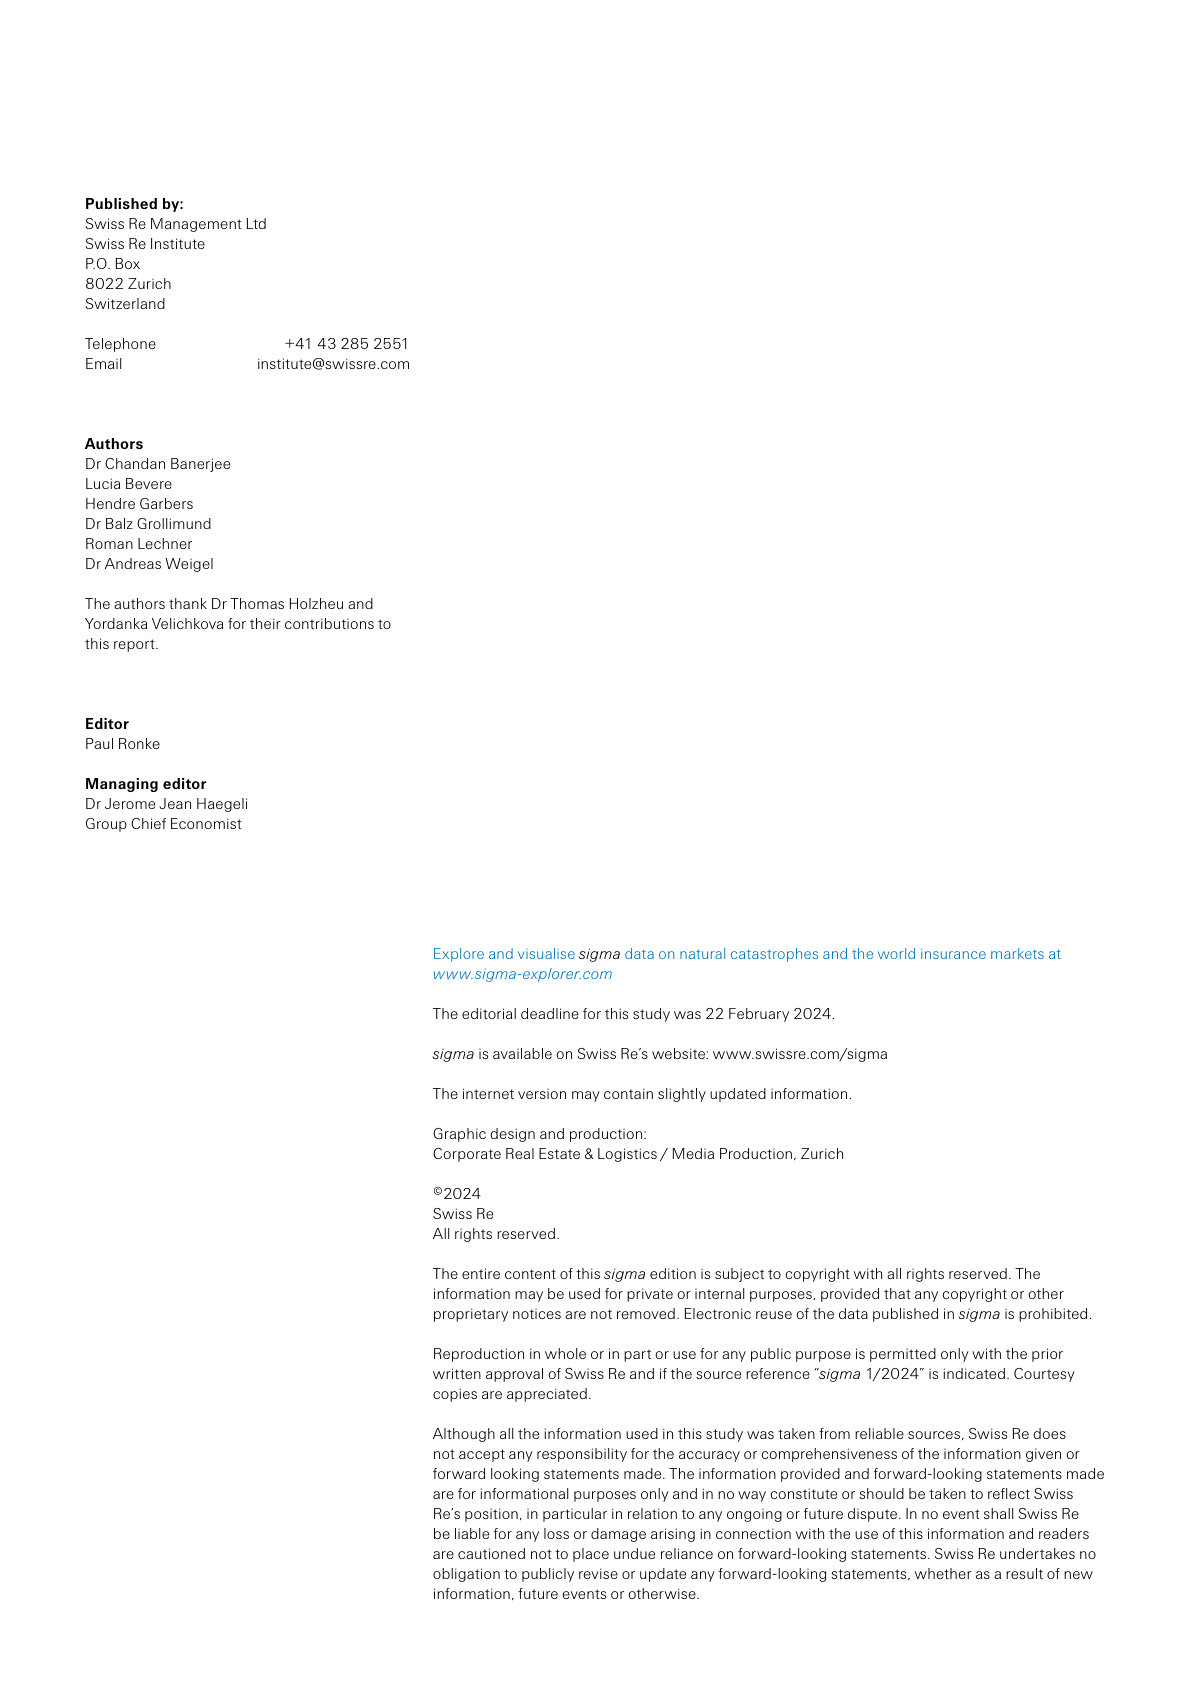


----------------------------------------------------------------------------------------------------
RANK 3 | PDF PAGE 29 | LIKELY VISUAL: True

TEXT PREVIEW:

sigma No 1/2024  Swiss Re Institute  29
Facts and figures
Number of catastrophic events: 332
In terms of sigma criteria, there were 332 catastrophes worldwide in 2023, up from 285 in 
2022. There were 218 natural catastrophes (up from 187 in 2022), and 114 man-made 
disasters (up from 98 in 2022). 
Number of victims: 76 569
Worldwide, 76 569 people are believed to have died or gone missing in disaster events 
in 2023. Natural catastrophes claimed 72 920 victims, the highest since 2010 and 
mostly from the earthquake disaster in Turkey and Syria (57 652). Man-made disasters 
claimed a further 3 649 victims. 
Appendix 1
Figure 19 
Number of catastrophic events, 1970–2023
Source: Swiss Re Institute
0
50
100
150
200
250
300
2023
2021
2018
2015
2012
2009
2006
2003
2000
1997
1994
1991
1988
1985
1982
1979
1976
1973
1970
Man-made disa

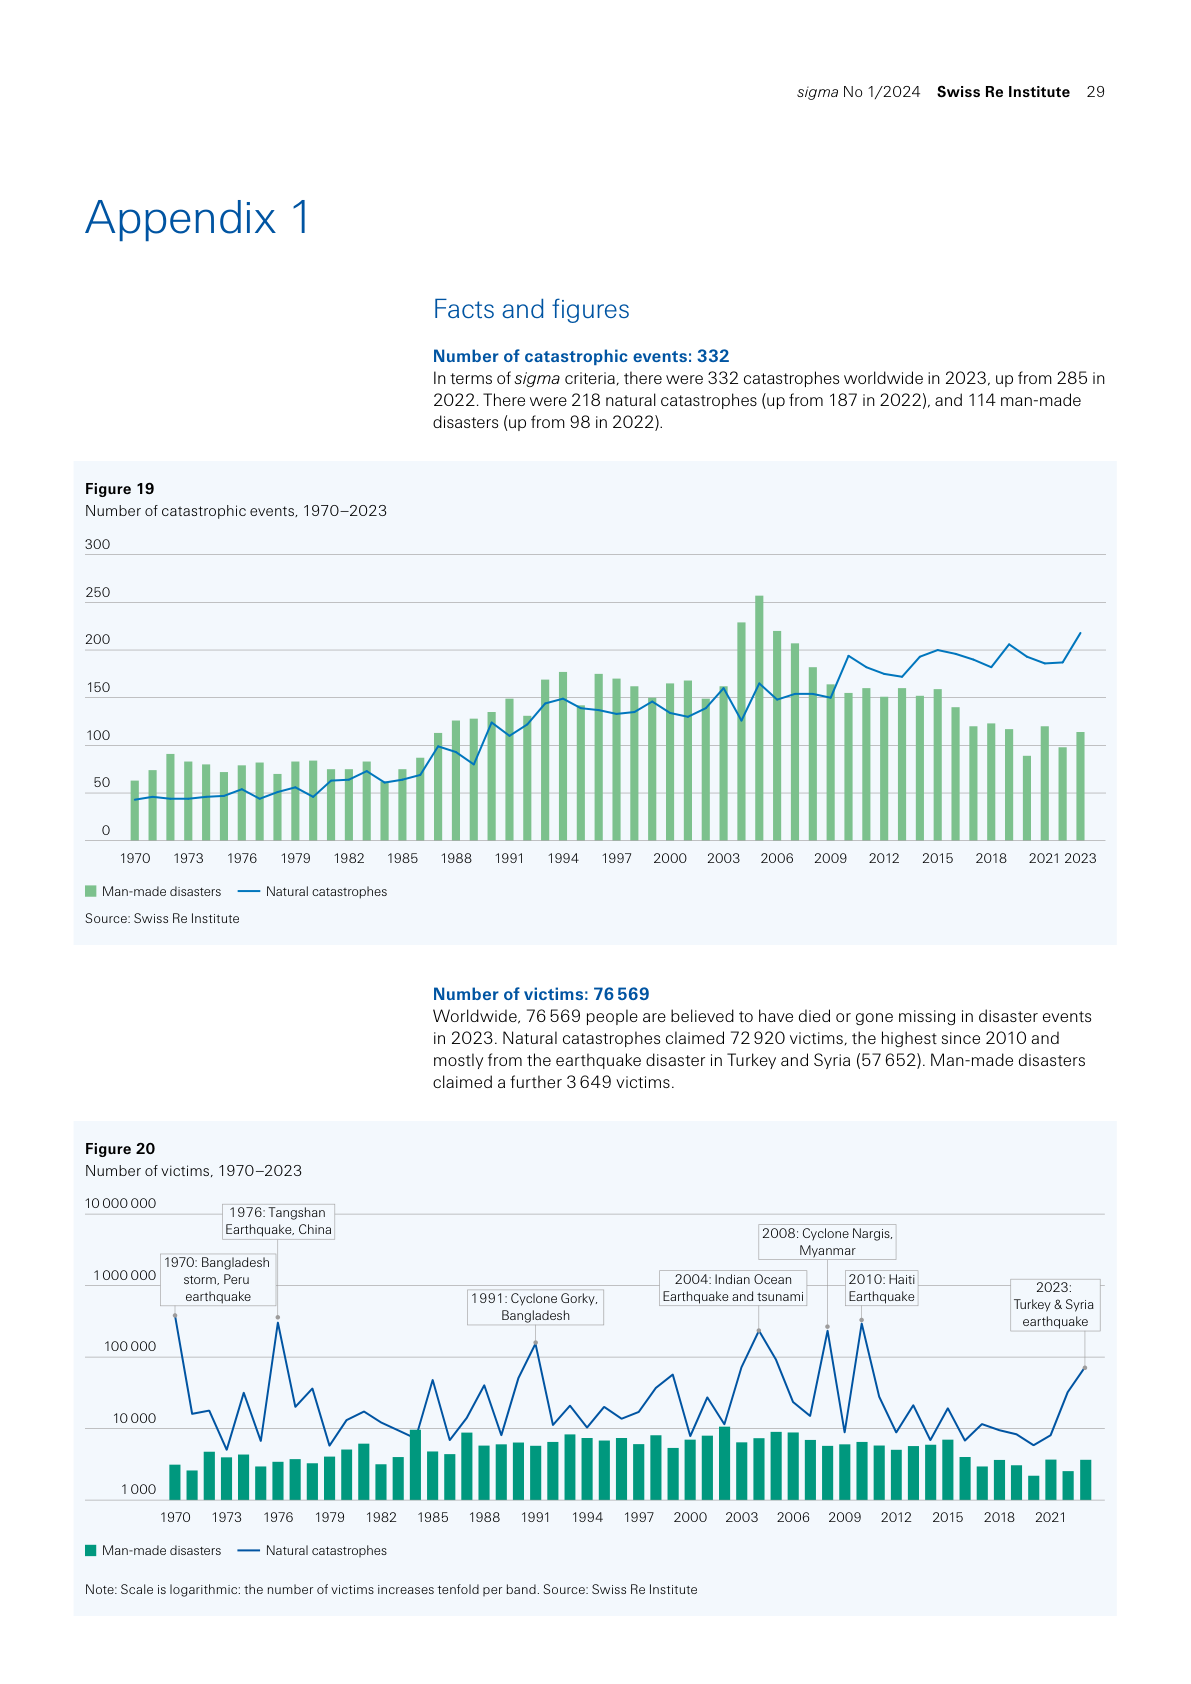


----------------------------------------------------------------------------------------------------
RANK 4 | PDF PAGE 30 | LIKELY VISUAL: True

TEXT PREVIEW:
30  Swiss Re Institute  sigma No 1/2024
Appendix 1
Global insured losses
The Turkey and Syria earthquake disaster, record high severe convective storms (SCS) 
and large-scale urban floods were the main events driving global insured losses from 
natural disasters of USD 108 billion in 2023. Though less than the USD 133 billion 
(inflation-adjusted) of 2022, last year’s insured losses were above the 5- and 10-year 
averages of USD 105 billion and USD 89 billion, respectively.
Primary and secondary perils
Record high losses from severe convective storms in the US brought the share of insured 
losses from so-called secondary perils (See Table 5 in Appendix 2) to roughly 81% in 
2023, almost double the share in 2022 (43%).
Figure 21 
Insured catastrophe losses, 1970–2023 (USD bn, 2023 prices)
Source: Swiss Re Institute
0
20
40
60
80


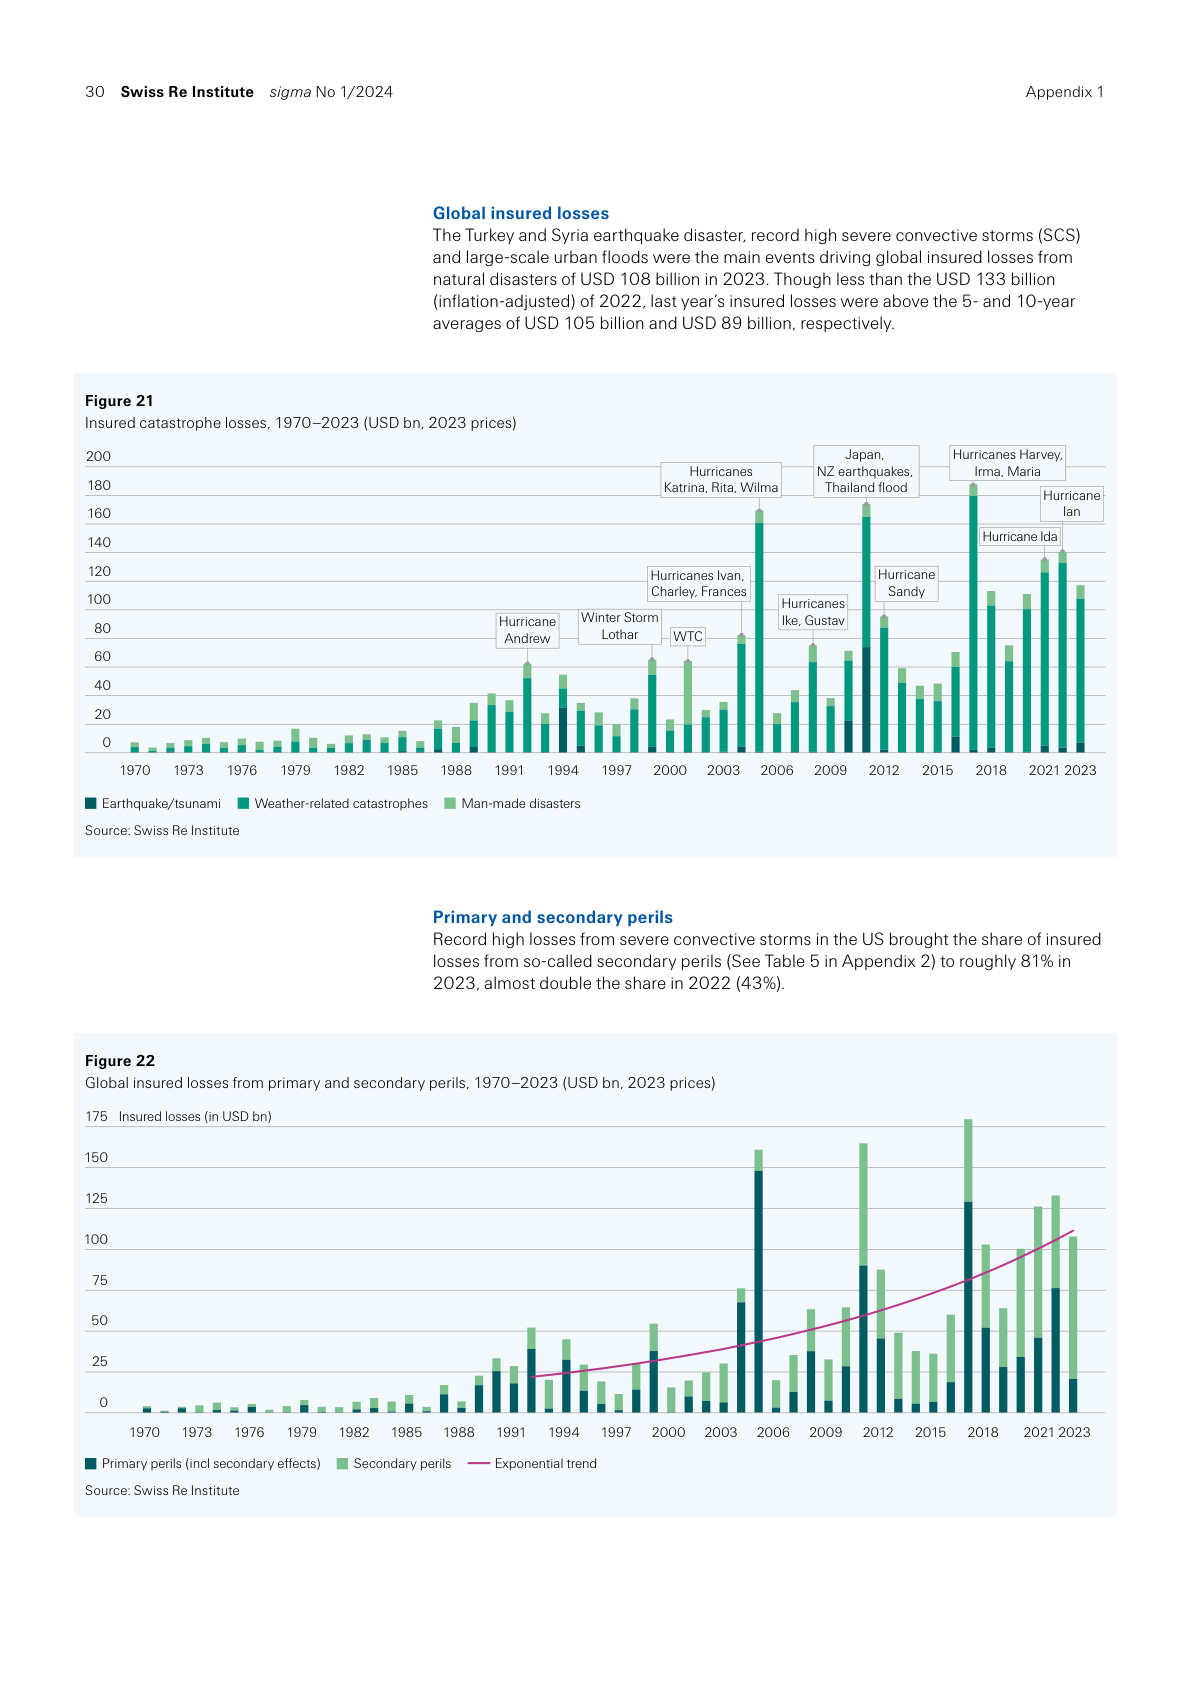

In [29]:
# ============================================================
# 33. INSPECT VISUAL CANDIDATE PAGES WITHOUT MODEL CALLS
# ============================================================

from IPython.display import display, Image


def get_page_row(
    doc_name: str,
    page_number: int
) -> pd.Series | None:
    """
    Retrieve one indexed page from pages_df.
    """

    matching_rows = pages_df[
        (
            pages_df["doc_name"]
            == doc_name
        )
        & (
            pages_df["page"]
            == page_number
        )
    ]

    if len(matching_rows) == 0:
        return None

    return matching_rows.iloc[0]


def inspect_visual_backlog_question(
    question_index: int,
    max_pages_to_show: int = 4,
    zoom: float = 2.0
):
    """
    Print and display the strongest candidate pages for one
    unresolved visual question.

    No LLM or vision-model requests are made.
    """

    matched_question = visual_backlog_df[
        visual_backlog_df["question_index"]
        == question_index
    ]

    if len(matched_question) == 0:
        raise ValueError(
            f"Question index {question_index} is not in the visual backlog."
        )

    backlog_row = matched_question.iloc[0]

    question = backlog_row["question"]

    candidate_page_numbers = [
        int(page_number.strip())
        for page_number
        in str(
            backlog_row["candidate_pages"]
        ).split(",")
        if page_number.strip()
    ][:max_pages_to_show]

    print("=" * 100)
    print("QUESTION INDEX:", question_index)
    print("=" * 100)

    print("\nQUESTION:")
    print(question)

    print("\nDOMINANT DOCUMENT:")
    print(
        backlog_row[
            "dominant_document"
        ]
    )

    print("\nCANDIDATE PAGES TO INSPECT:")
    print(candidate_page_numbers)

    for rank, page_number in enumerate(
        candidate_page_numbers,
        start=1
    ):
        page_row = get_page_row(
            doc_name=backlog_row[
                "dominant_document"
            ],
            page_number=page_number
        )

        if page_row is None:
            continue

        image_path = render_pdf_page(
            pdf_path=page_row["pdf_path"],
            page_number=page_number,
            zoom=zoom
        )

        print("\n" + "-" * 100)
        print(
            f"RANK {rank} | "
            f"PDF PAGE {page_number} | "
            f"LIKELY VISUAL: "
            f"{page_row['likely_visual_page']}"
        )

        print("\nTEXT PREVIEW:")
        print(
            str(
                page_row["content"]
            )[:1800]
        )

        print("\nPAGE IMAGE:")
        display(
            Image(
                filename=str(
                    image_path
                )
            )
        )


# ------------------------------------------------------------
# Start by inspecting the known chart page for Question 0
# ------------------------------------------------------------

inspect_visual_backlog_question(
    question_index=0,
    max_pages_to_show=4,
    zoom=2.0
)

In [30]:
# ============================================================
# 34. CAPTION-AWARE VISUAL PAGE RERANKER
# ============================================================

def tokenize_for_visual_ranking(text: str) -> set[str]:
    """
    Extract useful lowercase tokens for deterministic page ranking.
    """
    return set(
        re.findall(
            r"\b[a-zA-Z0-9$%.-]+\b",
            str(text).lower()
        )
    )


def score_visual_candidate_page(
    question: str,
    page_record: dict
) -> float:
    """
    Score a candidate visual page using transparent heuristics.

    Rewards:
    - keyword overlap with the question
    - chart / figure captions
    - visual-page flag
    - metric-specific vocabulary

    Penalises:
    - definitions and glossary pages
    - methodology-only pages
    """

    question_lower = str(
        question
    ).lower()

    page_text = str(
        page_record["content"]
    ).lower()

    question_tokens = tokenize_for_visual_ranking(
        question_lower
    )

    page_tokens = tokenize_for_visual_ranking(
        page_text
    )

    score = float(
        page_record.get(
            "candidate_score",
            0
        )
    )

    # --------------------------------------------------------
    # 1. Basic token overlap
    # --------------------------------------------------------

    score += (
        len(
            question_tokens.intersection(
                page_tokens
            )
        )
        * 1.5
    )

    # --------------------------------------------------------
    # 2. Reward pages that genuinely look like visual evidence
    # --------------------------------------------------------

    visual_rewards = {
        "figure": 5,
        "chart": 4,
        "source:": 1,
        "1970–2023": 5,
        "1994–2023": 5,
        "number of victims": 8,
        "number of catastrophic events": 8,
        "number of natural catastrophes": 8,
        "insured losses": 4,
        "high severity": 6,
        "severe convective storms": 5
    }

    for phrase, reward in visual_rewards.items():
        if phrase in page_text:
            score += reward

    # --------------------------------------------------------
    # 3. Reward metric-specific alignment
    # --------------------------------------------------------

    metric_rules = {
        "casualties": [
            "number of victims",
            "victims",
            "man-made disasters"
        ],
        "victims": [
            "number of victims",
            "victims"
        ],
        "man-made disasters": [
            "man-made disasters"
        ],
        "natural catastrophes": [
            "natural catastrophes"
        ],
        "high severity": [
            "high severity",
            "usd 5 billion and above"
        ],
        "insured losses": [
            "insured losses",
            "total annual insured losses"
        ],
        "severe convective storm": [
            "severe convective storms",
            "scs"
        ]
    }

    for question_phrase, page_phrases in metric_rules.items():

        if question_phrase in question_lower:

            for page_phrase in page_phrases:

                if page_phrase in page_text:
                    score += 7

    # --------------------------------------------------------
    # 4. Penalise glossary and definition pages
    # --------------------------------------------------------

    penalty_phrases = {
        "definition of terms": 20,
        "methodology": 8,
        "thresholds": 4,
        "data sources": 4
    }

    for phrase, penalty in penalty_phrases.items():
        if phrase in page_text:
            score -= penalty

    return score


def rerank_visual_candidates_deterministically(
    question: str,
    max_candidate_pages: int = 10,
    max_selected_pages: int = 5
) -> list[dict]:
    """
    Retrieve visual candidates and rerank them without an LLM call.

    This avoids:
    - malformed JSON
    - slow visual calls
    - glossary pages outranking chart pages
    """

    initial_candidates = select_visual_pages(
        question=question,
        top_k_search_pages=max_candidate_pages,
        neighbour_window=1,
        max_visual_pages=max_candidate_pages
    )

    reranked_candidates = []

    for page in initial_candidates:

        page_copy = page.copy()

        page_copy[
            "caption_aware_score"
        ] = score_visual_candidate_page(
            question=question,
            page_record=page_copy
        )

        reranked_candidates.append(
            page_copy
        )

    reranked_candidates = sorted(
        reranked_candidates,
        key=lambda item: item[
            "caption_aware_score"
        ],
        reverse=True
    )

    return reranked_candidates[
        :max_selected_pages
    ]


print(
    "Caption-aware visual-page reranker created successfully."
)

Caption-aware visual-page reranker created successfully.


In [31]:
# ============================================================
# 35. BUILD A CLEAN VISUAL-PAGE MAP
# ============================================================

resolved_visual_records = []

for _, row in tqdm(
    visual_questions_df.iterrows(),
    total=len(visual_questions_df),
    desc="Resolving visual pages"
):
    question_index = int(
        row["question_index"]
    )

    question = row[
        "question"
    ]

    reranked_pages = (
        rerank_visual_candidates_deterministically(
            question=question,
            max_candidate_pages=12,
            max_selected_pages=5
        )
    )

    page_numbers = [
        int(
            page["page"]
        )
        for page in reranked_pages
    ]

    resolved_visual_records.append({
        "question_index": question_index,
        "question": question,
        "resolved_candidate_pages": ", ".join(
            str(page_number)
            for page_number in page_numbers
        ),
        "top_page": (
            page_numbers[0]
            if page_numbers
            else None
        ),
        "top_page_score": (
            round(
                reranked_pages[0][
                    "caption_aware_score"
                ],
                4
            )
            if reranked_pages
            else None
        )
    })


resolved_visual_pages_df = pd.DataFrame(
    resolved_visual_records
)

RESOLVED_VISUAL_PAGES_PATH = (
    OUTPUT_DIR
    / "resolved_visual_pages.csv"
)

resolved_visual_pages_df.to_csv(
    RESOLVED_VISUAL_PAGES_PATH,
    index=False
)


print("=" * 100)
print("RESOLVED VISUAL PAGE MAP")
print("=" * 100)

display(
    resolved_visual_pages_df
)

print("\nSaved to:")
print(
    RESOLVED_VISUAL_PAGES_PATH
)

Resolving visual pages: 100%|██████████| 6/6 [00:00<00:00, 61.68it/s]

RESOLVED VISUAL PAGE MAP


,question_index,question,resolved_candidate_pages,top_page,top_page_score
0,0,What year where there most casualties from man-made disasters in the recorded data?,"29, 30, 3, 6, 35",29,91.9903
1,1,In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?,"29, 30, 31, 6, 7",29,88.3493
2,2,Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?,"29, 31, 6, 30, 7",29,86.0526
3,3,What year between 1994 and 2023 had the most high severity ($5 billion in damages or more) natural catastrophes?,"10, 9, 8, 6, 11",10,111.9538
4,5,"Which figure shows the trend in insured losses over data from 1994 to 2023? In this figure, what is the highest insured loss year on record?","9, 10, 12, 15, 8",9,118.1118
5,6,"Before 2023, what was the highest year on record for European Severe Convective Storm losses?","15, 13, 16, 12, 6",15,85.8096



Saved to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/resolved_visual_pages.csv


In [32]:
# ============================================================
# 36. DIAGNOSE THE INTERNAL STRUCTURE OF VISUAL PDF PAGES
# ============================================================

from collections import Counter
import fitz
import pandas as pd


def normalize_pdf_color(color):
    """
    Convert a PDF colour value into a compact comparable tuple.
    """

    if color is None:
        return None

    return tuple(
        round(
            float(channel),
            4
        )
        for channel in color
    )


def inspect_pdf_page_structure(
    pdf_path: str,
    page_number: int
) -> dict:
    """
    Inspect how a PDF page is internally represented.

    Extracts:
    - number of embedded images
    - vector drawing count
    - vector item types
    - rectangle, line and curve counts
    - text block count
    - word count
    - most common rectangle fill colours

    This tells us whether charts can be read as:
    - structured vector shapes
    - extracted text
    - or raster images
    """

    pdf_path = Path(
        pdf_path
    )

    with fitz.open(
        pdf_path
    ) as document:

        page = document[
            page_number - 1
        ]

        drawings = page.get_drawings()

        embedded_images = page.get_images(
            full=True
        )

        text_blocks = page.get_text(
            "blocks"
        )

        words = page.get_text(
            "words"
        )

        item_type_counter = Counter()

        rectangle_records = []

        for drawing_index, drawing in enumerate(
            drawings
        ):
            fill_color = normalize_pdf_color(
                drawing.get(
                    "fill"
                )
            )

            stroke_color = normalize_pdf_color(
                drawing.get(
                    "color"
                )
            )

            for item in drawing.get(
                "items",
                []
            ):
                item_type = item[0]

                item_type_counter[
                    item_type
                ] += 1

                if item_type == "re":
                    rectangle = fitz.Rect(
                        item[1]
                    )

                    rectangle_records.append({
                        "drawing_index": drawing_index,
                        "x0": float(
                            rectangle.x0
                        ),
                        "y0": float(
                            rectangle.y0
                        ),
                        "x1": float(
                            rectangle.x1
                        ),
                        "y1": float(
                            rectangle.y1
                        ),
                        "width": float(
                            rectangle.width
                        ),
                        "height": float(
                            rectangle.height
                        ),
                        "area": float(
                            rectangle.width
                            * rectangle.height
                        ),
                        "fill_color": fill_color,
                        "stroke_color": stroke_color
                    })

        rectangles_df = pd.DataFrame(
            rectangle_records
        )

        if not rectangles_df.empty:
            fill_colour_summary = (
                rectangles_df
                .dropna(
                    subset=[
                        "fill_color"
                    ]
                )
                .groupby(
                    "fill_color"
                )
                .size()
                .sort_values(
                    ascending=False
                )
                .head(
                    10
                )
                .to_dict()
            )

        else:
            fill_colour_summary = {}

        return {
            "doc_name": pdf_path.name,
            "pdf_path": str(
                pdf_path
            ),
            "page": page_number,
            "page_width": round(
                float(
                    page.rect.width
                ),
                2
            ),
            "page_height": round(
                float(
                    page.rect.height
                ),
                2
            ),
            "embedded_image_count": len(
                embedded_images
            ),
            "vector_drawing_count": len(
                drawings
            ),
            "rectangle_count": int(
                item_type_counter.get(
                    "re",
                    0
                )
            ),
            "line_count": int(
                item_type_counter.get(
                    "l",
                    0
                )
            ),
            "curve_count": int(
                item_type_counter.get(
                    "c",
                    0
                )
            ),
            "text_block_count": len(
                text_blocks
            ),
            "word_count": len(
                words
            ),
            "top_rectangle_fill_colours": str(
                fill_colour_summary
            )
        }


# ------------------------------------------------------------
# UNIQUE CHART PAGES FOUND BY THE VISUAL RESOLVER
# ------------------------------------------------------------

visual_chart_pages = [
    {
        "doc_name": "swissre_sigma-1_2024_english.pdf",
        "page": 29
    },
    {
        "doc_name": "swissre_sigma-1_2024_english.pdf",
        "page": 10
    },
    {
        "doc_name": "swissre_sigma-1_2024_english.pdf",
        "page": 9
    },
    {
        "doc_name": "swissre_sigma-1_2024_english.pdf",
        "page": 15
    }
]


visual_structure_records = []

for chart_page in tqdm(
    visual_chart_pages,
    desc="Inspecting chart-page structure"
):
    pdf_path = (
        DATA_DIR
        / chart_page[
            "doc_name"
        ]
    )

    visual_structure_records.append(
        inspect_pdf_page_structure(
            pdf_path=str(
                pdf_path
            ),
            page_number=chart_page[
                "page"
            ]
        )
    )


visual_structure_df = pd.DataFrame(
    visual_structure_records
)


print("=" * 100)
print("VISUAL PAGE STRUCTURE DIAGNOSTIC")
print("=" * 100)

display(
    visual_structure_df[
        [
            "doc_name",
            "page",
            "embedded_image_count",
            "vector_drawing_count",
            "rectangle_count",
            "line_count",
            "curve_count",
            "text_block_count",
            "word_count",
            "top_rectangle_fill_colours"
        ]
    ]
)

Inspecting chart-page structure: 100%|██████████| 4/4 [00:00<00:00, 21.92it/s]

VISUAL PAGE STRUCTURE DIAGNOSTIC


,doc_name,page,embedded_image_count,vector_drawing_count,rectangle_count,line_count,curve_count,text_block_count,word_count,top_rectangle_fill_colours
0,swissre_sigma-1_2024_english.pdf,29,0,204,122,127,28,31,228,"{(0.0, 0.598, 0.495): 55, (0.488, 0.757, 0.553): 55, (0.955, 0.974, 0.994): 9}"
1,swissre_sigma-1_2024_english.pdf,10,0,137,128,9,0,89,434,"{(0.955, 0.974, 0.994): 33, (0.0, 0.364, 0.382): 31, (0.488, 0.757, 0.553): 31, (0.468, 0.729, 0.907): 23, (0.0, 0.463, 0.743): 5, (0.0, 0.598, 0.495): 5}"
2,swissre_sigma-1_2024_english.pdf,9,0,171,32,109,124,66,400,"{(0.488, 0.757, 0.553): 31, (0.955, 0.974, 0.994): 1}"
3,swissre_sigma-1_2024_english.pdf,15,0,182,40,33089,0,26,544,"{(0.0, 0.598, 0.495): 13, (0.0, 0.332, 0.639): 7, (0.0, 0.463, 0.743): 7, (0.468, 0.729, 0.907): 7, (0.0, 0.364, 0.382): 1, (0.314, 0.58, 0.603): 1, (0.409, 0.753, 0.696): 1, (0.488, 0.757, 0.553): 1, (0.722, 0.858, 0.738): 1, (0.955, 0.974, 0.994): 1}"



swissre_sigma-1_2024_english.pdf | PDF PAGE 29

EXTRACTED TEXT:

sigma No 1/2024  Swiss Re Institute  29
Facts and figures
Number of catastrophic events: 332
In terms of sigma criteria, there were 332 catastrophes worldwide in 2023, up from 285 in 
2022. There were 218 natural catastrophes (up from 187 in 2022), and 114 man-made 
disasters (up from 98 in 2022). 
Number of victims: 76 569
Worldwide, 76 569 people are believed to have died or gone missing in disaster events 
in 2023. Natural catastrophes claimed 72 920 victims, the highest since 2010 and 
mostly from the earthquake disaster in Turkey and Syria (57 652). Man-made disasters 
claimed a further 3 649 victims. 
Appendix 1
Figure 19 
Number of catastrophic events, 1970–2023
Source: Swiss Re Institute
0
50
100
150
200
250
300
2023
2021
2018
2015
2012
2009
2006
2003
2000
1997
1994
1991
1988
1985
1982
1979
1976
1973
1970
Man-made disasters
Natural catastrophes
Figure 20 
Number of victims, 1970–2023
Note: Scale is logarithmic: 

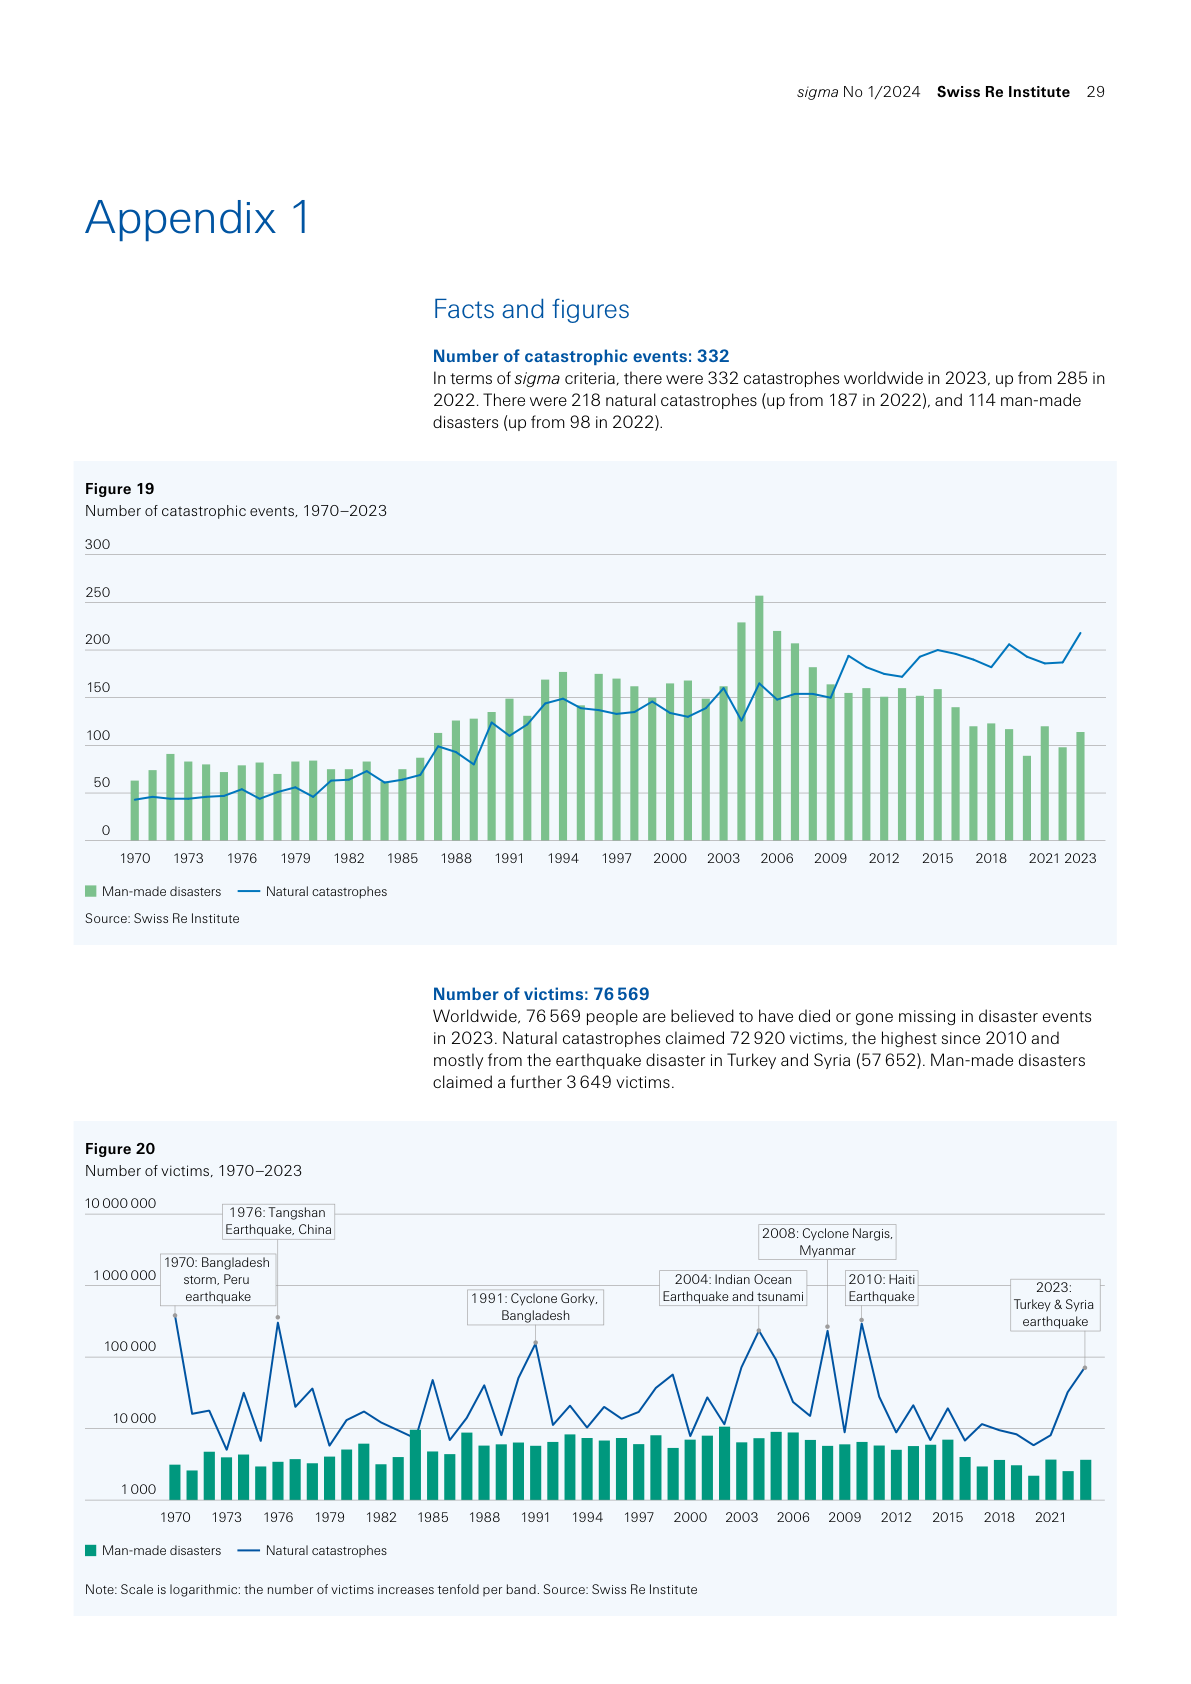


swissre_sigma-1_2024_english.pdf | PDF PAGE 10

EXTRACTED TEXT:
10  Swiss Re Institute  sigma No 1/2024
Year in review: reaffirming outlook trends 
With the number of medium-sized events growing fast, so too have their associated 
insured losses, up 7.1% annually since 1994 (inflation-adjusted, see Figure 6). This is 
above the 5.9% average annual growth rate of insured losses inflicted by all natural perils 
over same period.4 Of the medium-sized category, insured losses from SCS have grown 
most, by 9.7% annually. Insured losses from the low- and the high-severity categories 
have grown more slowly. However, for the former the level of confidence around trend 
may be lower due to insufficient monitoring and reporting. And for the latter, the rarity of 
high-severity event occurrence instead and wide dispersion in loss outcomes (eg, in 
recent years ranging from USD 6 billion (last year’s earthquake in Turkey) to USD 60 
billion (Hurricane Ian in 2022)), makes it harder to discern a 

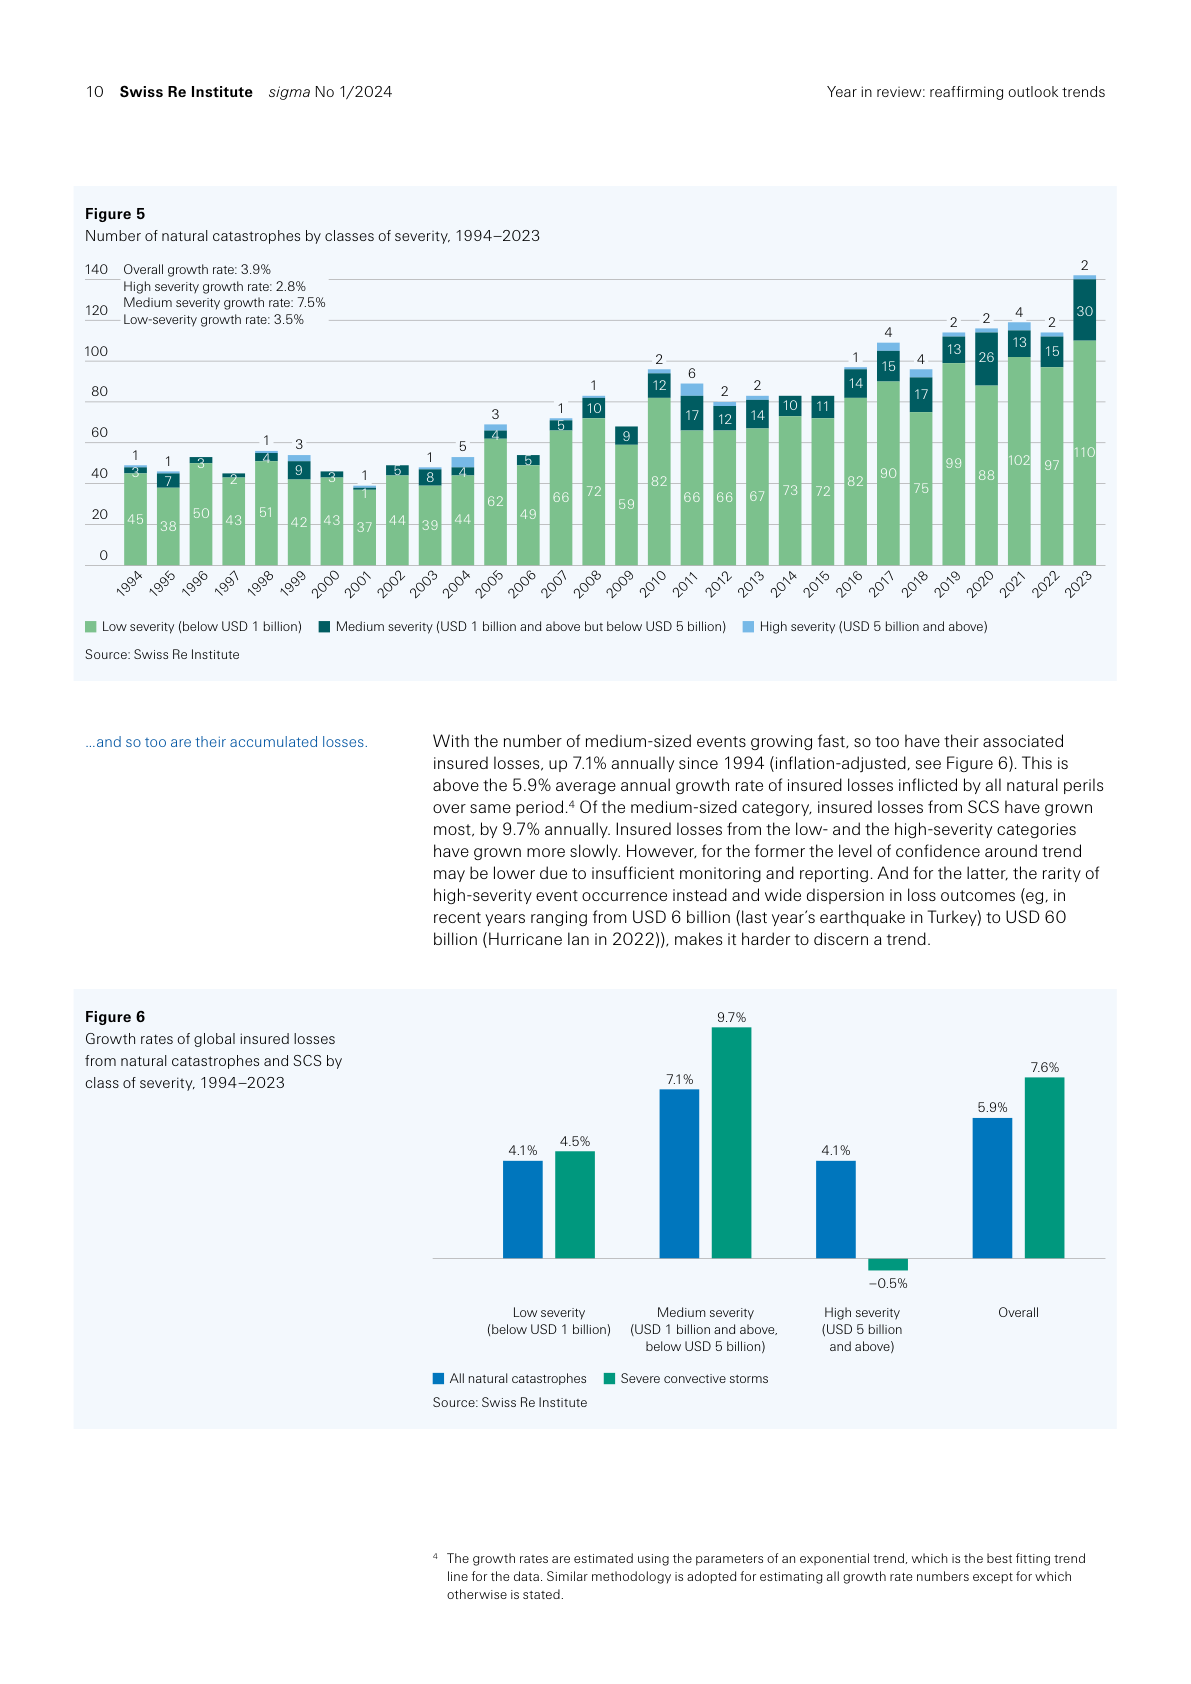


swissre_sigma-1_2024_english.pdf | PDF PAGE 9

EXTRACTED TEXT:
Year in review: reaffirming outlook trends
sigma No 1/2024  Swiss Re Institute  9
Medium-severity events, in particular SCS, contribute most to losses
Absent an outlier peak-loss event, the global insured losses from all natural disasters last 
year nevertheless exceeded USD 100 billion. When the industry last experienced a 
dearth of peak loss events (2013 to 2016), annual insured losses (inflation adjusted) 
were well below this mark. The occurrence of many medium-sized disasters, which we 
define as events resulting in insured losses of between USD 1–5 billion, contributed 
most to the loss accumulation over the year. There were at least 30 such events in 2023, 
many more than the previous 10-year average (17). Of those, 21 were SCS, a new high 
and more than double the average of each of the previous 10 years (ie, 8). 
On average, since 1994 the number of medium-sized events each year has grown by 
7.5%, almost double 

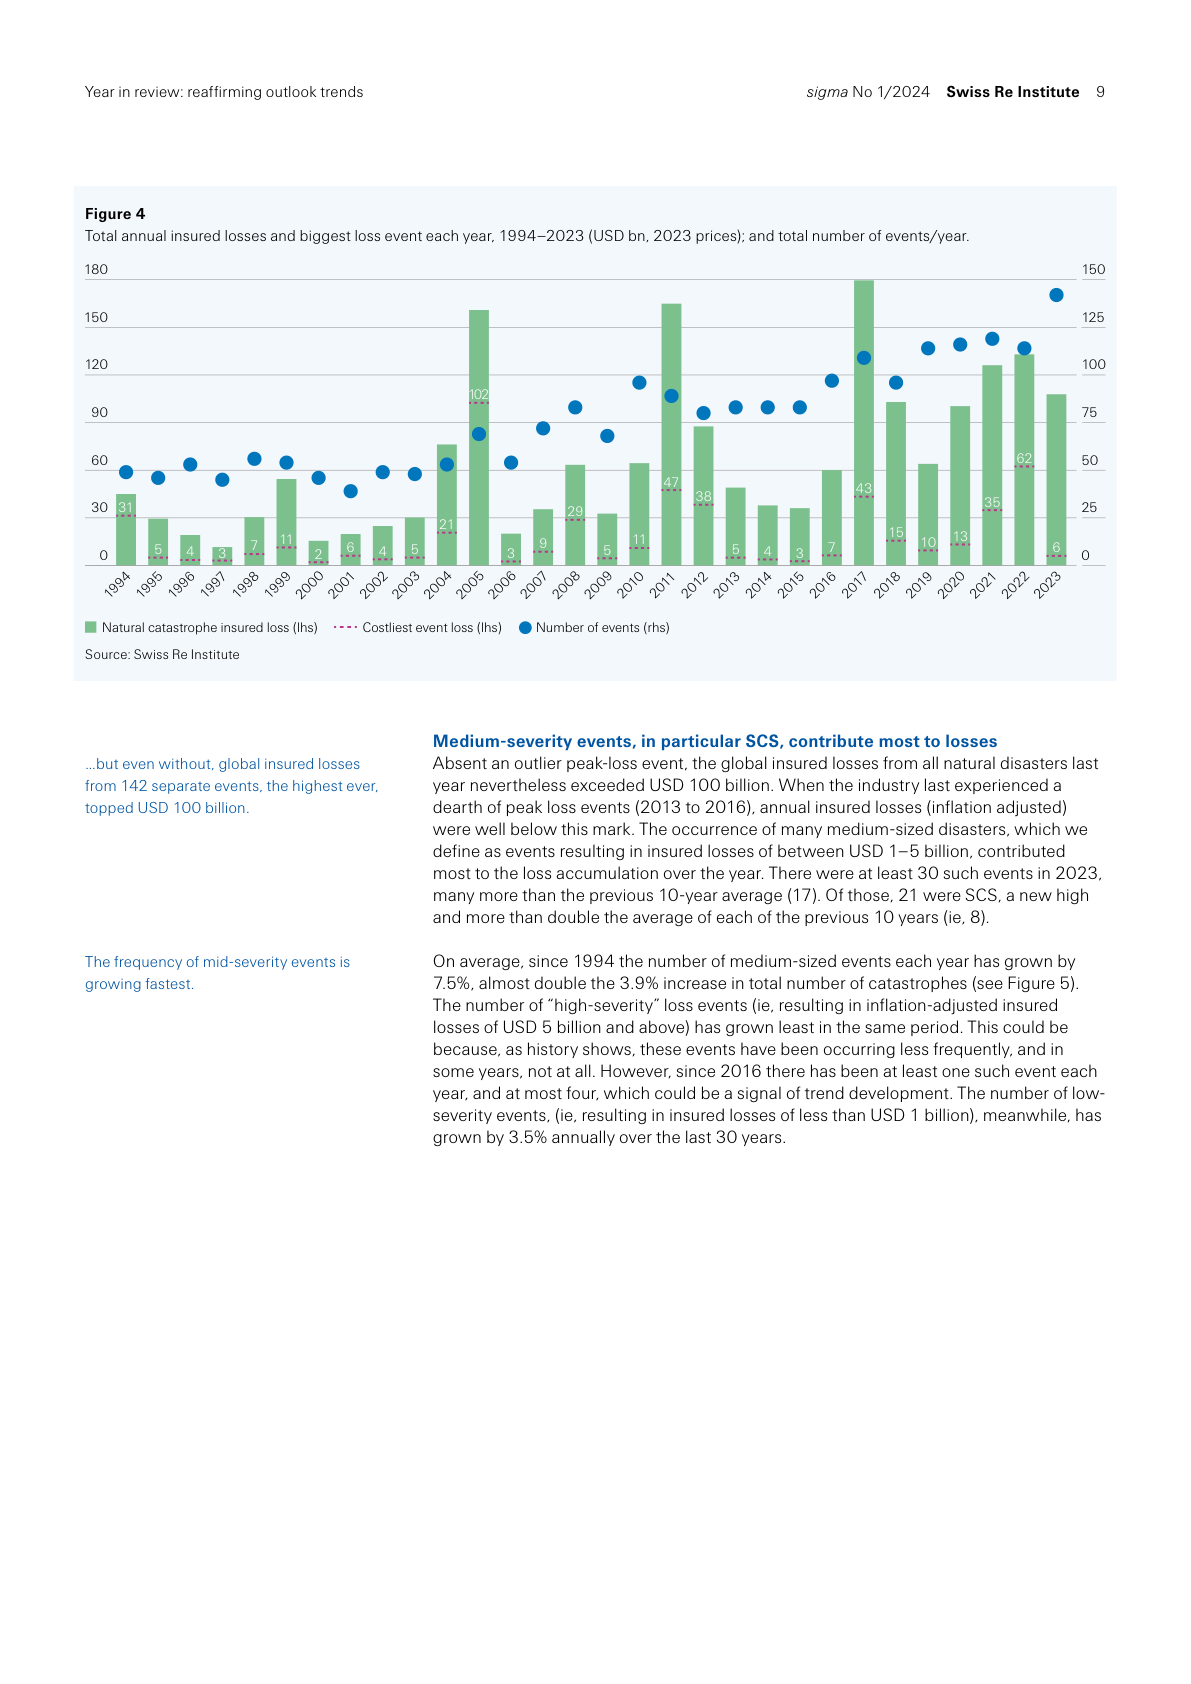


swissre_sigma-1_2024_english.pdf | PDF PAGE 15

EXTRACTED TEXT:
Spotlight on severe convective storm
sigma No 1/2024  Swiss Re Institute  15
In the US, all SCS-prone regions suffered similar insured losses last year: about 30% 
originated in the midwest, 30% in the central US, and 20% in the southeast 
(see Figure 12). The geographic loss distribution in 2023 was similar to that of 
the preceding two decades.
In Europe, insured losses from SCS have topped USD 5 billion in each of the last three 
years. The events that occurred offer compelling evidence that hail risk in particular is 
increasing. In 2021, Germany was worst impacted and in 2022, it was France. Then in 
July last year, Italy experienced the destructive power of hail, when a series of SCS hit 
the densely populated north of the country. The hail storms caused insured losses of 
USD 5.5 billion in Italy, the highest ever for a SCS event in Europe on sigma records. New 
records were set from a hazard severity perspective a

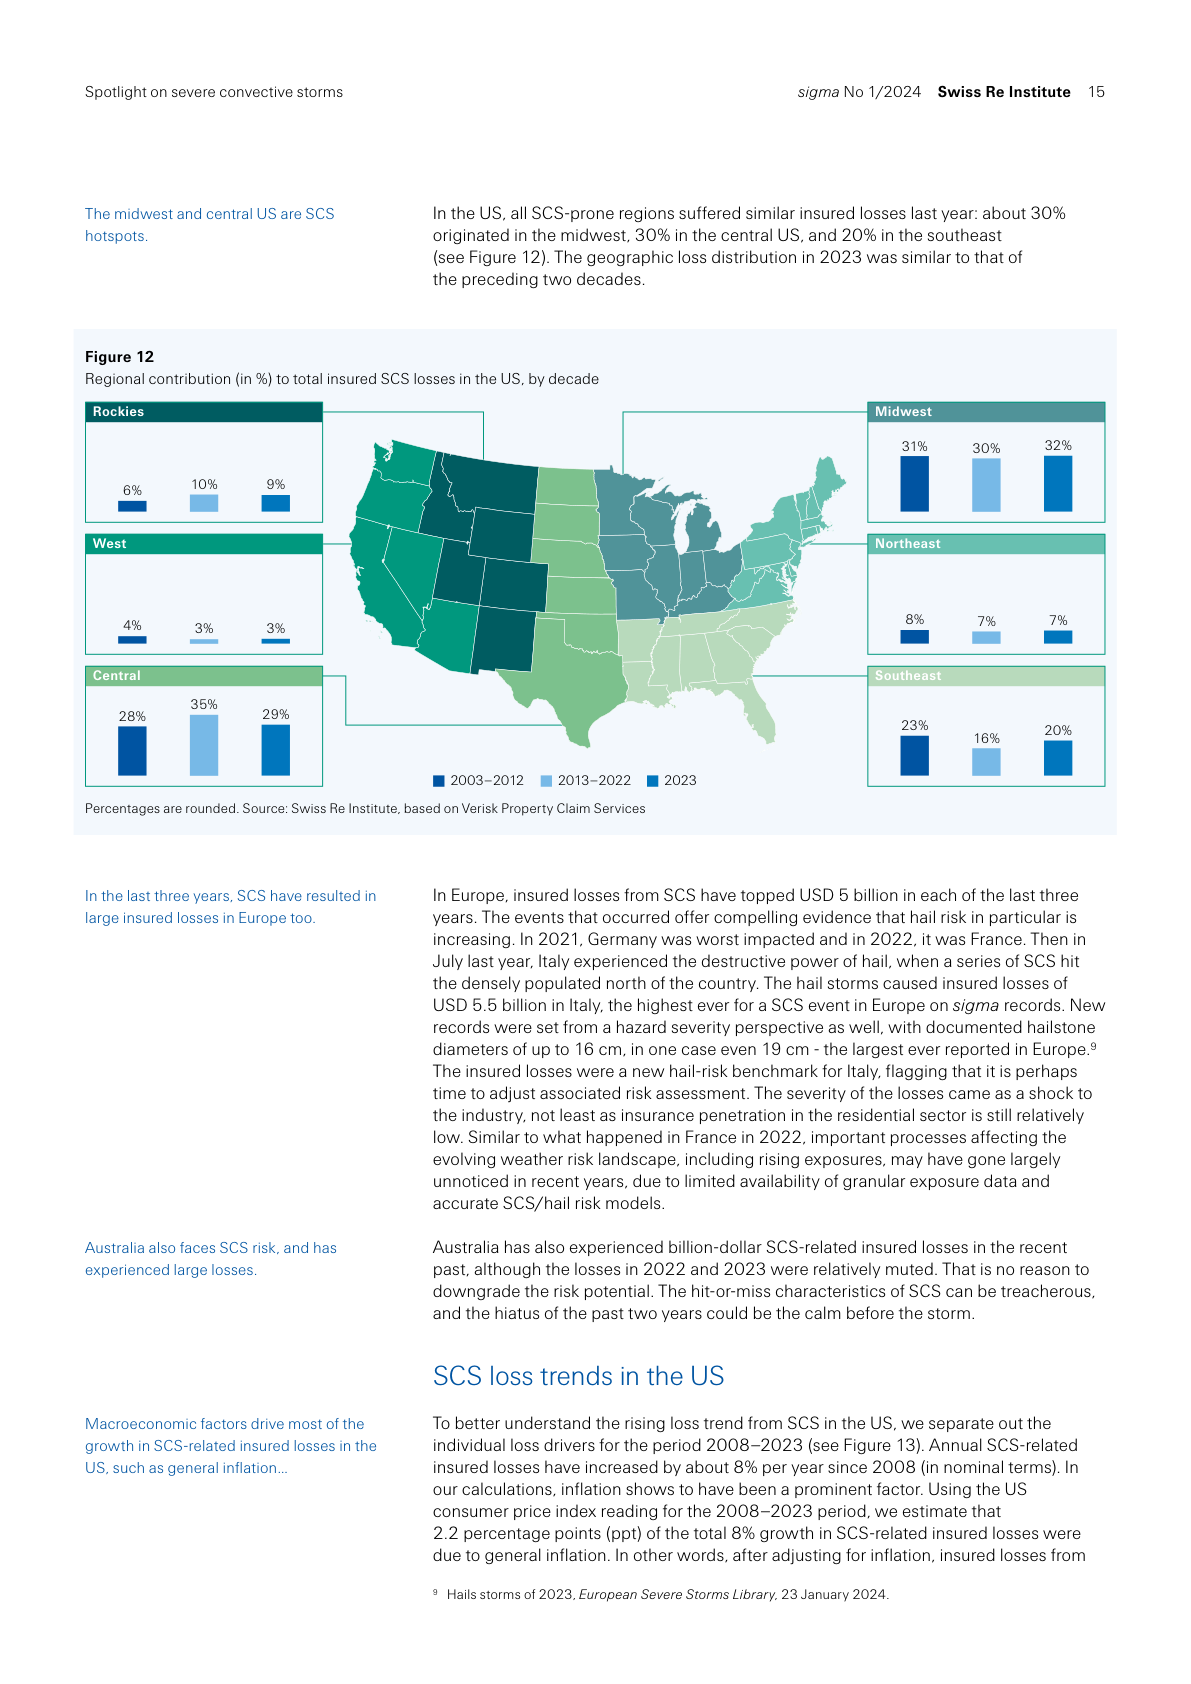

In [33]:
# ============================================================
# 37. INSPECT CHART PAGES AND EXTRACTED TEXT SIDE BY SIDE
# ============================================================

from IPython.display import display, Image


def display_visual_page_diagnostic(
    doc_name: str,
    page_number: int,
    zoom: float = 2.0,
    text_preview_chars: int = 5000
):
    """
    Display one visual PDF page and its extracted text.

    This helps us determine:
    - whether chart values are already present in text extraction
    - whether a vector parser is necessary
    - whether a raster-image fallback is required
    """

    matched_rows = pages_df[
        (
            pages_df[
                "doc_name"
            ]
            == doc_name
        )
        & (
            pages_df[
                "page"
            ]
            == page_number
        )
    ]

    if len(
        matched_rows
    ) == 0:
        raise ValueError(
            f"Page not found: {doc_name}, page {page_number}"
        )

    page_row = matched_rows.iloc[
        0
    ]

    image_path = render_pdf_page(
        pdf_path=page_row[
            "pdf_path"
        ],
        page_number=page_number,
        zoom=zoom
    )

    print("\n" + "=" * 110)
    print(
        doc_name,
        "| PDF PAGE",
        page_number
    )
    print("=" * 110)

    print("\nEXTRACTED TEXT:")
    print(
        str(
            page_row[
                "content"
            ]
        )[
            :text_preview_chars
        ]
    )

    print("\nRENDERED PAGE IMAGE:")
    display(
        Image(
            filename=str(
                image_path
            )
        )
    )


for chart_page in visual_chart_pages:
    display_visual_page_diagnostic(
        doc_name=chart_page[
            "doc_name"
        ],
        page_number=chart_page[
            "page"
        ],
        zoom=2.0,
        text_preview_chars=5000
    )

In [34]:
# ============================================================
# 38. IDENTIFY REPEATED RECTANGLE SERIES IN VECTOR CHARTS
# ============================================================

import fitz
import pandas as pd
from pathlib import Path


def extract_filled_rectangles(
    pdf_path: str,
    page_number: int
) -> pd.DataFrame:
    """
    Extract filled PDF rectangles from one page.

    Repeated filled rectangles often correspond to:
    - bar-chart series
    - legend markers
    - background panels

    We retain geometry and colour so that chart series can later
    be separated programmatically.
    """

    rectangle_records = []

    with fitz.open(
        pdf_path
    ) as document:

        page = document[
            page_number - 1
        ]

        for drawing_index, drawing in enumerate(
            page.get_drawings()
        ):
            fill_color = normalize_pdf_color(
                drawing.get(
                    "fill"
                )
            )

            stroke_color = normalize_pdf_color(
                drawing.get(
                    "color"
                )
            )

            if fill_color is None:
                continue

            for item_index, item in enumerate(
                drawing.get(
                    "items",
                    []
                )
            ):
                if item[0] != "re":
                    continue

                rectangle = fitz.Rect(
                    item[1]
                )

                # Remove tiny rendering artefacts
                if (
                    rectangle.width <= 0.2
                    or rectangle.height <= 0.2
                ):
                    continue

                rectangle_records.append({
                    "page": page_number,
                    "drawing_index": drawing_index,
                    "item_index": item_index,
                    "x0": float(
                        rectangle.x0
                    ),
                    "y0": float(
                        rectangle.y0
                    ),
                    "x1": float(
                        rectangle.x1
                    ),
                    "y1": float(
                        rectangle.y1
                    ),
                    "x_center": float(
                        (
                            rectangle.x0
                            + rectangle.x1
                        )
                        / 2
                    ),
                    "y_center": float(
                        (
                            rectangle.y0
                            + rectangle.y1
                        )
                        / 2
                    ),
                    "width": float(
                        rectangle.width
                    ),
                    "height": float(
                        rectangle.height
                    ),
                    "area": float(
                        rectangle.width
                        * rectangle.height
                    ),
                    "fill_color": fill_color,
                    "stroke_color": stroke_color
                })

    return pd.DataFrame(
        rectangle_records
    )


def summarise_repeated_rectangle_series(
    rectangles_df: pd.DataFrame,
    minimum_rectangle_count: int = 6
) -> pd.DataFrame:
    """
    Summarise repeated rectangle colours.

    A colour appearing repeatedly at different x positions is a strong
    candidate for a bar-chart series.
    """

    if rectangles_df.empty:
        return pd.DataFrame()

    summary_df = (
        rectangles_df
        .groupby(
            "fill_color",
            as_index=False
        )
        .agg(
            rectangle_count=(
                "fill_color",
                "size"
            ),
            distinct_x_positions=(
                "x_center",
                lambda values: int(
                    values.round(
                        2
                    ).nunique()
                )
            ),
            median_width=(
                "width",
                "median"
            ),
            minimum_width=(
                "width",
                "min"
            ),
            maximum_width=(
                "width",
                "max"
            ),
            median_height=(
                "height",
                "median"
            ),
            minimum_height=(
                "height",
                "min"
            ),
            maximum_height=(
                "height",
                "max"
            ),
            minimum_x=(
                "x0",
                "min"
            ),
            maximum_x=(
                "x1",
                "max"
            ),
            minimum_y=(
                "y0",
                "min"
            ),
            maximum_y=(
                "y1",
                "max"
            )
        )
    )

    summary_df = (
        summary_df[
            summary_df[
                "rectangle_count"
            ]
            >= minimum_rectangle_count
        ]
        .sort_values(
            [
                "rectangle_count",
                "distinct_x_positions"
            ],
            ascending=[
                False,
                False
            ]
        )
        .reset_index(
            drop=True
        )
    )

    summary_df.insert(
        0,
        "series_id",
        [
            f"S{index + 1}"
            for index in range(
                len(
                    summary_df
                )
            )
        ]
    )

    return summary_df


# ------------------------------------------------------------
# ANALYSE THE VECTOR-CHART PAGES
# ------------------------------------------------------------

chart_rectangle_records = []
chart_series_summary_records = []

for chart_page in [
    29,
    10,
    9,
    15
]:
    pdf_path = (
        DATA_DIR
        / "swissre_sigma-1_2024_english.pdf"
    )

    rectangles_df = extract_filled_rectangles(
        pdf_path=str(
            pdf_path
        ),
        page_number=chart_page
    )

    rectangles_df[
        "source_page"
    ] = chart_page

    chart_rectangle_records.append(
        rectangles_df
    )

    series_summary_df = (
        summarise_repeated_rectangle_series(
            rectangles_df=rectangles_df,
            minimum_rectangle_count=6
        )
    )

    if not series_summary_df.empty:
        series_summary_df[
            "source_page"
        ] = chart_page

        chart_series_summary_records.append(
            series_summary_df
        )


all_chart_rectangles_df = pd.concat(
    chart_rectangle_records,
    ignore_index=True
)

all_chart_series_summary_df = pd.concat(
    chart_series_summary_records,
    ignore_index=True
)


print("=" * 100)
print("REPEATED VECTOR-RECTANGLE SERIES")
print("=" * 100)

display(
    all_chart_series_summary_df[
        [
            "source_page",
            "series_id",
            "fill_color",
            "rectangle_count",
            "distinct_x_positions",
            "median_width",
            "median_height",
            "minimum_x",
            "maximum_x",
            "minimum_y",
            "maximum_y"
        ]
    ]
)

REPEATED VECTOR-RECTANGLE SERIES


,source_page,series_id,fill_color,rectangle_count,distinct_x_positions,median_width,median_height,minimum_x,maximum_x,minimum_y,maximum_y
0,29,S1,"(0.0, 0.598, 0.495)",55,55,5.562988,27.112000,42.516998,545.664001,713.345032,778.075012
1,29,S2,"(0.488, 0.757, 0.553)",55,55,4.067993,61.006012,42.520000,542.283997,297.861023,448.375000
2,29,S3,"(0.955, 0.974, 0.994)",9,8,68.155991,17.532043,36.848999,558.424011,230.504028,808.005005
3,10,S1,"(0.955, 0.974, 0.994)",33,32,7.084015,9.132019,36.848999,558.424011,93.004028,714.504028
4,10,S2,"(0.0, 0.364, 0.382)",31,31,11.338013,9.192993,62.108002,548.056030,139.697021,316.205017
5,10,S3,"(0.488, 0.757, 0.553)",31,31,11.338013,67.414001,42.516998,548.056030,170.340027,316.205994
6,10,S4,"(0.468, 0.729, 0.907)",23,23,11.338013,2.043030,62.108002,548.056030,137.653992,316.205017
7,9,S1,"(0.488, 0.757, 0.553)",31,31,9.920990,38.906982,42.516998,533.200012,140.186035,316.387024
8,15,S1,"(0.0, 0.598, 0.495)",13,2,118.614998,59.500000,42.520000,552.755981,200.905029,393.406006
9,15,S2,"(0.0, 0.332, 0.639)",7,3,14.174004,6.784973,59.096001,464.453003,228.054993,393.383026


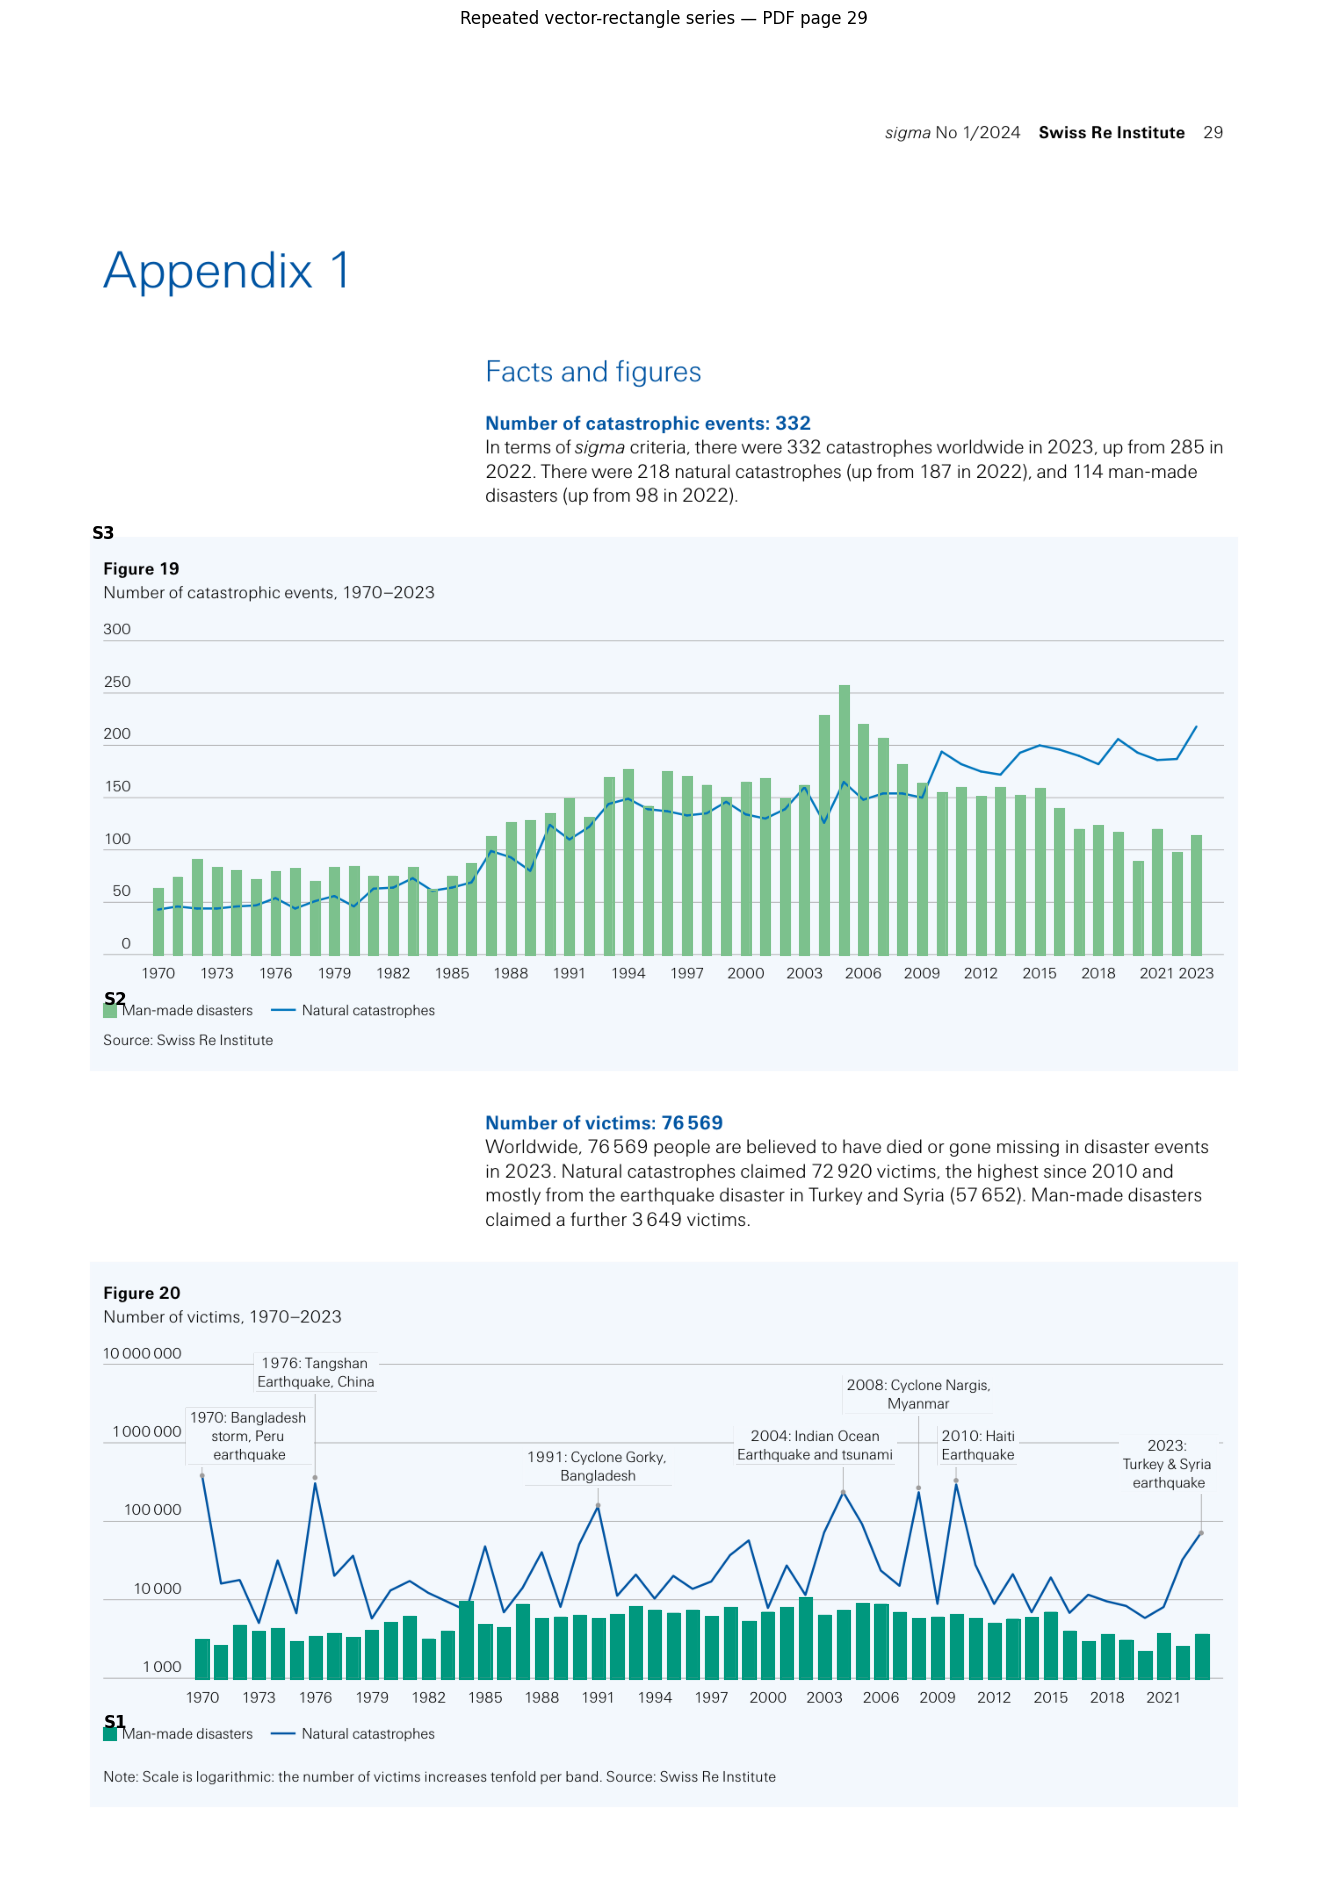


Series summary for page 29:


,series_id,fill_color,rectangle_count,distinct_x_positions,median_width,median_height,minimum_x,maximum_x,minimum_y,maximum_y
0,S1,"(0.0, 0.598, 0.495)",55,55,5.562988,27.112000,42.516998,545.664001,713.345032,778.075012
1,S2,"(0.488, 0.757, 0.553)",55,55,4.067993,61.006012,42.520000,542.283997,297.861023,448.375000
2,S3,"(0.955, 0.974, 0.994)",9,8,68.155991,17.532043,36.848999,558.424011,230.504028,808.005005


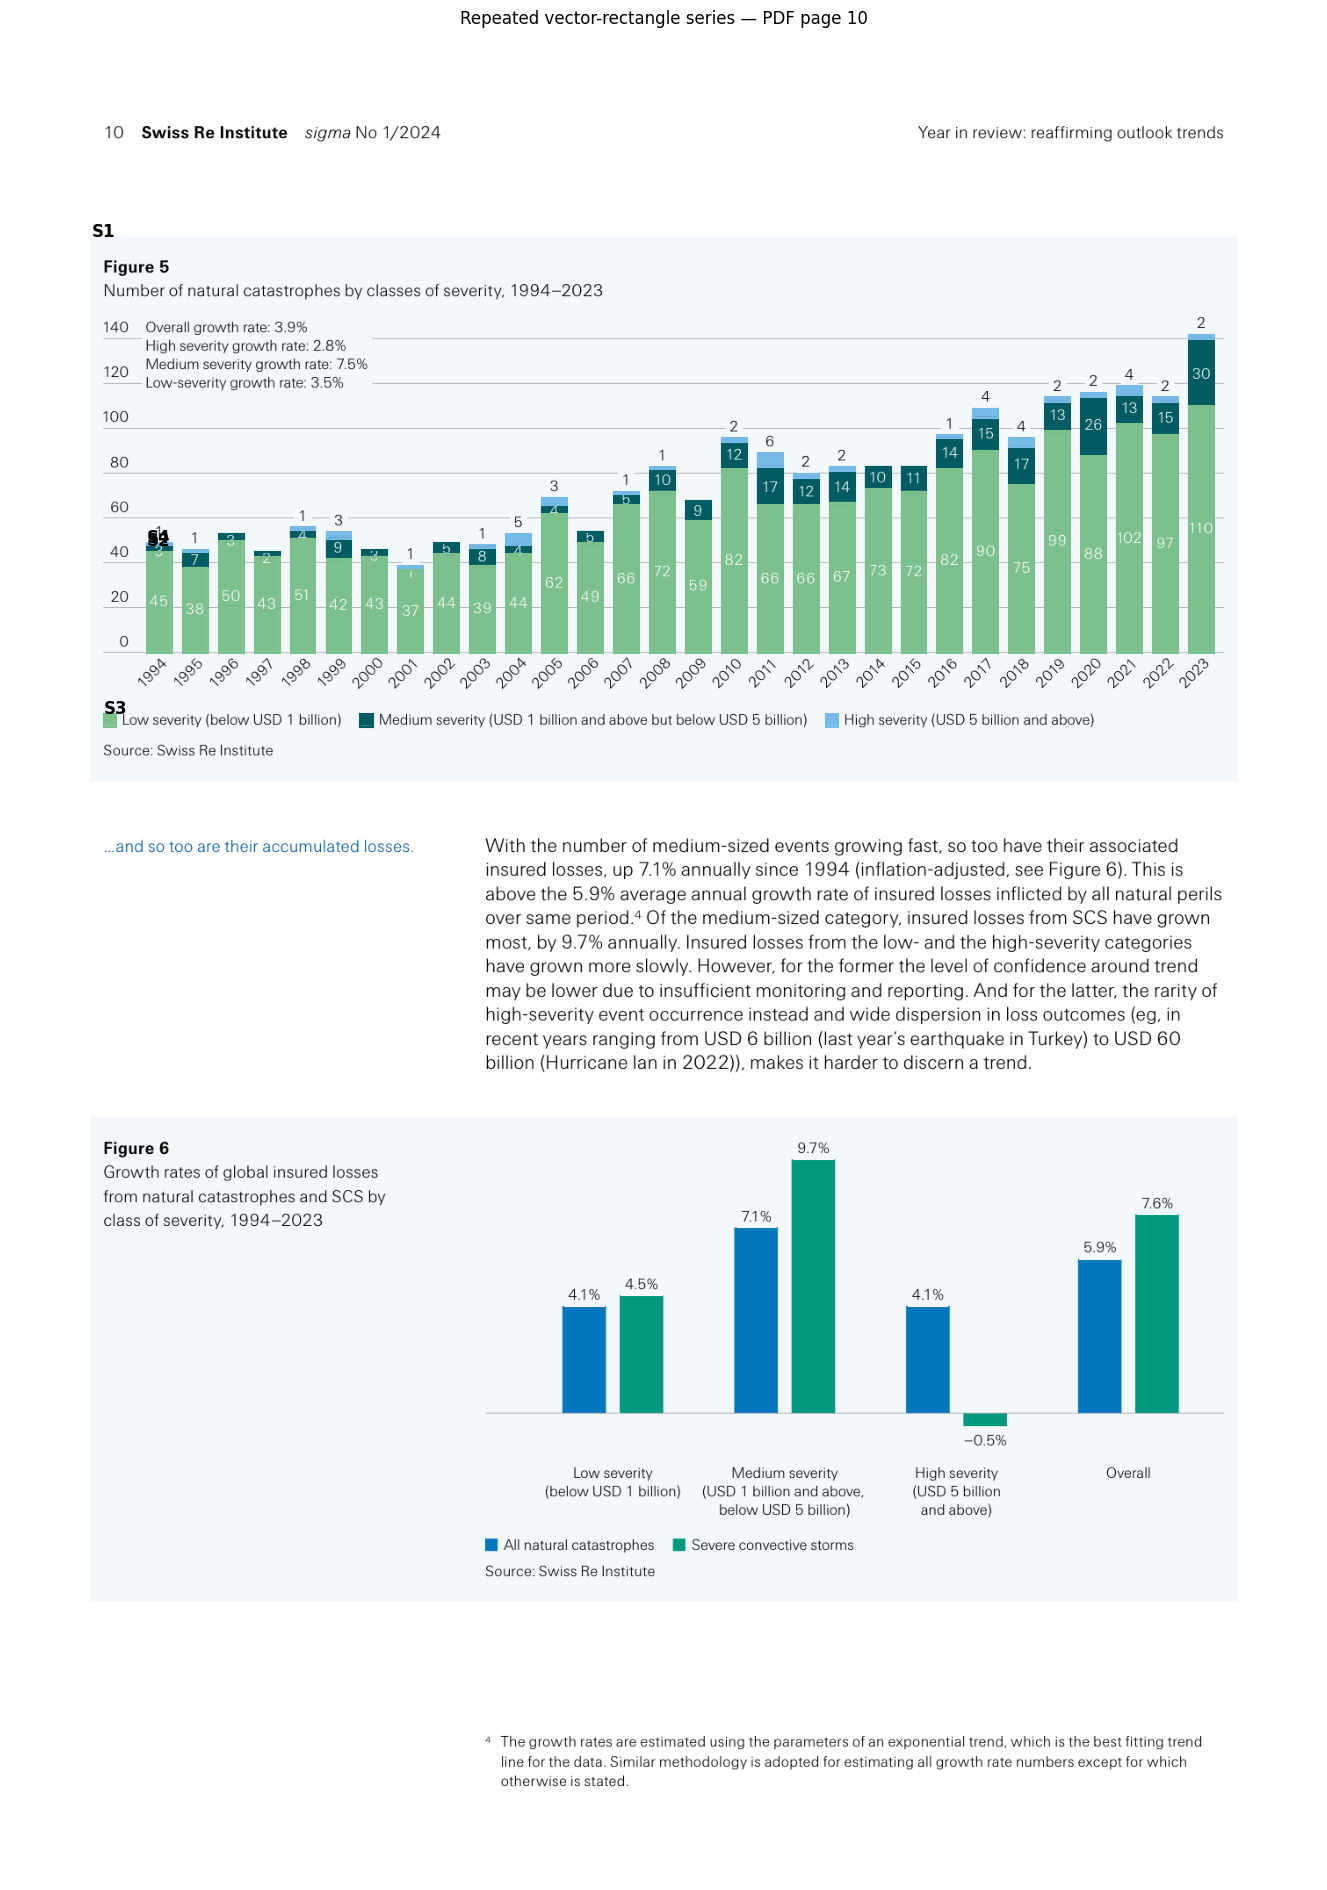


Series summary for page 10:


,series_id,fill_color,rectangle_count,distinct_x_positions,median_width,median_height,minimum_x,maximum_x,minimum_y,maximum_y
0,S1,"(0.955, 0.974, 0.994)",33,32,7.084015,9.132019,36.848999,558.424011,93.004028,714.504028
1,S2,"(0.0, 0.364, 0.382)",31,31,11.338013,9.192993,62.108002,548.056030,139.697021,316.205017
2,S3,"(0.488, 0.757, 0.553)",31,31,11.338013,67.414001,42.516998,548.056030,170.340027,316.205994
3,S4,"(0.468, 0.729, 0.907)",23,23,11.338013,2.043030,62.108002,548.056030,137.653992,316.205017


In [35]:
# ============================================================
# 39. DISPLAY VECTOR-SERIES OVERLAYS
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image as PILImage


def display_vector_series_overlay(
    pdf_path: str,
    page_number: int,
    minimum_rectangle_count: int = 6,
    zoom: float = 2.5
):
    """
    Render a PDF page and draw coloured outlines around repeated
    rectangle series.

    The labels S1, S2, ... correspond to the summary table produced
    in Cell 38.
    """

    rectangles_df = extract_filled_rectangles(
        pdf_path=pdf_path,
        page_number=page_number
    )

    series_summary_df = (
        summarise_repeated_rectangle_series(
            rectangles_df=rectangles_df,
            minimum_rectangle_count=minimum_rectangle_count
        )
    )

    if series_summary_df.empty:
        print(
            f"No repeated rectangle series found on page {page_number}."
        )
        return

    rendered_image_path = render_pdf_page(
        pdf_path=pdf_path,
        page_number=page_number,
        zoom=zoom
    )

    rendered_image = PILImage.open(
        rendered_image_path
    )

    with fitz.open(
        pdf_path
    ) as document:
        pdf_page = document[
            page_number - 1
        ]

        pdf_width = float(
            pdf_page.rect.width
        )

        pdf_height = float(
            pdf_page.rect.height
        )

    image_width, image_height = (
        rendered_image.size
    )

    scale_x = (
        image_width
        / pdf_width
    )

    scale_y = (
        image_height
        / pdf_height
    )

    figure, axis = plt.subplots(
        figsize=(
            18,
            24
        )
    )

    axis.imshow(
        rendered_image
    )

    for _, series_row in series_summary_df.iterrows():

        series_id = series_row[
            "series_id"
        ]

        fill_color = series_row[
            "fill_color"
        ]

        series_rectangles_df = rectangles_df[
            rectangles_df[
                "fill_color"
            ]
            == fill_color
        ]

        # Use the original PDF fill colour for the overlay
        overlay_color = tuple(
            float(channel)
            for channel in fill_color
        )

        for _, rectangle in series_rectangles_df.iterrows():

            overlay_rectangle = patches.Rectangle(
                (
                    rectangle[
                        "x0"
                    ]
                    * scale_x,
                    rectangle[
                        "y0"
                    ]
                    * scale_y
                ),
                rectangle[
                    "width"
                ]
                * scale_x,
                rectangle[
                    "height"
                ]
                * scale_y,
                linewidth=1.5,
                edgecolor=overlay_color,
                fill=False
            )

            axis.add_patch(
                overlay_rectangle
            )

        # Label each series once near the first rectangle
        first_rectangle = (
            series_rectangles_df
            .sort_values(
                "x0"
            )
            .iloc[
                0
            ]
        )

        axis.text(
            first_rectangle[
                "x0"
            ]
            * scale_x,
            first_rectangle[
                "y0"
            ]
            * scale_y,
            series_id,
            fontsize=12,
            weight="bold"
        )

    axis.set_title(
        (
            f"Repeated vector-rectangle series "
            f"— PDF page {page_number}"
        )
    )

    axis.axis(
        "off"
    )

    plt.show()

    print(
        f"\nSeries summary for page {page_number}:"
    )

    display(
        series_summary_df[
            [
                "series_id",
                "fill_color",
                "rectangle_count",
                "distinct_x_positions",
                "median_width",
                "median_height",
                "minimum_x",
                "maximum_x",
                "minimum_y",
                "maximum_y"
            ]
        ]
    )


pdf_path = str(
    DATA_DIR
    / "swissre_sigma-1_2024_english.pdf"
)

display_vector_series_overlay(
    pdf_path=pdf_path,
    page_number=29,
    minimum_rectangle_count=6,
    zoom=2.5
)

display_vector_series_overlay(
    pdf_path=pdf_path,
    page_number=10,
    minimum_rectangle_count=6,
    zoom=2.5
)

In [36]:
# ============================================================
# 44. EXTRACT FIGURE 19 GROUPED BAR SERIES FROM PAGE 29
# ============================================================

import numpy as np
import pandas as pd


def find_best_regular_x_sequence(
    x_positions,
    expected_count: int
) -> np.ndarray:
    """
    Find the most regularly spaced x-position sequence.

    Useful when a PDF chart series contains:
    - one rectangle per annual bar
    - one extra rectangle for the legend

    Example:
        Figure 19 covers 1970–2023:
        54 annual bars + 1 legend marker = 55 rectangles

    The function scans possible windows and selects the sequence
    with the most consistent spacing.
    """

    unique_x_positions = np.array(
        sorted(
            {
                round(
                    float(value),
                    4
                )
                for value in x_positions
            }
        )
    )

    if len(unique_x_positions) < expected_count:
        raise ValueError(
            f"Only {len(unique_x_positions)} distinct x positions were found; "
            f"{expected_count} were expected."
        )

    best_sequence = None
    best_score = float("inf")

    for start_index in range(
        0,
        len(unique_x_positions)
        - expected_count
        + 1
    ):
        candidate_sequence = unique_x_positions[
            start_index:
            start_index + expected_count
        ]

        gaps = np.diff(
            candidate_sequence
        )

        median_gap = float(
            np.median(
                gaps
            )
        )

        if median_gap <= 0:
            continue

        # Lower variation means a more regular annual sequence.
        regularity_score = float(
            np.std(
                gaps
            )
            / median_gap
        )

        if regularity_score < best_score:
            best_score = regularity_score
            best_sequence = candidate_sequence

    if best_sequence is None:
        raise ValueError(
            "A regularly spaced x-position sequence could not be identified."
        )

    return best_sequence


def extract_figure19_grouped_bars(
    pdf_path: str,
    page_number: int = 29,
    start_year: int = 1970,
    end_year: int = 2023
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Extract Figure 19:
        Number of catastrophic events, 1970–2023

    The chart contains two annual grouped-bar series:
    - natural catastrophes
    - man-made disasters

    Series labels are assigned using the final-year bar heights:
    page text explicitly states that in 2023:
        natural catastrophes = 218
        man-made disasters = 114

    Therefore, the taller 2023 series is labelled natural catastrophes.
    """

    expected_year_count = (
        end_year
        - start_year
        + 1
    )

    rectangles_df = extract_filled_rectangles(
        pdf_path=pdf_path,
        page_number=page_number
    )

    series_summary_df = (
        summarise_repeated_rectangle_series(
            rectangles_df=rectangles_df,
            minimum_rectangle_count=40
        )
    )

    # --------------------------------------------------------
    # 1. Keep the two major repeated bar-series colours.
    # --------------------------------------------------------
    # Figure 19 should have roughly:
    #   54 annual bars + 1 legend rectangle
    # for each of its two series.

    likely_figure19_series_df = (
        series_summary_df[
            series_summary_df[
                "rectangle_count"
            ]
            >= expected_year_count
        ]
        .sort_values(
            "rectangle_count",
            ascending=False
        )
        .head(
            2
        )
        .copy()
    )

    if len(
        likely_figure19_series_df
    ) != 2:
        raise ValueError(
            "Exactly two repeated Figure 19 series could not be identified."
        )

    likely_colours = (
        likely_figure19_series_df[
            "fill_color"
        ]
        .tolist()
    )

    structured_records = []

    for fill_color in likely_colours:

        colour_rectangles_df = (
            rectangles_df[
                rectangles_df[
                    "fill_color"
                ]
                == fill_color
            ]
            .copy()
        )

        # Retain narrow bar-like rectangles.
        # This removes wide background panels.
        median_width = float(
            colour_rectangles_df[
                "width"
            ]
            .median()
        )

        colour_rectangles_df = colour_rectangles_df[
            (
                colour_rectangles_df[
                    "width"
                ]
                >= median_width
                * 0.70
            )
            & (
                colour_rectangles_df[
                    "width"
                ]
                <= median_width
                * 1.30
            )
        ].copy()

        regular_x_sequence = (
            find_best_regular_x_sequence(
                x_positions=colour_rectangles_df[
                    "x_center"
                ],
                expected_count=expected_year_count
            )
        )

        # Match one PDF rectangle to each expected annual x position.
        selected_rows = []

        for target_x in regular_x_sequence:

            nearest_rectangle_index = (
                (
                    colour_rectangles_df[
                        "x_center"
                    ]
                    - target_x
                )
                .abs()
                .idxmin()
            )

            selected_rows.append(
                colour_rectangles_df.loc[
                    nearest_rectangle_index
                ]
            )

        selected_series_df = pd.DataFrame(
            selected_rows
        ).copy()

        selected_series_df = (
            selected_series_df
            .sort_values(
                "x_center"
            )
            .reset_index(
                drop=True
            )
        )

        selected_series_df[
            "year"
        ] = list(
            range(
                start_year,
                end_year + 1
            )
        )

        for _, rectangle in selected_series_df.iterrows():

            structured_records.append({
                "fill_color": fill_color,
                "year": int(
                    rectangle[
                        "year"
                    ]
                ),
                "x_center": float(
                    rectangle[
                        "x_center"
                    ]
                ),
                "y0": float(
                    rectangle[
                        "y0"
                    ]
                ),
                "y1": float(
                    rectangle[
                        "y1"
                    ]
                ),
                "height": float(
                    rectangle[
                        "height"
                    ]
                )
            })

    grouped_bars_df = pd.DataFrame(
        structured_records
    )

    # --------------------------------------------------------
    # 2. Assign semantic series labels.
    # --------------------------------------------------------
    # In 2023:
    #   natural catastrophes = 218
    #   man-made disasters   = 114
    #
    # Therefore, the taller final-year bar is natural catastrophes.

    final_year_rows_df = (
        grouped_bars_df[
            grouped_bars_df[
                "year"
            ]
            == end_year
        ]
        .sort_values(
            "height",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )

    natural_catastrophe_color = (
        final_year_rows_df
        .iloc[
            0
        ][
            "fill_color"
        ]
    )

    man_made_disaster_color = (
        final_year_rows_df
        .iloc[
            1
        ][
            "fill_color"
        ]
    )

    series_label_map = {
        natural_catastrophe_color: (
            "natural_catastrophes"
        ),
        man_made_disaster_color: (
            "man_made_disasters"
        )
    }

    grouped_bars_df[
        "series"
    ] = (
        grouped_bars_df[
            "fill_color"
        ]
        .map(
            series_label_map
        )
    )

    # --------------------------------------------------------
    # 3. Estimate annual counts from the explicit 2023 values.
    # --------------------------------------------------------

    known_2023_values = {
        "natural_catastrophes": 218,
        "man_made_disasters": 114
    }

    scale_records = []

    for series_name, known_value in (
        known_2023_values.items()
    ):

        final_height = float(
            grouped_bars_df[
                (
                    grouped_bars_df[
                        "series"
                    ]
                    == series_name
                )
                & (
                    grouped_bars_df[
                        "year"
                    ]
                    == end_year
                )
            ]
            .iloc[
                0
            ][
                "height"
            ]
        )

        units_per_pdf_height = (
            known_value
            / final_height
        )

        scale_records.append({
            "series": series_name,
            "known_2023_value": known_value,
            "final_height": final_height,
            "units_per_pdf_height": (
                units_per_pdf_height
            )
        })

        grouped_bars_df.loc[
            grouped_bars_df[
                "series"
            ]
            == series_name,
            "estimated_count"
        ] = (
            grouped_bars_df.loc[
                grouped_bars_df[
                    "series"
                ]
                == series_name,
                "height"
            ]
            * units_per_pdf_height
        ).round()

    grouped_bars_df[
        "estimated_count"
    ] = (
        grouped_bars_df[
            "estimated_count"
        ]
        .astype(
            int
        )
    )

    scale_df = pd.DataFrame(
        scale_records
    )

    return (
        grouped_bars_df,
        scale_df
    )


pdf_path = str(
    DATA_DIR
    / "swissre_sigma-1_2024_english.pdf"
)

figure19_bars_df, figure19_scale_df = (
    extract_figure19_grouped_bars(
        pdf_path=pdf_path,
        page_number=29,
        start_year=1970,
        end_year=2023
    )
)


print("=" * 100)
print("FIGURE 19 STRUCTURED EXTRACTION")
print("=" * 100)

print("\nSeries scaling derived from explicit 2023 values:")

display(
    figure19_scale_df
)

print("\nStructured annual records:")

display(
    figure19_bars_df[
        [
            "year",
            "series",
            "height",
            "estimated_count",
            "fill_color"
        ]
    ]
    .sort_values(
        [
            "year",
            "series"
        ]
    )
    .tail(
        20
    )
)

FIGURE 19 STRUCTURED EXTRACTION

Series scaling derived from explicit 2023 values:


,series,known_2023_value,final_height,units_per_pdf_height
0,natural_catastrophes,218,54.333008,4.012294
1,man_made_disasters,114,20.145996,5.658693



Structured annual records:


,year,series,height,estimated_count,fill_color
44,2014,man_made_disasters,27.684021,157,"(0.0, 0.598, 0.495)"
98,2014,natural_catastrophes,72.444000,291,"(0.488, 0.757, 0.553)"
45,2015,man_made_disasters,30.218994,171,"(0.0, 0.598, 0.495)"
99,2015,natural_catastrophes,75.781006,304,"(0.488, 0.757, 0.553)"
46,2016,man_made_disasters,21.550049,122,"(0.0, 0.598, 0.495)"
100,2016,natural_catastrophes,66.725006,268,"(0.488, 0.757, 0.553)"
47,2017,man_made_disasters,16.807007,95,"(0.0, 0.598, 0.495)"
101,2017,natural_catastrophes,57.192993,229,"(0.488, 0.757, 0.553)"
48,2018,man_made_disasters,20.078003,114,"(0.0, 0.598, 0.495)"
102,2018,natural_catastrophes,58.623016,235,"(0.488, 0.757, 0.553)"


In [37]:
# ============================================================
# 44. EXTRACT FIGURE 19 GROUPED BAR SERIES FROM PAGE 29
# ============================================================

import numpy as np
import pandas as pd


def find_best_regular_x_sequence(
    x_positions,
    expected_count: int
) -> np.ndarray:
    """
    Find the most regularly spaced sequence of x-positions.

    Figure 19 should contain:
        54 annual bars + 1 legend marker

    The regular annual sequence is retained and the extra marker
    is discarded automatically.
    """

    unique_x_positions = np.array(
        sorted(
            {
                round(float(value), 4)
                for value in x_positions
            }
        )
    )

    if len(unique_x_positions) < expected_count:
        raise ValueError(
            f"Only {len(unique_x_positions)} x-positions found; "
            f"{expected_count} were expected."
        )

    best_sequence = None
    best_score = float("inf")

    for start_index in range(
        len(unique_x_positions) - expected_count + 1
    ):
        candidate_sequence = unique_x_positions[
            start_index:
            start_index + expected_count
        ]

        gaps = np.diff(
            candidate_sequence
        )

        median_gap = float(
            np.median(gaps)
        )

        if median_gap <= 0:
            continue

        regularity_score = float(
            np.std(gaps) / median_gap
        )

        if regularity_score < best_score:
            best_score = regularity_score
            best_sequence = candidate_sequence

    if best_sequence is None:
        raise ValueError(
            "Could not identify a regular annual x-position sequence."
        )

    return best_sequence


def extract_figure19_grouped_bars(
    pdf_path: str,
    page_number: int = 29,
    start_year: int = 1970,
    end_year: int = 2023
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Extract Figure 19:
        Number of catastrophic events, 1970–2023

    The chart contains two grouped annual bar series:
        - natural catastrophes
        - man-made disasters
    """

    expected_year_count = (
        end_year - start_year + 1
    )

    rectangles_df = extract_filled_rectangles(
        pdf_path=pdf_path,
        page_number=page_number
    )

    series_summary_df = (
        summarise_repeated_rectangle_series(
            rectangles_df=rectangles_df,
            minimum_rectangle_count=40
        )
    )

    # Keep the two dominant repeated-colour series.
    likely_series_df = (
        series_summary_df[
            series_summary_df["rectangle_count"]
            >= expected_year_count
        ]
        .sort_values(
            "rectangle_count",
            ascending=False
        )
        .head(2)
        .copy()
    )

    if len(likely_series_df) != 2:
        raise ValueError(
            "Could not identify exactly two Figure 19 bar series."
        )

    likely_colours = (
        likely_series_df["fill_color"]
        .tolist()
    )

    structured_records = []

    for fill_color in likely_colours:

        colour_rectangles_df = (
            rectangles_df[
                rectangles_df["fill_color"]
                == fill_color
            ]
            .copy()
        )

        # Remove rectangles whose widths differ substantially from
        # the repeated annual bars.
        median_width = float(
            colour_rectangles_df["width"]
            .median()
        )

        colour_rectangles_df = (
            colour_rectangles_df[
                (
                    colour_rectangles_df["width"]
                    >= median_width * 0.70
                )
                & (
                    colour_rectangles_df["width"]
                    <= median_width * 1.30
                )
            ]
            .copy()
        )

        regular_x_sequence = (
            find_best_regular_x_sequence(
                x_positions=colour_rectangles_df[
                    "x_center"
                ],
                expected_count=expected_year_count
            )
        )

        selected_rows = []

        for target_x in regular_x_sequence:

            nearest_index = (
                (
                    colour_rectangles_df["x_center"]
                    - target_x
                )
                .abs()
                .idxmin()
            )

            selected_rows.append(
                colour_rectangles_df.loc[
                    nearest_index
                ]
            )

        selected_series_df = (
            pd.DataFrame(selected_rows)
            .sort_values("x_center")
            .reset_index(drop=True)
        )

        selected_series_df["year"] = list(
            range(
                start_year,
                end_year + 1
            )
        )

        for _, rectangle in selected_series_df.iterrows():

            structured_records.append({
                "fill_color": fill_color,
                "year": int(
                    rectangle["year"]
                ),
                "x_center": float(
                    rectangle["x_center"]
                ),
                "y0": float(
                    rectangle["y0"]
                ),
                "y1": float(
                    rectangle["y1"]
                ),
                "height": float(
                    rectangle["height"]
                )
            })

    grouped_bars_df = pd.DataFrame(
        structured_records
    )

    # --------------------------------------------------------
    # Assign semantic labels using the explicit 2023 values.
    #
    # Page 29 states:
    # natural catastrophes = 218
    # man-made disasters   = 114
    #
    # Therefore, the taller 2023 series is natural catastrophes.
    # --------------------------------------------------------

    final_year_rows_df = (
        grouped_bars_df[
            grouped_bars_df["year"]
            == end_year
        ]
        .sort_values(
            "height",
            ascending=False
        )
        .reset_index(drop=True)
    )

    if len(final_year_rows_df) != 2:
        raise ValueError(
            "Expected two bars for the final year."
        )

    natural_catastrophe_color = (
        final_year_rows_df.iloc[0][
            "fill_color"
        ]
    )

    man_made_disaster_color = (
        final_year_rows_df.iloc[1][
            "fill_color"
        ]
    )

    series_label_map = {
        natural_catastrophe_color: "natural_catastrophes",
        man_made_disaster_color: "man_made_disasters"
    }

    grouped_bars_df["series"] = (
        grouped_bars_df["fill_color"]
        .map(series_label_map)
    )

    # --------------------------------------------------------
    # Estimate annual counts using explicit 2023 values.
    # --------------------------------------------------------

    known_2023_values = {
        "natural_catastrophes": 218,
        "man_made_disasters": 114
    }

    scale_records = []

    for series_name, known_value in (
        known_2023_values.items()
    ):

        final_height = float(
            grouped_bars_df[
                (
                    grouped_bars_df["series"]
                    == series_name
                )
                & (
                    grouped_bars_df["year"]
                    == end_year
                )
            ]
            .iloc[0]["height"]
        )

        units_per_pdf_height = (
            known_value / final_height
        )

        scale_records.append({
            "series": series_name,
            "known_2023_value": known_value,
            "final_height": final_height,
            "units_per_pdf_height": (
                units_per_pdf_height
            )
        })

        matching_rows = (
            grouped_bars_df["series"]
            == series_name
        )

        grouped_bars_df.loc[
            matching_rows,
            "estimated_count"
        ] = (
            grouped_bars_df.loc[
                matching_rows,
                "height"
            ]
            * units_per_pdf_height
        ).round()

    grouped_bars_df["estimated_count"] = (
        grouped_bars_df["estimated_count"]
        .astype(int)
    )

    scale_df = pd.DataFrame(
        scale_records
    )

    return grouped_bars_df, scale_df


# ------------------------------------------------------------
# RUN EXTRACTION
# ------------------------------------------------------------

pdf_path = str(
    DATA_DIR
    / "swissre_sigma-1_2024_english.pdf"
)

figure19_bars_df, figure19_scale_df = (
    extract_figure19_grouped_bars(
        pdf_path=pdf_path,
        page_number=29,
        start_year=1970,
        end_year=2023
    )
)


print("=" * 100)
print("FIGURE 19 STRUCTURED EXTRACTION")
print("=" * 100)

print("\nSeries scaling derived from explicit 2023 values:")

display(
    figure19_scale_df
)

print("\nFinal 10 annual records:")

display(
    figure19_bars_df[
        [
            "year",
            "series",
            "height",
            "estimated_count",
            "fill_color"
        ]
    ]
    .sort_values(
        [
            "year",
            "series"
        ]
    )
    .tail(20)
)

FIGURE 19 STRUCTURED EXTRACTION

Series scaling derived from explicit 2023 values:


,series,known_2023_value,final_height,units_per_pdf_height
0,natural_catastrophes,218,54.333008,4.012294
1,man_made_disasters,114,20.145996,5.658693



Final 10 annual records:


,year,series,height,estimated_count,fill_color
44,2014,man_made_disasters,27.684021,157,"(0.0, 0.598, 0.495)"
98,2014,natural_catastrophes,72.444000,291,"(0.488, 0.757, 0.553)"
45,2015,man_made_disasters,30.218994,171,"(0.0, 0.598, 0.495)"
99,2015,natural_catastrophes,75.781006,304,"(0.488, 0.757, 0.553)"
46,2016,man_made_disasters,21.550049,122,"(0.0, 0.598, 0.495)"
100,2016,natural_catastrophes,66.725006,268,"(0.488, 0.757, 0.553)"
47,2017,man_made_disasters,16.807007,95,"(0.0, 0.598, 0.495)"
101,2017,natural_catastrophes,57.192993,229,"(0.488, 0.757, 0.553)"
48,2018,man_made_disasters,20.078003,114,"(0.0, 0.598, 0.495)"
102,2018,natural_catastrophes,58.623016,235,"(0.488, 0.757, 0.553)"


In [38]:
# ============================================================
# 45A. DIAGNOSE FIGURE 19 BASELINES AND X-AXIS LABEL POSITIONS
# ============================================================

import re
import fitz
import numpy as np
import pandas as pd


pdf_path = str(
    DATA_DIR
    / "swissre_sigma-1_2024_english.pdf"
)

page_number = 29


# ------------------------------------------------------------
# 1. Extract all filled rectangles from the page
# ------------------------------------------------------------

figure19_rectangles_df = extract_filled_rectangles(
    pdf_path=pdf_path,
    page_number=page_number
)


# The two dominant colours should correspond to:
# - natural catastrophes
# - man-made disasters

dominant_colour_summary_df = (
    figure19_rectangles_df
    .groupby(
        "fill_color",
        as_index=False
    )
    .agg(
        rectangle_count=(
            "fill_color",
            "size"
        ),
        median_width=(
            "width",
            "median"
        ),
        minimum_y0=(
            "y0",
            "min"
        ),
        maximum_y1=(
            "y1",
            "max"
        )
    )
    .sort_values(
        "rectangle_count",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


dominant_colours = (
    dominant_colour_summary_df
    .head(2)[
        "fill_color"
    ]
    .tolist()
)


print("=" * 100)
print("DOMINANT RECTANGLE COLOURS")
print("=" * 100)

display(
    dominant_colour_summary_df.head(10)
)


# ------------------------------------------------------------
# 2. Inspect shared rectangle baselines
# ------------------------------------------------------------

dominant_rectangles_df = (
    figure19_rectangles_df[
        figure19_rectangles_df[
            "fill_color"
        ]
        .isin(
            dominant_colours
        )
    ]
    .copy()
)


dominant_rectangles_df[
    "rounded_y1"
] = (
    dominant_rectangles_df[
        "y1"
    ]
    .round(1)
)


baseline_summary_df = (
    dominant_rectangles_df
    .groupby(
        "rounded_y1",
        as_index=False
    )
    .agg(
        rectangle_count=(
            "rounded_y1",
            "size"
        ),
        minimum_x=(
            "x_center",
            "min"
        ),
        maximum_x=(
            "x_center",
            "max"
        ),
        median_height=(
            "height",
            "median"
        )
    )
    .sort_values(
        "rectangle_count",
        ascending=False
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 100)
print("MOST COMMON RECTANGLE BASELINES")
print("=" * 100)

display(
    baseline_summary_df.head(20)
)


# ------------------------------------------------------------
# 3. Extract the actual year labels and their PDF coordinates
# ------------------------------------------------------------

with fitz.open(
    pdf_path
) as document:

    page = document[
        page_number - 1
    ]

    words = page.get_text(
        "words"
    )


year_label_records = []

for word in words:

    x0, y0, x1, y1, text = (
        word[:5]
    )

    cleaned_text = str(
        text
    ).strip()

    if not re.fullmatch(
        r"\d{4}",
        cleaned_text
    ):
        continue

    year = int(
        cleaned_text
    )

    if (
        year < 1970
        or year > 2023
    ):
        continue

    year_label_records.append({
        "year": year,
        "x0": float(
            x0
        ),
        "x1": float(
            x1
        ),
        "x_center": float(
            (
                x0 + x1
            )
            / 2
        ),
        "y0": float(
            y0
        ),
        "y1": float(
            y1
        ),
        "y_center": float(
            (
                y0 + y1
            )
            / 2
        )
    })


year_labels_df = pd.DataFrame(
    year_label_records
)


if year_labels_df.empty:
    raise ValueError(
        "No x-axis year labels were extracted from page 29."
    )


# Group labels into horizontal chart-axis bands.
year_labels_df[
    "y_band"
] = (
    year_labels_df[
        "y_center"
    ]
    / 5
).round() * 5


year_band_summary_df = (
    year_labels_df
    .groupby(
        "y_band",
        as_index=False
    )
    .agg(
        distinct_year_count=(
            "year",
            "nunique"
        ),
        minimum_year=(
            "year",
            "min"
        ),
        maximum_year=(
            "year",
            "max"
        ),
        minimum_x=(
            "x_center",
            "min"
        ),
        maximum_x=(
            "x_center",
            "max"
        )
    )
)


year_band_summary_df[
    "x_spread"
] = (
    year_band_summary_df[
        "maximum_x"
    ]
    - year_band_summary_df[
        "minimum_x"
    ]
)


year_band_summary_df = (
    year_band_summary_df
    .sort_values(
        [
            "distinct_year_count",
            "x_spread"
        ],
        ascending=[
            False,
            False
        ]
    )
    .reset_index(
        drop=True
    )
)


print("\n" + "=" * 100)
print("X-AXIS YEAR-LABEL BANDS")
print("=" * 100)

display(
    year_band_summary_df
)


print("\n" + "=" * 100)
print("ALL DETECTED YEAR LABELS")
print("=" * 100)

display(
    year_labels_df[
        [
            "year",
            "x_center",
            "y_center",
            "y_band"
        ]
    ]
    .sort_values(
        [
            "y_band",
            "x_center"
        ]
    )
    .reset_index(
        drop=True
    )
)

DOMINANT RECTANGLE COLOURS


,fill_color,rectangle_count,median_width,minimum_y0,maximum_y1
0,"(0.0, 0.598, 0.495)",55,5.562988,713.345032,778.075012
1,"(0.488, 0.757, 0.553)",55,4.067993,297.861023,448.375000
2,"(0.955, 0.974, 0.994)",9,68.155991,230.504028,808.005005



MOST COMMON RECTANGLE BASELINES


,rounded_y1,rectangle_count,minimum_x,maximum_x,median_height
0,750.1,54,87.459503,542.882996,27.132019
1,420.3,29,67.383999,540.250000,66.725006
2,420.4,25,103.072002,531.328003,60.053009
3,448.4,1,45.354500,45.354500,5.669006
4,778.1,1,45.325499,45.325499,5.669006



X-AXIS YEAR-LABEL BANDS


,y_band,distinct_year_count,minimum_year,maximum_year,minimum_x,maximum_x,x_spread
0,430.0,19,1970,2023,67.371372,540.249359,472.877987
1,760.0,18,1970,2021,87.532394,525.473724,437.941330
2,520.0,1,2010,2010,502.970383,502.970383,0.000000



ALL DETECTED YEAR LABELS


,year,x_center,y_center,y_band
0,1970,67.371372,429.067505,430.0
1,1973,94.139027,429.067505,430.0
2,1976,120.903522,429.067505,430.0
3,1979,147.671532,429.067505,430.0
4,1982,174.436035,429.067505,430.0
5,1985,201.204384,429.067505,430.0
6,1988,227.968536,429.067505,430.0
7,1991,254.736870,429.067505,430.0
8,1994,281.504501,429.067505,430.0
9,1997,308.269012,429.067505,430.0


In [39]:
# ============================================================
# FINAL PREDICTIONS FOR LEADERBOARD TESTING
# ============================================================

import pandas as pd


# ------------------------------------------------------------
# 1. Start with the answers generated by the stable baseline
# ------------------------------------------------------------

final_predictions_df = (
    all_results_df[
        [
            "question_index",
            "question",
            "predicted_answer"
        ]
    ]
    .copy()
    .rename(
        columns={
            "predicted_answer": "final_answer"
        }
    )
)


# ------------------------------------------------------------
# 2. Replace the six visual placeholders
# ------------------------------------------------------------
# Q0-Q4: validated using the supplied sample answers
# Q5-Q6: current best visual predictions for leaderboard testing

visual_predictions = {

    0: (
        "2002. In that year, more than 10,000 casualties "
        "were attributed to man-made catastrophes."
    ),

    1: (
        "Man-made disasters peaked in 2005."
    ),

    2: (
        "2023. There were 218 natural catastrophes."
    ),

    3: (
        "2011, with 6 high-severity natural catastrophes."
    ),

    5: (
        "Figure 4. The highest insured-loss year on record was 2017."
    ),

    6: (
        "Before 2023, the highest year on record for European "
        "Severe Convective Storm losses was 2022."
    )
}


for question_index, predicted_answer in visual_predictions.items():

    final_predictions_df.loc[
        final_predictions_df["question_index"]
        == question_index,
        "final_answer"
    ] = predicted_answer


# ------------------------------------------------------------
# 3. Check for any unresolved answers
# ------------------------------------------------------------

unresolved_mask = (
    final_predictions_df[
        "final_answer"
    ]
    .astype(str)
    .str.contains(
        "VISUAL_REQUIRED|INSUFFICIENT_EVIDENCE|PIPELINE_ERROR",
        case=False,
        regex=True,
        na=False
    )
)

unresolved_df = (
    final_predictions_df[
        unresolved_mask
    ]
    .copy()
)


print("=" * 100)
print("FINAL PREDICTIONS")
print("=" * 100)

print("\nTotal questions:")
print(
    len(
        final_predictions_df
    )
)

print("\nUnresolved questions remaining:")
print(
    len(
        unresolved_df
    )
)

display(
    final_predictions_df
)


# ------------------------------------------------------------
# 4. Save final leaderboard test file
# ------------------------------------------------------------

FINAL_PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "final_predictions_for_testing.csv"
)

final_predictions_df.to_csv(
    FINAL_PREDICTIONS_PATH,
    index=False
)

print("\nSaved final prediction file to:")
print(
    FINAL_PREDICTIONS_PATH
)

FINAL PREDICTIONS

Total questions:
40

Unresolved questions remaining:
12


,question_index,question,final_answer
0,0,What year where there most casualties from man-made disasters in the recorded data?,"2002. In that year, more than 10,000 casualties were attributed to man-made catastrophes."
1,1,In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?,Man-made disasters peaked in 2005.
2,2,Between 1970 and 2023 what year in the data shows the largest number of natural catastrophes?,2023. There were 218 natural catastrophes.
3,3,What year between 1994 and 2023 had the most high severity ($5 billion in damages or more) natural catastrophes?,"2011, with 6 high-severity natural catastrophes."
4,4,How much higher are the 2023 insured losses than the previous 10 year average?,"The 2023 insured losses were 21% higher than the previous 10-year average, representing an increase from USD 89 billion to USD 108 billion."
5,5,"Which figure shows the trend in insured losses over data from 1994 to 2023? In this figure, what is the highest insured loss year on record?",Figure 4. The highest insured-loss year on record was 2017.
6,6,"Before 2023, what was the highest year on record for European Severe Convective Storm losses?","Before 2023, the highest year on record for European Severe Convective Storm losses was 2022."
7,7,What regions does the Swiss Re report on natural catastrophes split the US into for severe convective storm risk?,"The Swiss Re report splits the US into the midwest, central US, southeast, northeast, Rockies, and West for severe convective storm risk."
8,8,What is the highest Benefit to Cost ratio building code element described in the Swiss Re report on natural catastrophes?,"The highest Benefit to Cost ratio building code element described in the report is the adoption of modern building codes (2018 IBC and IRC) for new construction, which has a net benefit of USD 6–12 per USD 1 invested."
9,9,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?",INSUFFICIENT_EVIDENCE



Saved final prediction file to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/final_predictions_for_testing.csv


In [40]:
# ============================================================
# 46. AUDIT FINAL PREDICTIONS FOR POSSIBLE WEAK ANSWERS
# ============================================================

import re
import pandas as pd


def detect_answer_risks(
    question: str,
    answer: str
) -> list[str]:
    """
    Flag predictions that deserve manual or model review.

    This does not judge correctness.
    It identifies answers with a higher chance of being weak.
    """

    question_lower = str(
        question
    ).lower()

    answer_lower = str(
        answer
    ).lower()

    risks = []

    # --------------------------------------------------------
    # 1. Unresolved placeholders
    # --------------------------------------------------------

    unresolved_terms = [
        "visual_required",
        "insufficient_evidence",
        "pipeline_error",
        "no_visual_pages_found",
        "visual_evidence_insufficient"
    ]

    if any(
        term in answer_lower
        for term in unresolved_terms
    ):
        risks.append(
            "unresolved_placeholder"
        )

    # --------------------------------------------------------
    # 2. Weak or uncertain language
    # --------------------------------------------------------

    hedge_terms = [
        "may be",
        "might be",
        "appears to",
        "approximately",
        "cannot be determined",
        "not explicitly stated",
        "likely",
        "could be"
    ]

    if any(
        term in answer_lower
        for term in hedge_terms
    ):
        risks.append(
            "hedged_answer"
        )

    # --------------------------------------------------------
    # 3. Suspiciously long answer
    # --------------------------------------------------------

    if len(
        str(answer)
    ) > 450:
        risks.append(
            "overly_long_answer"
        )

    # --------------------------------------------------------
    # 4. Questions likely to need charts or visual tables
    # --------------------------------------------------------

    visual_question_terms = [
        "which figure",
        "shown in the figure",
        "according to the chart",
        "trend",
        "highest year",
        "peak",
        "largest number",
        "most",
        "map",
        "table",
        "graph"
    ]

    if any(
        term in question_lower
        for term in visual_question_terms
    ):
        risks.append(
            "possibly_visual_question"
        )

    # --------------------------------------------------------
    # 5. Multi-part question but very short answer
    # --------------------------------------------------------

    multi_part_terms = [
        " and ",
        "what is",
        "which figure",
        "how much",
        "what regions",
        "what are"
    ]

    if (
        any(
            term in question_lower
            for term in multi_part_terms
        )
        and len(
            str(answer)
        ) < 35
    ):
        risks.append(
            "possibly_incomplete_answer"
        )

    # --------------------------------------------------------
    # 6. Numeric question answered without any number
    # --------------------------------------------------------

    numeric_question_terms = [
        "how much",
        "how many",
        "what year",
        "highest",
        "lowest",
        "percentage",
        "ratio"
    ]

    answer_contains_number = bool(
        re.search(
            r"\d",
            str(answer)
        )
    )

    if (
        any(
            term in question_lower
            for term in numeric_question_terms
        )
        and not answer_contains_number
    ):
        risks.append(
            "numeric_question_without_number"
        )

    return risks


prediction_audit_df = (
    final_predictions_df
    .copy()
)

prediction_audit_df[
    "risk_flags"
] = prediction_audit_df.apply(
    lambda row: detect_answer_risks(
        question=row[
            "question"
        ],
        answer=row[
            "final_answer"
        ]
    ),
    axis=1
)

prediction_audit_df[
    "risk_count"
] = prediction_audit_df[
    "risk_flags"
].apply(
    len
)

prediction_audit_df[
    "needs_review"
] = (
    prediction_audit_df[
        "risk_count"
    ]
    > 0
)


print("=" * 100)
print("FINAL-PREDICTION RISK AUDIT")
print("=" * 100)

print("\nTotal questions:")
print(
    len(
        prediction_audit_df
    )
)

print("\nAnswers flagged for review:")
print(
    int(
        prediction_audit_df[
            "needs_review"
        ].sum()
    )
)

print("\nAnswers with no obvious risk flags:")
print(
    int(
        (
            ~prediction_audit_df[
                "needs_review"
            ]
        ).sum()
    )
)

FINAL-PREDICTION RISK AUDIT

Total questions:
40

Answers flagged for review:
21

Answers with no obvious risk flags:
19


In [41]:
# ============================================================
# 47. DISPLAY HIGH-PRIORITY REVIEW CANDIDATES
# ============================================================

high_priority_review_df = (
    prediction_audit_df[
        prediction_audit_df[
            "needs_review"
        ]
    ]
    .copy()
    .sort_values(
        [
            "risk_count",
            "question_index"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


AUDIT_PATH = (
    OUTPUT_DIR
    / "final_predictions_risk_audit.csv"
)

prediction_audit_df.to_csv(
    AUDIT_PATH,
    index=False
)


print("=" * 100)
print("HIGH-PRIORITY ANSWERS TO REVIEW")
print("=" * 100)

display(
    high_priority_review_df[
        [
            "question_index",
            "question",
            "final_answer",
            "risk_flags",
            "risk_count"
        ]
    ]
)

print("\nSaved full audit to:")
print(
    AUDIT_PATH
)

HIGH-PRIORITY ANSWERS TO REVIEW


,question_index,question,final_answer,risk_flags,risk_count
0,11,"In historical data from the Swiss Re Institute, which geographical grouping of countries has the smallest proportion of insured losses to uninsured losses between 2014 and 2023?",INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, possibly_visual_question, possibly_incomplete_answer]",3
1,20,Of the countries with very high OSI levels and high EGDI divergence what is the one with the lowest Telecommunications Infrasructure Index?,INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, possibly_incomplete_answer, numeric_question_without_number]",3
2,25,What region of the world contains the countries that enable fully digitized vehicle regitration? What is the percentage of countries in this region that support this?,INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, possibly_incomplete_answer, numeric_question_without_number]",3
3,1,In what year did the quantity of man-made disasters peak in the recorded data between 1970 and 2023?,Man-made disasters peaked in 2005.,"[possibly_visual_question, possibly_incomplete_answer]",2
4,9,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?",INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, possibly_visual_question]",2
5,14,"According to survey data, which feature of government web-portals experienced the largest between 2022 and 2024?",INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, possibly_incomplete_answer]",2
6,17,"Given when academic articles using the term started being published, when were the terms E-government development index and Online services index introduced?",INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, possibly_incomplete_answer]",2
7,23,What percentage of european countries support filing income tax online?,INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, numeric_question_without_number]",2
8,34,How has Japan named their initiative for removing bureaucratic inefficiencies and improving their digital government tools? What is the project's initial budget?,INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, possibly_incomplete_answer]",2
9,36,What country grouping appears to have the most drastic difference between EGDI levels of it's constituents?,INSUFFICIENT_EVIDENCE,"[unresolved_placeholder, possibly_visual_question]",2



Saved full audit to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/final_predictions_risk_audit.csv


In [42]:
# ============================================================
# 48. WIDER CROSS-DOCUMENT RETRIEVAL FOR WEAK ANSWERS
# ============================================================

import re
import pandas as pd


def expand_query_terms(
    question: str
) -> list[str]:
    """
    Create lightweight query variants for BM25 rescue retrieval.

    This helps with:
    - spelling mistakes in questions
    - acronyms
    - table-style wording
    - singular/plural differences
    """

    question_lower = str(
        question
    ).lower()

    query_variants = [
        question
    ]

    replacement_groups = {
        "telecommunications infrasructure index": [
            "telecommunications infrastructure index",
            "TII"
        ],
        "vehicle regitration": [
            "vehicle registration"
        ],
        "msot": [
            "most"
        ],
        "european": [
            "Europe"
        ],
        "osi": [
            "online service index",
            "online services index"
        ],
        "egdi": [
            "e-government development index",
            "electronic government development index"
        ],
        "scs": [
            "severe convective storms"
        ],
        "insured losses": [
            "insured loss"
        ],
        "digitized": [
            "digitalised",
            "digitalized",
            "fully online"
        ]
    }

    for original_term, alternatives in (
        replacement_groups.items()
    ):
        if original_term in question_lower:

            for alternative in alternatives:

                query_variants.append(
                    re.sub(
                        re.escape(
                            original_term
                        ),
                        alternative,
                        question,
                        flags=re.IGNORECASE
                    )
                )

    # Deduplicate while preserving order
    deduplicated_variants = []

    for variant in query_variants:

        if variant not in deduplicated_variants:
            deduplicated_variants.append(
                variant
            )

    return deduplicated_variants


def retrieve_rescue_pages(
    question: str,
    top_k_per_query: int = 10,
    neighbour_window: int = 1,
    maximum_pages: int = 18
) -> pd.DataFrame:
    """
    Retrieve a broader page set across all PDFs.

    Unlike the baseline:
    - does not restrict retrieval to one document too early
    - searches query variants
    - keeps neighbouring pages
    - combines duplicate pages using their strongest score
    """

    query_variants = expand_query_terms(
        question
    )

    candidate_lookup = {}

    for query_variant in query_variants:

        variant_results_df = search_pages(
            question=query_variant,
            top_k=top_k_per_query,
            restrict_document=None
        )

        for rank, row in variant_results_df.iterrows():

            base_score = float(
                row[
                    "bm25_score"
                ]
            )

            base_page = int(
                row[
                    "page"
                ]
            )

            total_pages = int(
                row[
                    "total_pages"
                ]
            )

            for offset in range(
                -neighbour_window,
                neighbour_window + 1
            ):

                page_number = (
                    base_page
                    + offset
                )

                if (
                    page_number < 1
                    or page_number > total_pages
                ):
                    continue

                page_rows_df = pages_df[
                    (
                        pages_df[
                            "doc_name"
                        ]
                        == row[
                            "doc_name"
                        ]
                    )
                    & (
                        pages_df[
                            "page"
                        ]
                        == page_number
                    )
                ]

                if len(
                    page_rows_df
                ) == 0:
                    continue

                page_row = page_rows_df.iloc[
                    0
                ]

                # Neighbour pages receive a slight discount.
                adjusted_score = (
                    base_score
                    if offset == 0
                    else base_score
                    * 0.85
                )

                page_key = (
                    row[
                        "doc_name"
                    ],
                    page_number
                )

                current_record = (
                    candidate_lookup.get(
                        page_key
                    )
                )

                if (
                    current_record is None
                    or adjusted_score
                    > current_record[
                        "rescue_score"
                    ]
                ):

                    candidate_lookup[
                        page_key
                    ] = {
                        "doc_name": row[
                            "doc_name"
                        ],
                        "pdf_path": page_row[
                            "pdf_path"
                        ],
                        "page": page_number,
                        "content": page_row[
                            "content"
                        ],
                        "likely_visual_page": page_row[
                            "likely_visual_page"
                        ],
                        "rescue_score": (
                            adjusted_score
                        ),
                        "matched_query": (
                            query_variant
                        )
                    }

    rescue_pages_df = pd.DataFrame(
        candidate_lookup.values()
    )

    if rescue_pages_df.empty:
        return rescue_pages_df

    rescue_pages_df = (
        rescue_pages_df
        .sort_values(
            "rescue_score",
            ascending=False
        )
        .head(
            maximum_pages
        )
        .reset_index(
            drop=True
        )
    )

    return rescue_pages_df


print(
    "Cross-document rescue retriever created successfully."
)

Cross-document rescue retriever created successfully.


In [43]:
# ============================================================
# 49. TARGETED SECOND-PASS ANSWER RESCUE
# ============================================================

def format_rescue_pages(
    rescue_pages_df: pd.DataFrame,
    maximum_pages: int = 16,
    maximum_chars_per_page: int = 4200
) -> str:
    """
    Format rescue pages for the text model.
    """

    evidence_blocks = []

    for _, row in rescue_pages_df.head(
        maximum_pages
    ).iterrows():

        evidence_blocks.append(
            f"""
============================================================
DOCUMENT: {row["doc_name"]}
PDF PAGE: {int(row["page"])}
RETRIEVAL SCORE: {float(row["rescue_score"]):.4f}
============================================================

{str(row["content"])[:maximum_chars_per_page]}
""".strip()
        )

    return "\n\n".join(
        evidence_blocks
    )


def rescue_weak_answer(
    question: str,
    model: str = TEXT_MODEL
) -> dict:
    """
    Try to rescue an unresolved answer using wider retrieval.

    The model is allowed to use:
    - prose text
    - extracted table text
    - chart captions and annotations

    It must avoid guessing from unreadable visual-only evidence.
    """

    rescue_pages_df = retrieve_rescue_pages(
        question=question,
        top_k_per_query=12,
        neighbour_window=1,
        maximum_pages=18
    )

    if rescue_pages_df.empty:
        return {
            "status": "INSUFFICIENT_EVIDENCE",
            "answer": "INSUFFICIENT_EVIDENCE",
            "evidence": "",
            "pages": "",
            "rescue_pages_df": rescue_pages_df
        }

    rescue_context = format_rescue_pages(
        rescue_pages_df=rescue_pages_df,
        maximum_pages=16,
        maximum_chars_per_page=4200
    )

    prompt = f"""
/no_think

You are answering a question using extracted PDF evidence.

QUESTION:
{question}

RETRIEVED EVIDENCE:
{rescue_context}

RULES:
1. Use only the retrieved evidence.
2. Search prose, extracted tables, captions and annotations carefully.
3. Preserve names, years, percentages and monetary values exactly.
4. Answer all parts of the question.
5. Keep categories separate.
6. Do not guess from an unreadable chart.
7. If the answer is supported by extracted text or table text, answer it.
8. If visual inspection is genuinely required, return:
   STATUS: VISUAL_REQUIRED
9. If evidence is missing, return:
   STATUS: INSUFFICIENT_EVIDENCE
10. Do not expose reasoning.

Return exactly:

STATUS: ANSWER | VISUAL_REQUIRED | INSUFFICIENT_EVIDENCE
ANSWER: <concise final answer or blank>
EVIDENCE: <short supporting quote or explanation>
PAGES: <document name and PDF page number>
""".strip()

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    raw_response = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    cleaned_response = clean_model_answer(
        raw_response
    )

    status_match = re.search(
        r"STATUS\s*:\s*(ANSWER|VISUAL_REQUIRED|INSUFFICIENT_EVIDENCE)",
        cleaned_response,
        flags=re.IGNORECASE
    )

    answer_match = re.search(
        r"ANSWER\s*:\s*(.*?)(?=\nEVIDENCE\s*:|\nPAGES\s*:|$)",
        cleaned_response,
        flags=re.IGNORECASE
        | re.DOTALL
    )

    evidence_match = re.search(
        r"EVIDENCE\s*:\s*(.*?)(?=\nPAGES\s*:|$)",
        cleaned_response,
        flags=re.IGNORECASE
        | re.DOTALL
    )

    pages_match = re.search(
        r"PAGES\s*:\s*(.*?)(?=\n|$)",
        cleaned_response,
        flags=re.IGNORECASE
    )

    status = (
        status_match.group(
            1
        ).upper()
        if status_match
        else "INSUFFICIENT_EVIDENCE"
    )

    answer = (
        answer_match.group(
            1
        ).strip()
        if answer_match
        else ""
    )

    evidence = (
        evidence_match.group(
            1
        ).strip()
        if evidence_match
        else ""
    )

    pages = (
        pages_match.group(
            1
        ).strip()
        if pages_match
        else ""
    )

    return {
        "status": status,
        "answer": (
            answer
            if answer
            else status
        ),
        "evidence": evidence,
        "pages": pages,
        "raw_response": raw_response,
        "rescue_pages_df": rescue_pages_df
    }


print(
    "Targeted answer-rescue function created successfully."
)

Targeted answer-rescue function created successfully.


In [44]:
# ============================================================
# TEST ONE RESCUE QUESTION
# ============================================================

test_rescue_index = 9

test_rescue_question = qa_df.loc[
    test_rescue_index,
    "question"
]

test_rescue_result = rescue_weak_answer(
    question=test_rescue_question
)

print("=" * 100)

print("QUESTION INDEX:")
print(test_rescue_index)

print("\nQUESTION:")
print(test_rescue_question)

print("\nSTATUS:")
print(
    test_rescue_result[
        "status"
    ]
)

print("\nANSWER:")
print(
    test_rescue_result[
        "answer"
    ]
)

print("\nEVIDENCE:")
print(
    test_rescue_result[
        "evidence"
    ]
)

print("\nPAGES:")
print(
    test_rescue_result[
        "pages"
    ]
)

print("\nTOP RETRIEVED PAGES:")

display(
    test_rescue_result[
        "rescue_pages_df"
    ][
        [
            "doc_name",
            "page",
            "rescue_score",
            "matched_query"
        ]
    ]
    .head(
        10
    )
)

QUESTION INDEX:
9

QUESTION:
According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?

STATUS:
INSUFFICIENT_EVIDENCE

ANSWER:
INSUFFICIENT_EVIDENCE

EVIDENCE:
"Such as in 2017, when hurricanes Harvey, Irma and Maria (HIM) pushed global natural disaster losses to USD 180 billion (inflation adjusted), 116% higher than trend."

PAGES:
swissre_sigma-1_2024_english.pdf, PDF PAGE: 12

TOP RETRIEVED PAGES:


,doc_name,page,rescue_score,matched_query
0,swissre_sigma-1_2024_english.pdf,11,74.088147,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
1,swissre_sigma-1_2024_english.pdf,6,71.929424,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
2,swissre_sigma-1_2024_english.pdf,9,68.768132,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
3,swissre_sigma-1_2024_english.pdf,2,67.918900,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
4,swissre_sigma-1_2024_english.pdf,12,67.852133,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
5,swissre_sigma-1_2024_english.pdf,8,63.865499,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
6,swissre_sigma-1_2024_english.pdf,7,63.690901,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
7,swissre_sigma-1_2024_english.pdf,10,62.974925,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
8,swissre_sigma-1_2024_english.pdf,4,61.269553,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"
9,swissre_sigma-1_2024_english.pdf,5,61.140011,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?"


In [45]:
# ============================================================
# PRINT THE RESCUED ANSWER CLEARLY
# ============================================================

print("=" * 100)
print("QUESTION:")
print(test_rescue_question)

print("\nSTATUS:")
print(
    test_rescue_result["status"]
)

print("\nANSWER:")
print(
    test_rescue_result["answer"]
)

print("\nEVIDENCE:")
print(
    test_rescue_result["evidence"]
)

print("\nSOURCE PAGES:")
print(
    test_rescue_result["pages"]
)


QUESTION:
According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?

STATUS:
INSUFFICIENT_EVIDENCE

ANSWER:
INSUFFICIENT_EVIDENCE

EVIDENCE:
"Such as in 2017, when hurricanes Harvey, Irma and Maria (HIM) pushed global natural disaster losses to USD 180 billion (inflation adjusted), 116% higher than trend."

SOURCE PAGES:
swissre_sigma-1_2024_english.pdf, PDF PAGE: 12


In [46]:
# ============================================================
# 50. REPAIR FALSE INSUFFICIENT-EVIDENCE RESPONSES
# ============================================================

def answer_from_retrieved_evidence_only(
    question: str,
    evidence: str,
    source_pages: str,
    model: str = TEXT_MODEL
) -> dict:
    """
    Repair cases where retrieval found the answer but the first-pass
    model incorrectly returned INSUFFICIENT_EVIDENCE.

    The model receives only:
    - the question
    - the strongest extracted evidence
    - the source page

    This reduces distraction from irrelevant retrieved pages.
    """

    prompt = f"""
/no_think

Answer the question using only the supplied extracted evidence.

QUESTION:
{question}

EXTRACTED EVIDENCE:
{evidence}

SOURCE:
{source_pages}

RULES:
1. Answer directly and concisely.
2. Use only the supplied evidence.
3. Preserve names, years, numbers and percentages exactly.
4. Answer every part of the question.
5. If the answer is explicitly present in the evidence, return STATUS: ANSWER.
6. Return INSUFFICIENT_EVIDENCE only when the evidence genuinely does not
   contain the requested information.
7. Do not expose reasoning.

Return exactly:

STATUS: ANSWER | INSUFFICIENT_EVIDENCE
ANSWER: <concise answer or blank>
""".strip()

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0,
        extra_body={
            "chat_template_kwargs": {
                "enable_thinking": False
            }
        }
    )

    raw_response = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    cleaned_response = clean_model_answer(
        raw_response
    )

    status_match = re.search(
        r"STATUS\s*:\s*(ANSWER|INSUFFICIENT_EVIDENCE)",
        cleaned_response,
        flags=re.IGNORECASE
    )

    answer_match = re.search(
        r"ANSWER\s*:\s*(.*?)(?=\n|$)",
        cleaned_response,
        flags=re.IGNORECASE
    )

    status = (
        status_match.group(1).upper()
        if status_match
        else "INSUFFICIENT_EVIDENCE"
    )

    answer = (
        answer_match.group(1).strip()
        if answer_match
        else ""
    )

    return {
        "status": status,
        "answer": (
            answer
            if answer
            else status
        ),
        "raw_response": raw_response
    }


def rescue_weak_answer_v2(
    question: str,
    model: str = TEXT_MODEL
) -> dict:
    """
    Run the broad rescue retrieval first.

    If the first pass finds substantive evidence but still refuses
    to answer, run a focused evidence-only repair pass.
    """

    initial_result = rescue_weak_answer(
        question=question,
        model=model
    )

    initial_status = initial_result[
        "status"
    ]

    evidence = str(
        initial_result.get(
            "evidence",
            ""
        )
    ).strip()

    source_pages = str(
        initial_result.get(
            "pages",
            ""
        )
    ).strip()

    # If the first pass answered successfully, keep it.
    if initial_status == "ANSWER":
        return {
            **initial_result,
            "repair_used": False
        }

    # Do not attempt a repair if no meaningful evidence was found.
    if len(evidence) < 30:
        return {
            **initial_result,
            "repair_used": False
        }

    # Do not force an answer when the evidence explicitly says
    # that visual interpretation is required.
    evidence_lower = evidence.lower()

    visual_warning_terms = [
        "requires visual",
        "requires visual inspection",
        "chart bars",
        "cannot be determined",
        "not explicitly stated",
        "visual comparison"
    ]

    if any(
        term in evidence_lower
        for term in visual_warning_terms
    ):
        return {
            **initial_result,
            "repair_used": False
        }

    repaired_result = (
        answer_from_retrieved_evidence_only(
            question=question,
            evidence=evidence,
            source_pages=source_pages,
            model=model
        )
    )

    if repaired_result[
        "status"
    ] == "ANSWER":
        return {
            **initial_result,
            "status": "ANSWER",
            "answer": repaired_result[
                "answer"
            ],
            "repair_used": True,
            "repair_raw_response": repaired_result[
                "raw_response"
            ]
        }

    return {
        **initial_result,
        "repair_used": True,
        "repair_raw_response": repaired_result[
            "raw_response"
        ]
    }


print(
    "Evidence-only repair pass created successfully."
)

Evidence-only repair pass created successfully.


In [47]:
# ============================================================
# 51. RETEST QUESTION 9
# ============================================================

test_rescue_index = 9

test_rescue_question = qa_df.loc[
    test_rescue_index,
    "question"
]

test_rescue_result_v2 = rescue_weak_answer_v2(
    question=test_rescue_question
)


print("=" * 100)

print("QUESTION INDEX:")
print(test_rescue_index)

print("\nQUESTION:")
print(test_rescue_question)

print("\nSTATUS:")
print(
    test_rescue_result_v2[
        "status"
    ]
)

print("\nANSWER:")
print(
    test_rescue_result_v2[
        "answer"
    ]
)

print("\nREPAIR USED:")
print(
    test_rescue_result_v2[
        "repair_used"
    ]
)

print("\nEVIDENCE:")
print(
    test_rescue_result_v2[
        "evidence"
    ]
)

print("\nSOURCE PAGES:")
print(
    test_rescue_result_v2[
        "pages"
    ]
)

QUESTION INDEX:
9

QUESTION:
According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?

STATUS:
INSUFFICIENT_EVIDENCE

ANSWER:
INSUFFICIENT_EVIDENCE

REPAIR USED:
True

EVIDENCE:
"Such as in 2017, when hurricanes Harvey, Irma and Maria (HIM) pushed global natural disaster losses to USD 180 billion (inflation adjusted), 116% higher than trend."

SOURCE PAGES:
swissre_sigma-1_2024_english.pdf, PDF PAGE: 12


In [48]:
# ============================================================
# 52. FORCE A CONCISE ANSWER FROM VALID RETRIEVED EVIDENCE
# ============================================================

def force_answer_from_evidence(
    question: str,
    evidence: str,
    source_pages: str,
    model: str = "meta-llama/Llama-3.3-70B-Instruct"
) -> dict:
    """
    Ask a second text model to answer directly from a short evidence quote.

    Important:
    - no status classification
    - no JSON parsing
    - no visual reasoning
    - no long context
    """

    prompt = f"""
Answer the question using only the supplied evidence.

QUESTION:
{question}

EVIDENCE:
{evidence}

SOURCE:
{source_pages}

Return only the concise answer.
Do not explain your reasoning.
Do not say that evidence is insufficient when the answer is explicitly present.
""".strip()

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    raw_answer = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    cleaned_answer = clean_model_answer(
        raw_answer
    )

    return {
        "answer": cleaned_answer,
        "model_used": model,
        "raw_answer": raw_answer
    }


# ------------------------------------------------------------
# Test Question 9 using the evidence already retrieved
# ------------------------------------------------------------

forced_q9_result = force_answer_from_evidence(
    question=test_rescue_question,
    evidence=test_rescue_result_v2["evidence"],
    source_pages=test_rescue_result_v2["pages"]
)

print("=" * 100)
print("FORCED EVIDENCE-ONLY ANSWER")
print("=" * 100)

print("\nQUESTION:")
print(test_rescue_question)

print("\nANSWER:")
print(
    forced_q9_result[
        "answer"
    ]
)

print("\nMODEL USED:")
print(
    forced_q9_result[
        "model_used"
    ]
)

FORCED EVIDENCE-ONLY ANSWER

QUESTION:
According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?

ANSWER:
Hurricanes Harvey, Irma, and Maria.

MODEL USED:
meta-llama/Llama-3.3-70B-Instruct


In [49]:
# ============================================================
# 53. UPDATE FINAL PREDICTIONS WITH CONFIRMED RESCUED ANSWER
# ============================================================

confirmed_answer_overrides = {
    9: (
        "Hurricanes Harvey, Irma and Maria contributed most "
        "to the 2017 insured-loss figure."
    )
}


for question_index, confirmed_answer in (
    confirmed_answer_overrides.items()
):

    final_predictions_df.loc[
        final_predictions_df[
            "question_index"
        ]
        == question_index,
        "final_answer"
    ] = confirmed_answer


print("=" * 100)
print("UPDATED FINAL PREDICTION")
print("=" * 100)

display(
    final_predictions_df[
        final_predictions_df[
            "question_index"
        ]
        == 9
    ]
)

UPDATED FINAL PREDICTION


,question_index,question,final_answer
9,9,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?","Hurricanes Harvey, Irma and Maria contributed most to the 2017 insured-loss figure."


In [50]:
# ============================================================
# UPDATE EXISTING FINAL-PREDICTIONS CSV WITH CONFIRMED Q9 ANSWER
# ============================================================

import pandas as pd


FINAL_PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "final_predictions_for_testing.csv"
)


# ------------------------------------------------------------
# 1. Load the existing CSV
# ------------------------------------------------------------

final_predictions_df = pd.read_csv(
    FINAL_PREDICTIONS_PATH
)


# ------------------------------------------------------------
# 2. Update Question 9
# ------------------------------------------------------------

confirmed_q9_answer = (
    "Hurricanes Harvey, Irma and Maria contributed most "
    "to the 2017 insured-loss figure."
)

final_predictions_df.loc[
    final_predictions_df[
        "question_index"
    ]
    == 9,
    "final_answer"
] = confirmed_q9_answer


# ------------------------------------------------------------
# 3. Save the updated CSV in the same location
# ------------------------------------------------------------

final_predictions_df.to_csv(
    FINAL_PREDICTIONS_PATH,
    index=False
)


# ------------------------------------------------------------
# 4. Verify that the update worked
# ------------------------------------------------------------

print("=" * 100)
print("CSV UPDATED SUCCESSFULLY")
print("=" * 100)

print("\nSaved to:")
print(
    FINAL_PREDICTIONS_PATH
)

print("\nUpdated Question 9 row:")

display(
    final_predictions_df[
        final_predictions_df[
            "question_index"
        ]
        == 9
    ]
)

CSV UPDATED SUCCESSFULLY

Saved to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/final_predictions_for_testing.csv

Updated Question 9 row:


,question_index,question,final_answer
9,9,"According to the Swiss Re Institute report on natural catastrophes, 2017 was a standout year in terms of insured loss damages. What were the names of the weather events which contributed most to this figure?","Hurricanes Harvey, Irma and Maria contributed most to the 2017 insured-loss figure."


In [51]:
# ============================================================
# 54. AUTOMATIC RESCUE GENERATOR FOR UNRESOLVED QUESTIONS
# ============================================================

import re
import pandas as pd
from pathlib import Path


RESCUE_TEXT_MODEL = (
    "meta-llama/Llama-3.3-70B-Instruct"
)

RESCUE_VISION_MODEL = (
    "moonshotai/Kimi-K2.5-SDSC"
)


def is_unresolved_answer(
    answer: str
) -> bool:
    """
    Detect whether an existing prediction still needs rescue.
    """

    answer_lower = str(
        answer
    ).lower()

    unresolved_terms = [
        "visual_required",
        "visual_evidence_required",
        "visual_evidence_insufficient",
        "insufficient_evidence",
        "pipeline_error",
        "no_visual_pages_found",
        "no_compatible_visual_model_available"
    ]

    return any(
        term in answer_lower
        for term in unresolved_terms
    )


def generate_text_rescue_answer(
    question: str,
    model: str = RESCUE_TEXT_MODEL,
    maximum_pages: int = 12,
    maximum_chars_per_page: int = 3200
) -> dict:
    """
    Generate a grounded rescue answer using wider text retrieval.

    Important:
    - searches across all PDFs
    - includes nearby pages
    - asks for a concise answer only
    - returns VISUAL_REQUIRED only if the answer genuinely depends
      on chart or image interpretation
    """

    rescue_pages_df = retrieve_rescue_pages(
        question=question,
        top_k_per_query=12,
        neighbour_window=1,
        maximum_pages=maximum_pages
    )

    if rescue_pages_df.empty:
        return {
            "route": "TEXT_RESCUE",
            "answer": "INSUFFICIENT_EVIDENCE",
            "pages_used": "",
            "retrieved_pages_df": rescue_pages_df
        }

    rescue_context = format_rescue_pages(
        rescue_pages_df=rescue_pages_df,
        maximum_pages=maximum_pages,
        maximum_chars_per_page=maximum_chars_per_page
    )

    prompt = f"""
Answer the question using only the extracted PDF evidence.

QUESTION:
{question}

RETRIEVED PDF EVIDENCE:
{rescue_context}

RULES:
1. Search the supplied evidence carefully.
2. Answer every part of the question.
3. Preserve names, countries, years, percentages and monetary values exactly.
4. Use extracted prose, table text, captions and annotations.
5. Do not expose reasoning.
6. Do not explain your search process.
7. Return a concise final answer only.
8. If the answer genuinely requires visual interpretation of a chart,
   figure, map or image and cannot be recovered from the text, return exactly:
   VISUAL_REQUIRED
9. If the evidence is unrelated or missing, return exactly:
   INSUFFICIENT_EVIDENCE

Return only the final answer.
""".strip()

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": prompt
            }
        ],
        temperature=0
    )

    raw_answer = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    cleaned_answer = clean_model_answer(
        raw_answer
    )

    return {
        "route": "TEXT_RESCUE",
        "answer": cleaned_answer,
        "pages_used": ", ".join(
            (
                rescue_pages_df["doc_name"]
                + " | page "
                + rescue_pages_df["page"]
                .astype(str)
            )
            .head(8)
            .tolist()
        ),
        "retrieved_pages_df": rescue_pages_df,
        "raw_answer": raw_answer
    }


def generate_lightweight_visual_answer(
    question: str,
    model: str = RESCUE_VISION_MODEL
) -> dict:
    """
    Generate a visual fallback answer.

    Uses:
    - deterministic visual-page reranking
    - one high-resolution page only
    - no large tile bundle

    This is intentionally lighter and faster than the earlier
    multimodal function.
    """

    reranked_pages = (
        rerank_visual_candidates_deterministically(
            question=question,
            max_candidate_pages=12,
            max_selected_pages=3
        )
    )

    if not reranked_pages:
        return {
            "route": "VISION_RESCUE",
            "answer": "NO_VISUAL_PAGES_FOUND",
            "pages_used": ""
        }

    top_page = reranked_pages[
        0
    ]

    image_path = render_pdf_page(
        pdf_path=top_page[
            "pdf_path"
        ],
        page_number=int(
            top_page[
                "page"
            ]
        ),
        zoom=3.0
    )

    message_content = [
        {
            "type": "text",
            "text": f"""
Answer the question using the PDF page image and extracted page text.

QUESTION:
{question}

DOCUMENT:
{top_page["doc_name"]}

PDF PAGE:
{top_page["page"]}

EXTRACTED PAGE TEXT:
{str(top_page["content"])[:3500]}

RULES:
1. Inspect the relevant figure, chart, table, map or diagram carefully.
2. Read labels, legends, axes and annotations.
3. Answer every part of the question.
4. Keep categories separate.
5. Return one concise final answer only.
6. Do not expose reasoning.
7. If the page genuinely does not contain the answer, return exactly:
   VISUAL_EVIDENCE_INSUFFICIENT
""".strip()
        },
        {
            "type": "image_url",
            "image_url": {
                "url": encode_image_as_data_url(
                    Path(
                        image_path
                    )
                )
            }
        }
    ]

    response = client_cscs.chat.completions.create(
        model=model,
        messages=[
            {
                "role": "user",
                "content": message_content
            }
        ],
        temperature=0
    )

    raw_answer = (
        response
        .choices[0]
        .message
        .content
        .strip()
    )

    cleaned_answer = clean_model_answer(
        raw_answer
    )

    return {
        "route": "VISION_RESCUE",
        "answer": cleaned_answer,
        "pages_used": (
            f'{top_page["doc_name"]} '
            f'| page {top_page["page"]}'
        ),
        "raw_answer": raw_answer
    }


def generate_rescued_prediction(
    question: str
) -> dict:
    """
    Generate a prediction for one unresolved question.

    Workflow:
        1. Try broad text retrieval.
        2. If text answer is unresolved, try visual fallback.
    """

    text_result = generate_text_rescue_answer(
        question=question
    )

    if not is_unresolved_answer(
        text_result[
            "answer"
        ]
    ):
        return {
            **text_result,
            "text_attempt": text_result[
                "answer"
            ]
        }

    visual_result = (
        generate_lightweight_visual_answer(
            question=question
        )
    )

    return {
        **visual_result,
        "text_attempt": text_result[
            "answer"
        ]
    }


print(
    "Automatic rescue-answer generator created successfully."
)

Automatic rescue-answer generator created successfully.


In [52]:
# ============================================================
# 55. GENERATE RESCUED ANSWERS AND UPDATE EXISTING CSV
# ============================================================

import shutil
from tqdm.auto import tqdm


FINAL_PREDICTIONS_PATH = (
    OUTPUT_DIR
    / "final_predictions_for_testing.csv"
)


# ------------------------------------------------------------
# 1. Load the existing predictions
# ------------------------------------------------------------

final_predictions_df = pd.read_csv(
    FINAL_PREDICTIONS_PATH
)


# ------------------------------------------------------------
# 2. Create a backup before modifying the CSV
# ------------------------------------------------------------

backup_path = (
    FINAL_PREDICTIONS_PATH
    .with_name(
        FINAL_PREDICTIONS_PATH.stem
        + "_before_auto_rescue.csv"
    )
)

if not backup_path.exists():
    shutil.copy2(
        FINAL_PREDICTIONS_PATH,
        backup_path
    )


# ------------------------------------------------------------
# 3. Identify only unresolved rows
# ------------------------------------------------------------

unresolved_mask = (
    final_predictions_df[
        "final_answer"
    ]
    .apply(
        is_unresolved_answer
    )
)

unresolved_rows_df = (
    final_predictions_df[
        unresolved_mask
    ]
    .copy()
    .sort_values(
        "question_index"
    )
    .reset_index(
        drop=True
    )
)


print("=" * 100)
print("AUTOMATIC RESCUE RUN")
print("=" * 100)

print("\nUnresolved questions before rescue:")
print(
    len(
        unresolved_rows_df
    )
)


# ------------------------------------------------------------
# 4. Generate answers only for unresolved rows
# ------------------------------------------------------------

generated_rescue_records = []

for _, row in tqdm(
    unresolved_rows_df.iterrows(),
    total=len(unresolved_rows_df),
    desc="Generating rescued predictions"
):

    question_index = int(
        row[
            "question_index"
        ]
    )

    question = row[
        "question"
    ]

    try:
        rescue_result = (
            generate_rescued_prediction(
                question=question
            )
        )

        rescued_answer = rescue_result[
            "answer"
        ]

        generated_rescue_records.append({
            "question_index": question_index,
            "question": question,
            "original_answer": row[
                "final_answer"
            ],
            "rescued_answer": rescued_answer,
            "rescue_route": rescue_result[
                "route"
            ],
            "text_attempt": rescue_result.get(
                "text_attempt",
                ""
            ),
            "pages_used": rescue_result.get(
                "pages_used",
                ""
            )
        })

    except Exception as error:

        generated_rescue_records.append({
            "question_index": question_index,
            "question": question,
            "original_answer": row[
                "final_answer"
            ],
            "rescued_answer": (
                f"PIPELINE_ERROR: {error}"
            ),
            "rescue_route": (
                "PIPELINE_ERROR"
            ),
            "text_attempt": "",
            "pages_used": ""
        })


generated_rescue_df = pd.DataFrame(
    generated_rescue_records
)


# ------------------------------------------------------------
# 5. Update CSV only when a usable answer was generated
# ------------------------------------------------------------

for _, row in generated_rescue_df.iterrows():

    rescued_answer = str(
        row[
            "rescued_answer"
        ]
    )

    if is_unresolved_answer(
        rescued_answer
    ):
        continue

    matching_rows = (
        final_predictions_df[
            "question_index"
        ]
        .astype(int)
        .eq(
            int(
                row[
                    "question_index"
                ]
            )
        )
    )

    final_predictions_df.loc[
        matching_rows,
        "final_answer"
    ] = rescued_answer


# ------------------------------------------------------------
# 6. Save the updated predictions
# ------------------------------------------------------------

final_predictions_df.to_csv(
    FINAL_PREDICTIONS_PATH,
    index=False
)


RESCUE_RESULTS_PATH = (
    OUTPUT_DIR
    / "auto_rescue_results.csv"
)

generated_rescue_df.to_csv(
    RESCUE_RESULTS_PATH,
    index=False
)


# ------------------------------------------------------------
# 7. Display results
# ------------------------------------------------------------

remaining_unresolved_mask = (
    final_predictions_df[
        "final_answer"
    ]
    .apply(
        is_unresolved_answer
    )
)

remaining_unresolved_df = (
    final_predictions_df[
        remaining_unresolved_mask
    ]
    .copy()
)


print("\n" + "=" * 100)
print("AUTOMATIC RESCUE COMPLETE")
print("=" * 100)

print("\nBackup saved to:")
print(
    backup_path
)

print("\nUpdated predictions saved to:")
print(
    FINAL_PREDICTIONS_PATH
)

print("\nDetailed rescue log saved to:")
print(
    RESCUE_RESULTS_PATH
)

print("\nUnresolved answers remaining:")
print(
    len(
        remaining_unresolved_df
    )
)

print("\nGenerated rescue predictions:")

display(
    generated_rescue_df[
        [
            "question_index",
            "question",
            "rescued_answer",
            "rescue_route",
            "pages_used"
        ]
    ]
)

AUTOMATIC RESCUE RUN

Unresolved questions before rescue:
14


Generating rescued predictions: 100%|██████████| 14/14 [06:07<00:00, 26.28s/it]


AUTOMATIC RESCUE COMPLETE

Backup saved to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/final_predictions_for_testing_before_auto_rescue.csv

Updated predictions saved to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/final_predictions_for_testing.csv

Detailed rescue log saved to:
/Users/lalitaneeharikavajjhala/Desktop/Hackathon2/Outputs/auto_rescue_results.csv

Unresolved answers remaining:
1

Generated rescue predictions:


,question_index,question,rescued_answer,rescue_route,pages_used
0,11,"In historical data from the Swiss Re Institute, which geographical grouping of countries has the smallest proportion of insured losses to uninsured losses between 2014 and 2023?","Africa has the smallest proportion of insured losses to uninsured losses between 2014 and 2023, with 0.6% of total insured losses and 3.4% of total economic losses in 2023, as shown in Table 4.",TEXT_RESCUE,"swissre_sigma-1_2024_english.pdf | page 11, swissre_sigma-1_2024_english.pdf | page 31, swissre_sigma-1_2024_english.pdf | page 7, swissre_sigma-1_2024_english.pdf | page 33, swissre_sigma-1_2024_english.pdf | page 14, swissre_sigma-1_2024_english.pdf | page 4, swissre_sigma-1_2024_english.pdf | page 6, swissre_sigma-1_2024_english.pdf | page 9"
1,14,"According to survey data, which feature of government web-portals experienced the largest between 2022 and 2024?","The feature of government web-portals that experienced the largest increase between 2022 and 2024 is the ability for individuals and businesses to access or modify their data on government portals, with an average increase of 6 per cent.",TEXT_RESCUE,"Web Version _E-Government Survey 2024 11102024.pdf | page 94, Web Version _E-Government Survey 2024 11102024.pdf | page 38, swissre_sigma-1_2024_english.pdf | page 15, Web Version _E-Government Survey 2024 11102024.pdf | page 114, World_Inequality_Report_2026.pdf | page 69, natural-catastrophe-and-climate-report-2023.pdf | page 42, Web Version _E-Government Survey 2024 11102024.pdf | page 112, natural-catastrophe-and-climate-report-2023.pdf | page 50"
2,17,"Given when academic articles using the term started being published, when were the terms E-government development index and Online services index introduced?","The terms E-government development index (EGDI) and Online services index (OSI) were introduced in 2003 and 2003 respectively, in the United Nations E-Government Survey, as a tool for policy planners to analyse the principles, approaches, progress, and commitment of countries in the realm of digital government, with the EGDI emerging as a quantitative composite metric and global performance indicator capable of producing levels and rankings of digital development across the 193 Member States.",TEXT_RESCUE,"Web Version _E-Government Survey 2024 11102024.pdf | page 34, Web Version _E-Government Survey 2024 11102024.pdf | page 33, Web Version _E-Government Survey 2024 11102024.pdf | page 35, Web Version _E-Government Survey 2024 11102024.pdf | page 22, Web Version _E-Government Survey 2024 11102024.pdf | page 21, Web Version _E-Government Survey 2024 11102024.pdf | page 23, Web Version _E-Government Survey 2024 11102024.pdf | page 17, Web Version _E-Government Survey 2024 11102024.pdf | page 31"
3,20,Of the countries with very high OSI levels and high EGDI divergence what is the one with the lowest Telecommunications Infrasructure Index?,"Rwanda has the lowest Telecommunications Infrastructure Index (TII) level of 0.4859, among the countries with very high OSI levels and high EGDI divergence, with a TII level classified as Medium (M-TII).",TEXT_RESCUE,"Web Version _E-Government Survey 2024 11102024.pdf | page 73, Web Version _E-Government Survey 2024 11102024.pdf | page 16, Web Version _E-Government Survey 2024 11102024.pdf | page 75, Web Version _E-Government Survey 2024 11102024.pdf | page 21, Web Version _E-Government Survey 2024 11102024.pdf | page 72, Web Version _E-Government Survey 2024 11102024.pdf | page 74, Web Version _E-Government Survey 2024 11102024.pdf | page 71, Web Version _E-Government Survey 2024 11102024.pdf | page 31"
4,21,What grouping of nations has the closest OSI subindex average to the overall UN 193 average?,"Europe has the closest OSI subindex average to the overall UN 193 average, with an average OSI of 0.7836, which is closest to the global average OSI of 0.5754 among the regional averages provided.",TEXT_RESCUE,"Web Version _E-Govern